In [1]:
import xarray as xr
import pathlib
import os

# Disable HDF5 file locking to avoid file-access collisions when accessing files concurrently 
# across processes, threads, or distributed file systems (e.g., NFS, Lustre).
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import h5py
from spacepy import pybats
from spacepy.pybats import bats
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial import cKDTree
from scipy.interpolate import griddata, RegularGridInterpolator
from PIL import Image 
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
from matplotlib.animation import FuncAnimation, PillowWriter
from datetime import datetime
import pandas as pd
import re
import spacepy.omni as om
import ipywidgets as widgets
from IPython.display import display
from collections import deque, defaultdict
from matplotlib.colors import LogNorm
import time
import joblib
from matplotlib.colors import Normalize
from datetime import datetime, timezone
from scipy.ndimage import map_coordinates
from scipy.ndimage import gaussian_filter
from numba import njit, float64, float32, set_num_threads, prange
import geopack.geopack as gp
import cdflib
import h5netcdf
from xarray.backends import H5netcdfBackendEntrypoint
import pickle
import matplotlib.ticker as ticker
import netCDF4
import math
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.special import gamma, gammaln


# Manually tell the library which version to use since it can't find the files itself
def manual_init_igrf(version='14'):
    gp.version = version
    gp.base_name = f'igrf{version}coeffs.txt'
    # Point it directly to the absolute path we just verified
    local_dir = '/Users/nfurioso/mhd_env/lib/python3.11/site-packages/geopack'
    gp.coef_file = os.path.join(local_dir, gp.base_name)
    print(f"Successfully manually linked IGRF coefficients from: {gp.coef_file}")

# Override the broken function with our working one
gp.init_igrf = manual_init_igrf
manual_init_igrf()

# NOW run your imports
from geopack import geopack, t96

path2 = pathlib.Path("/Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/MHDoutputValues/BATSRUS/3d__var_1_e20251231-000000-000.out")
BATSRUS = pybats.IdlFile(path2)
pprint(BATSRUS.attrs)
# List variables
print(list(BATSRUS.keys()))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/spacepy/empiricals.py:26: UserWarning: Qin-Denton/OMNI2 data not found in current format. This module has limited functionality. Run spacepy.toolbox.update(QDomni=True) to download data.
  import spacepy.omni as om


Load IGRF coefficients ...
Failed to get the list of IGRF coefficients.
Successfully manually linked IGRF coefficients from: /Users/nfurioso/mhd_env/lib/python3.11/site-packages/geopack/igrf14coeffs.txt
{'NX': np.float64(8.0),
 'NY': np.float64(8.0),
 'NZ': np.float64(8.0),
 'R': np.float64(2.5),
 'c': np.float64(2997.89990234375),
 'file': PosixPath('/Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/MHDoutputValues/BATSRUS/3d__var_1_e20251231-000000-000.out'),
 'format': 'bin',
 'g': np.float64(1.6666699647903442),
 'header': 'R R R Mp/cc km/s km/s km/s J/m3 nT nT nT nT nT nT nPa uA/m2 uA/m2 '
           'uA/m2 '
           '--                                                                                                                                                                                                                                                                                                                   

Loading and Unpacking Interpolators for Numba...
Interpolators Ready (369.6s).
Outputs: GIFs/GuidingCenter/Run_20260930_094738
>> MPS-HI ingestion warning: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
>> Total fitted GEO proton density: 17.78340 cm^-3
Initialization Complete. Tracking full history for 50 ptcls. Simulating 5000 ptcls capacity.
>> Loading GOES-18 orbit data from goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf...
>> Satellite orbit successfully pre-loaded for simulation loop.
Starting Block-Synchronized GC Simulation (5000 particles)...


Sim Time (s): 100%|██████████| 7200.0/7200.0 [01:22<00:00, 86.76s/s, Sim t=7200.0s, Actv=37, Dead=4963, Proposal scale=1.27]   


GC Sim Complete. Processed arrays up to 0 independent steps.
Post-processing Equator Crossings...


Tracing Loss Cones: 100%|██████████| 1808/1808 [00:00<00:00, 4052.97it/s]


Plotting equator crossings for 1756 events...
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Equator_Crossings.png


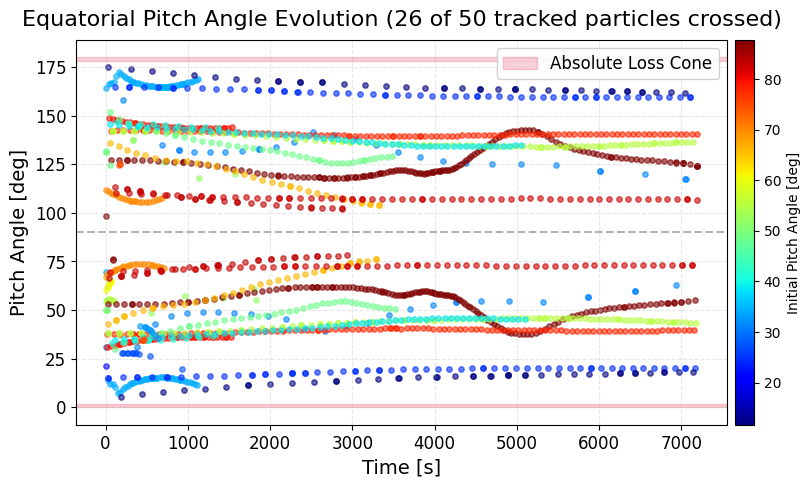

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Conservation_Check_Clean.png


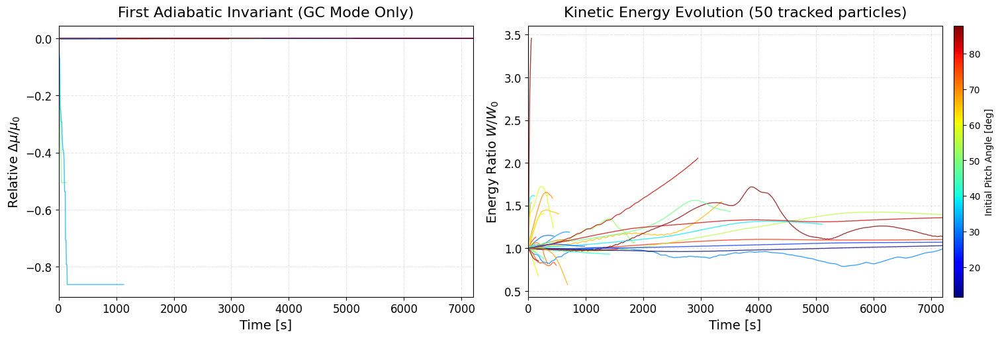

Drawing 3D Lines: 100%|██████████| 50/50 [00:00<00:00, 965.51it/s]


Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Global_Trajectory_ColorMatched.png


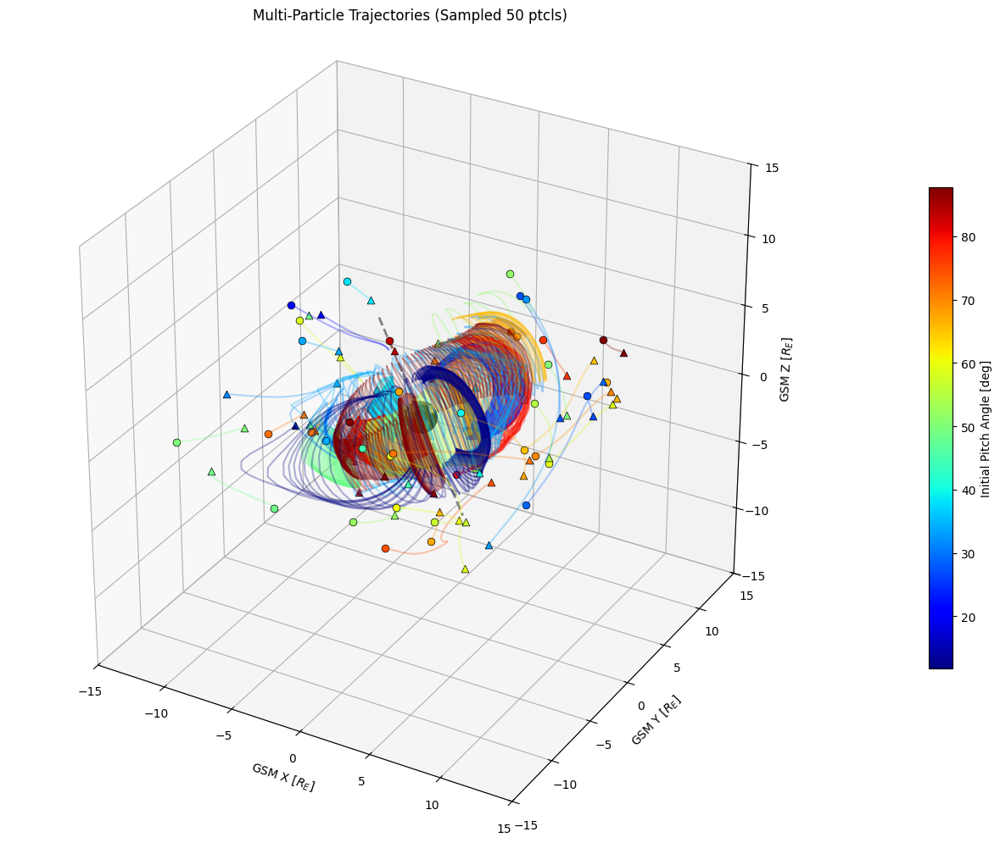

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Trajectory_Components_Clean.png


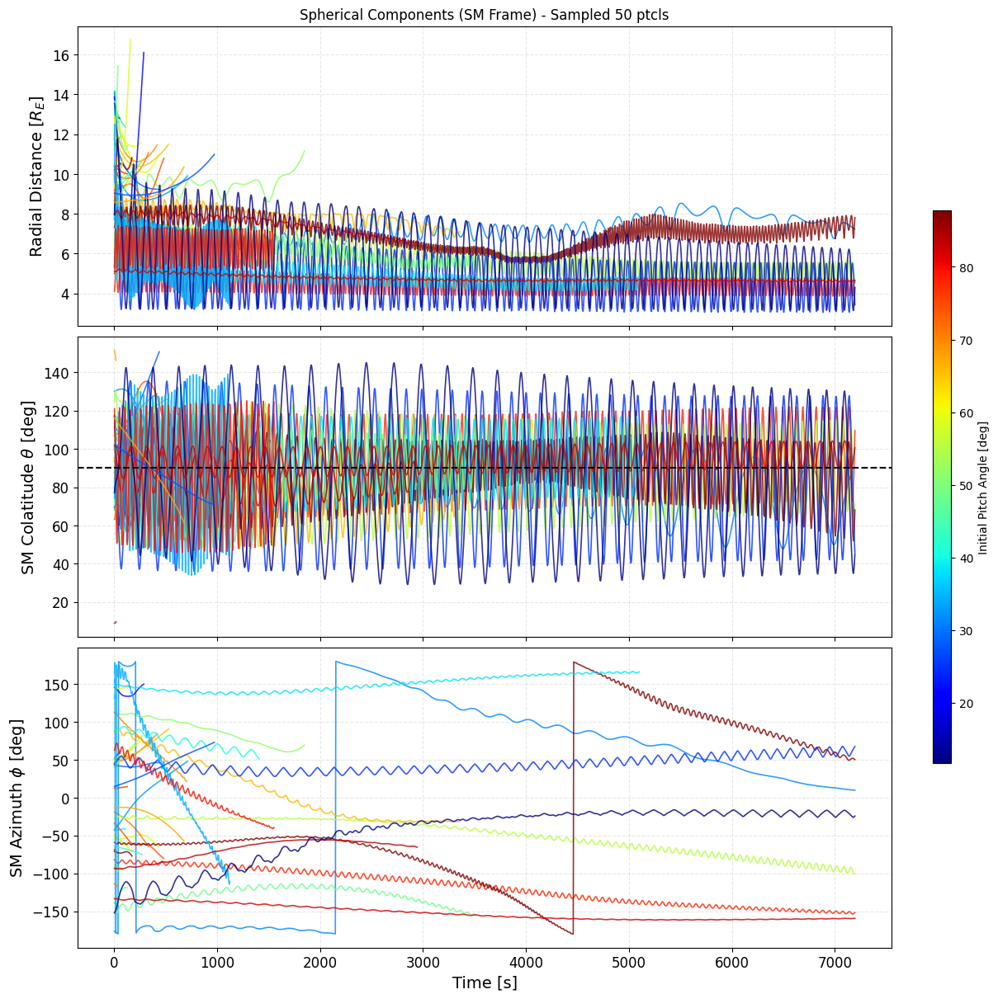

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Zoom_Dispersion.png


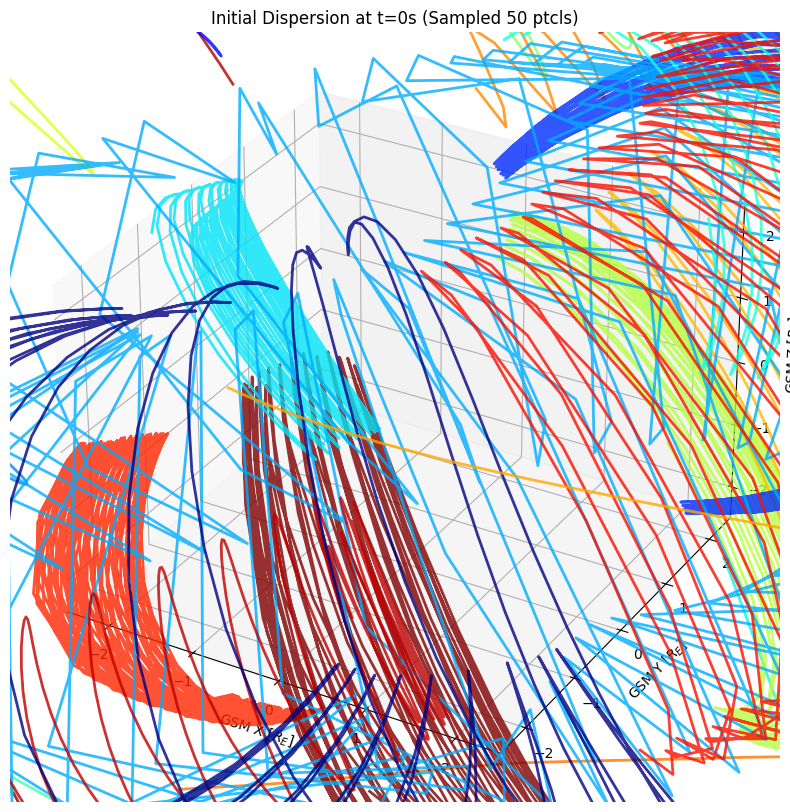

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_E_Field_Cuts.png


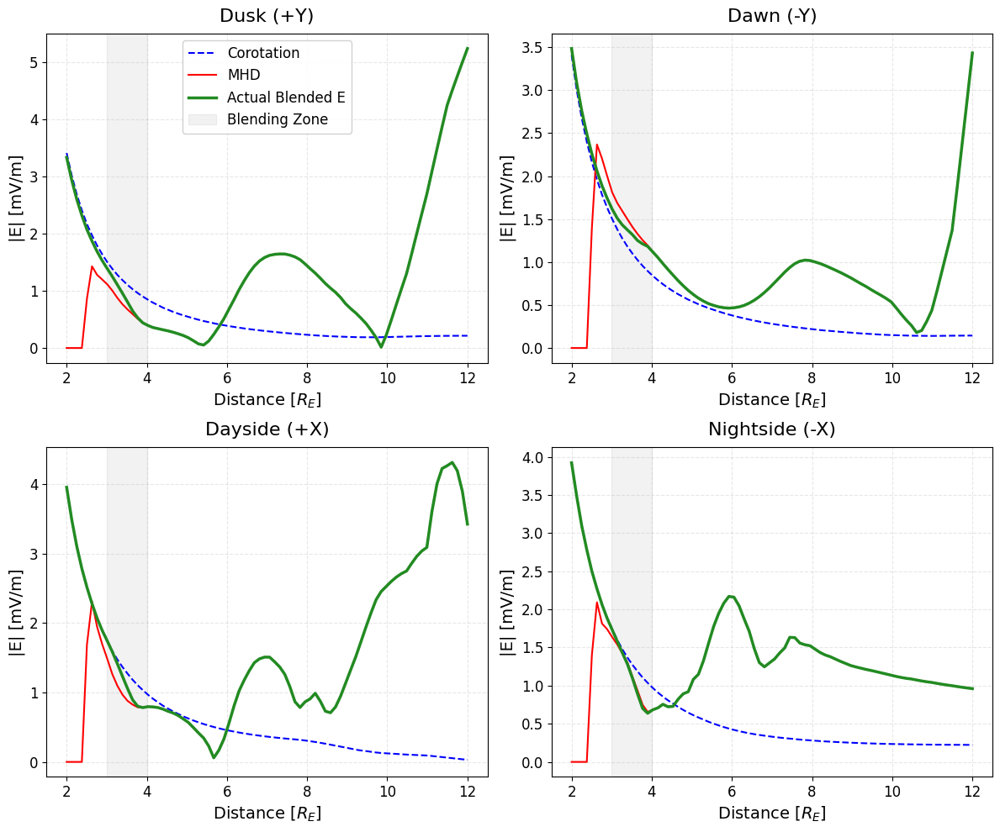

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_E_Field_Dominance_Map.png


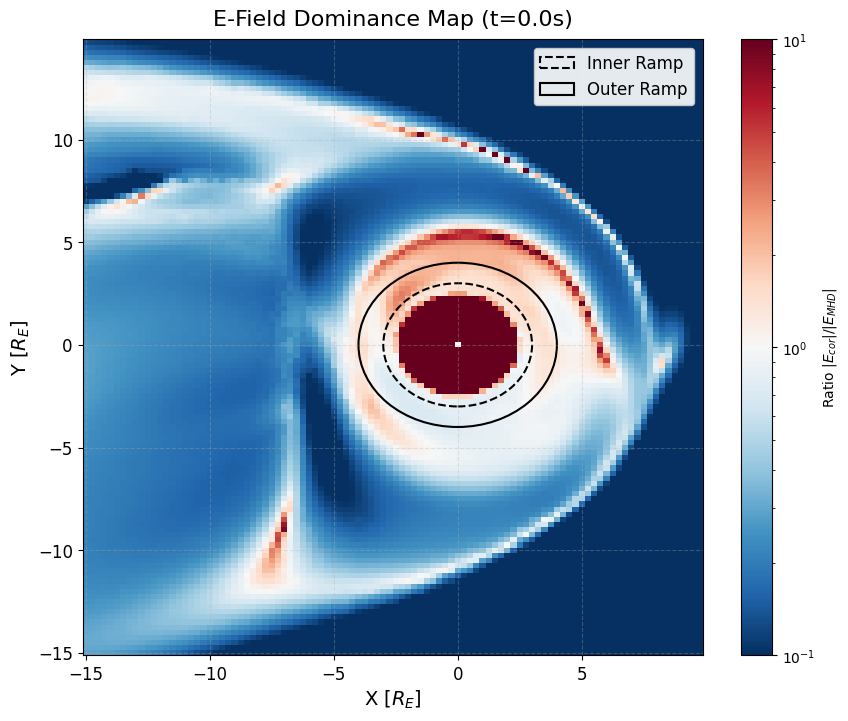

Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Bfield_XY_Topology.png


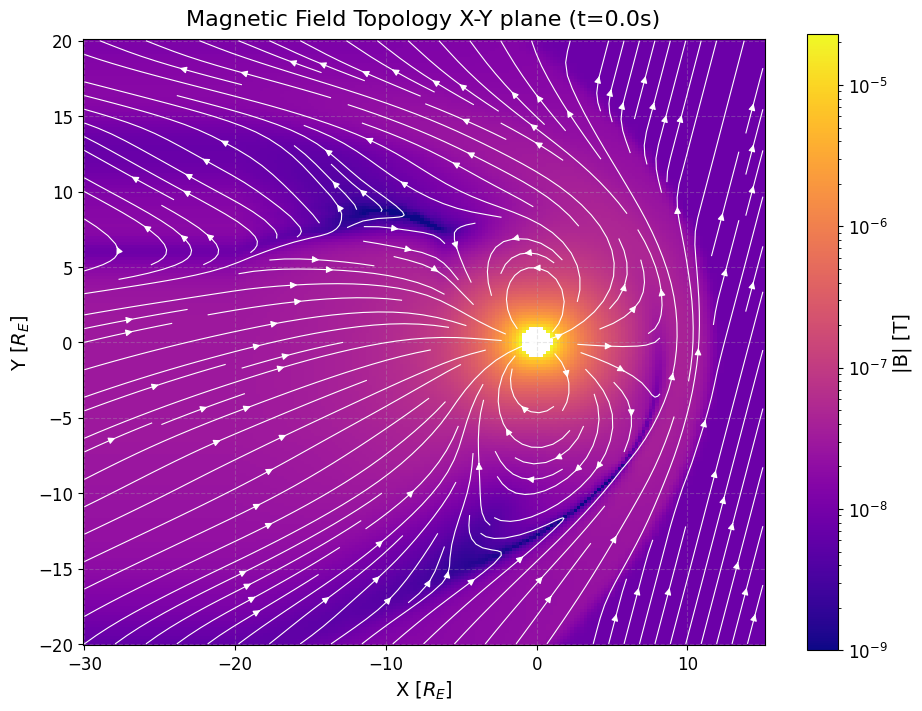

Extracting E-field: 100%|██████████| 40000/40000 [00:00<00:00, 580838.03it/s]


Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Efield_XY_Topology.png


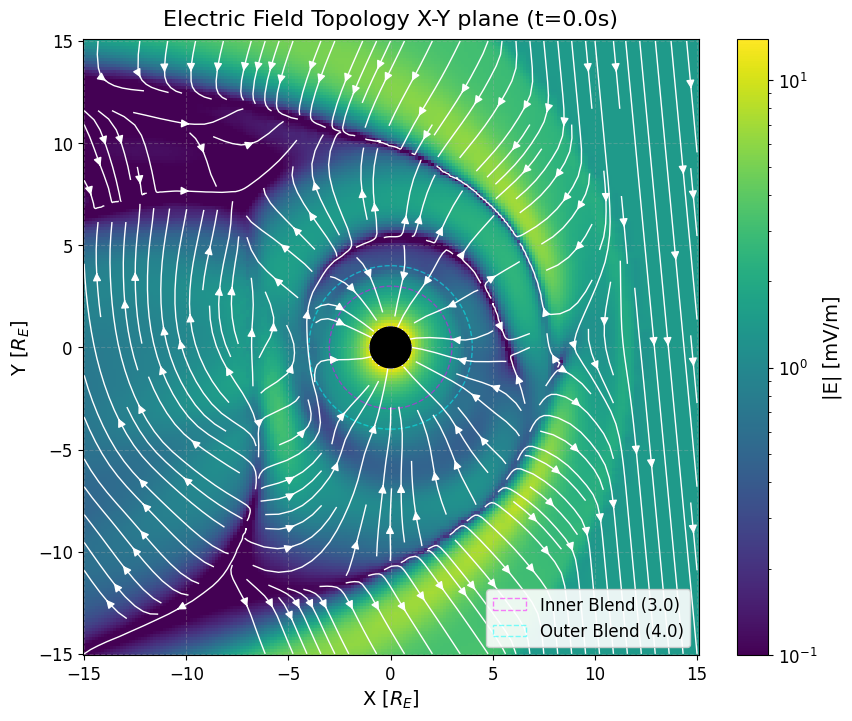

Generating Density Evolution Plot...
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_Lagrangian_Density.png




Generating 4-Panel Diagnostics from GC history...
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_GC_Global_4Panel_Diagnostics.png


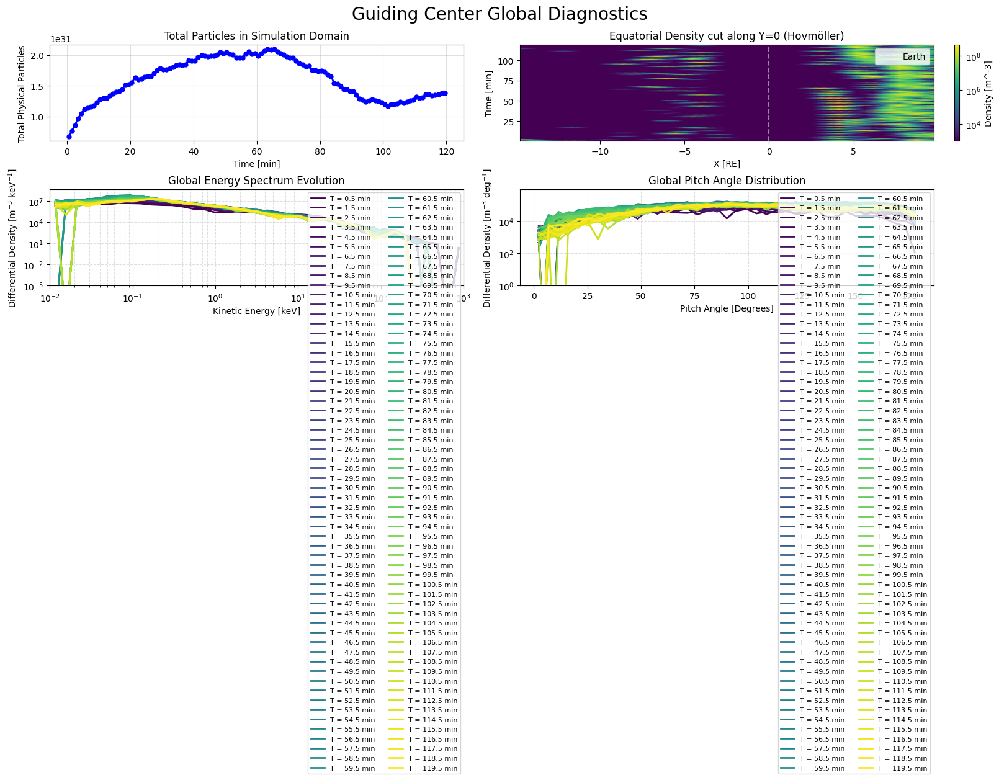

>> 90 keV gating (N_eff >= 5.0): 0 of 120 minutes have at least one reliable source.
--- Running GOES-18 Virtual Satellite Validation ---
✅ Success! Loaded GOES observational NetCDF files via h5netcdf engine.
Probing MHD Background for B-field Validation...
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_GOES18_Validation_Virtual_Sat_Flux.png


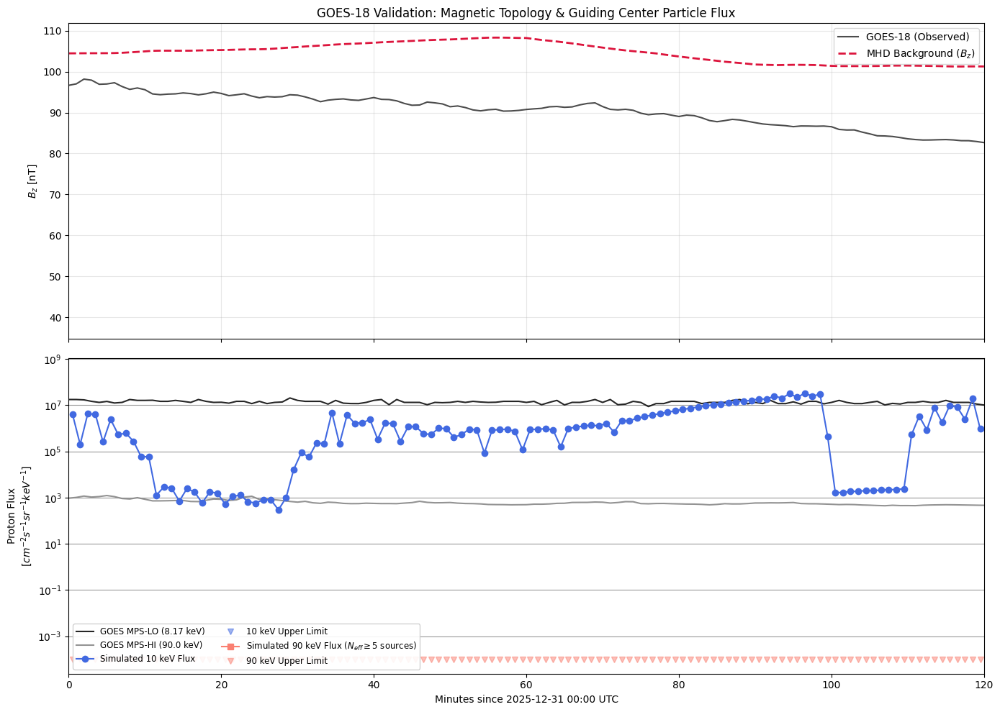

>> Saving simulation CSV data to GIFs/GuidingCenter/Run_20260930_094738...
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_fluxes.csv
Saved: GIFs/GuidingCenter/Run_20260930_094738/model_C_bz.csv
Saved: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_GOES18_90keV_Statistical_Diagnostics.png


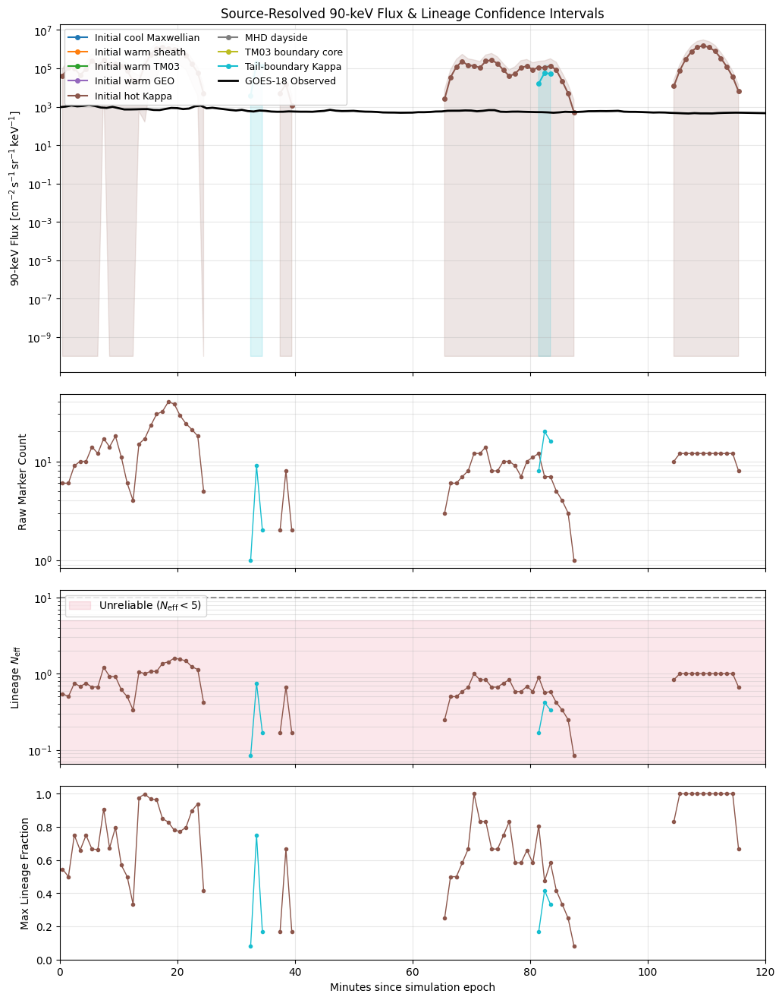

>> Compiling final simulation data for export...
>> Saving final visualization data to GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_plot_data.pkl...
>> Final plotting pickle saved successfully: GIFs/GuidingCenter/Run_20260930_094738/ProtonSim_GC_20260930_094738_plot_data.pkl
>> Pickle size: 5.97 MiB


In [2]:
# 1. HARDWARE CONFIGURATION
set_num_threads(8) # Adjust to your core count

# PHYSICAL CONSTANTS (Float64 for Physics Integration)
RE = np.float64(6.371e6)
q_e = np.float64(1.602e-19)
m_p = np.float64(1.6726219e-27)

X_MIN, X_MAX = -15.0 * RE, 10.0 * RE
Y_MIN, Y_MAX = -10.0 * RE, 10.0 * RE
Z_MIN, Z_MAX = -6.5 * RE, 6.5 * RE

# =============================================================================
# BLOCK 1: DATA LOADING & UNPACKING FOR NUMBA
# =============================================================================

print("Loading and Unpacking Interpolators for Numba...")
start_t = time.time()

try:
    # 1. Load MHD (4D: t, x, y, z)
    interps = joblib.load("Interpolators_4D_Float32.pkl")
    mhd_data = {
        'Bx': interps['Bx'].values.astype(np.float32),
        'By': interps['By'].values.astype(np.float32),
        'Bz': interps['Bz'].values.astype(np.float32),
        'Vx': interps['Vx'].values.astype(np.float32),
        'Vy': interps['Vy'].values.astype(np.float32),
        'Vz': interps['Vz'].values.astype(np.float32),
        'n_bnd': interps['n_bnd'].values.astype(np.float32),    
        'kT_bnd': interps['kT_bnd'].values.astype(np.float32)   
    }
    
    grid_t = interps['Bx'].grid[0].astype(np.float32)
    grid_x = interps['Bx'].grid[1].astype(np.float32)
    grid_y = interps['Bx'].grid[2].astype(np.float32)
    grid_z = interps['Bx'].grid[3].astype(np.float32)

    # 2. Load Tsyganenko Gap (3D: x, y, z)
    gap_interps = joblib.load("IGRF_Baked_Float32.pkl")
    gap_data = {
        'Bx': gap_interps['Bx'].values.astype(np.float32),
        'By': gap_interps['By'].values.astype(np.float32),
        'Bz': gap_interps['Bz'].values.astype(np.float32)
    }
    
    # Extract 3D Grids (Assuming they share the same spatial grids as MHD)
    gap_grid_x = gap_interps['Bx'].grid[0].astype(np.float32)
    gap_grid_y = gap_interps['Bx'].grid[1].astype(np.float32)
    gap_grid_z = gap_interps['Bx'].grid[2].astype(np.float32)

    print(f"Interpolators Ready ({time.time() - start_t:.1f}s).")

except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Could not find data files. {e}")
    raise e

min_dx = np.min(np.diff(grid_x))
min_dy = np.min(np.diff(grid_y))
min_dz = np.min(np.diff(grid_z))

# The finest cell across the entire 3D domain
finest_mhd_cell = min(min_dx, min_dy, min_dz)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
base_name = f"ProtonSim_GC_{run_id}"
run_folder = os.path.join("GIFs/GuidingCenter", f"Run_{run_id}")
os.makedirs(run_folder, exist_ok=True)
print(f"Outputs: {run_folder}")

# =============================================================================
# BLOCK 2: NUMBA INTERPOLATION ENGINE
# =============================================================================
# High-performance JIT-compiled kernels executing field interpolation, pitch-angle 
# frame decomposition, guiding-center gyro-averaging, and coordinate transformations.

@njit(fastmath=True)
def fast_norm(v):
    """Euclidean norm of a 3-vector optimized with fastmath flags."""
    return np.float64(np.sqrt(v[0]*v[0] + v[1]*v[1] + v[2]*v[2]))

@njit(fastmath=True)
def get_index_piecewise(val, grid):
    """Correct index search for arbitrary monotonic spatial grids. Safer than assuming identical origins."""
    idx = np.searchsorted(grid, val) - 1
    if idx < 0: return 0
    if idx > len(grid) - 2: return len(grid) - 2
    return idx

@njit(fastmath=True)
def get_interp_weights_4d(t, pos, t_grid, x_grid, y_grid, z_grid):
    """Calculates cell index offsets and normalized fractional distances (weights) in [0, 1] for 4D interpolation."""
    x, y, z = pos[0], pos[1], pos[2]
    # Binary search along temporal axis, analytical O(1) cell lookup along spatial axes
    it = max(0, min(np.searchsorted(t_grid, t) - 1, len(t_grid) - 2))
    ix = get_index_piecewise(x, x_grid)
    iy = get_index_piecewise(y, y_grid)
    iz = get_index_piecewise(z, z_grid)

    # Fractional weights along each axis: (val - x_i) / (x_{i+1} - x_i)
    td = max(0.0, min(1.0, (t - t_grid[it]) / (t_grid[it+1] - t_grid[it])))
    xd = max(0.0, min(1.0, (x - x_grid[ix]) / (x_grid[ix+1] - x_grid[ix])))
    yd = max(0.0, min(1.0, (y - y_grid[iy]) / (y_grid[iy+1] - y_grid[iy])))
    zd = max(0.0, min(1.0, (z - z_grid[iz]) / (z_grid[iz+1] - z_grid[iz])))
    return it, ix, iy, iz, np.float64(td), np.float64(xd), np.float64(yd), np.float64(zd)

@njit(fastmath=True)
def apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, data):
    """Executes trilinear spatial interpolation at bounding time slices, followed by linear interpolation across time."""
    omm_td, omm_xd, omm_yd, omm_zd = np.float64(1.0)-td, np.float64(1.0)-xd, np.float64(1.0)-yd, np.float64(1.0)-zd
    
    # Spatial interpolation at time t = it
    c00_0 = data[it, ix, iy, iz]*omm_xd + data[it, ix+1, iy, iz]*xd
    c01_0 = data[it, ix, iy, iz+1]*omm_xd + data[it, ix+1, iy, iz+1]*xd
    c10_0 = data[it, ix, iy+1, iz]*omm_xd + data[it, ix+1, iy+1, iz]*xd
    c11_0 = data[it, ix, iy+1, iz+1]*omm_xd + data[it, ix+1, iy+1, iz+1]*xd
    val0 = (c00_0*omm_yd + c10_0*yd)*omm_zd + (c01_0*omm_yd + c11_0*yd)*zd
    
    # Spatial interpolation at time t = it + 1
    c00_1 = data[it+1, ix, iy, iz]*omm_xd + data[it+1, ix+1, iy, iz]*xd
    c01_1 = data[it+1, ix, iy, iz+1]*omm_xd + data[it+1, ix+1, iy, iz+1]*xd
    c10_1 = data[it+1, ix, iy+1, iz]*omm_xd + data[it+1, ix+1, iy+1, iz]*xd
    c11_1 = data[it+1, ix, iy+1, iz+1]*omm_xd + data[it+1, ix+1, iy+1, iz+1]*xd
    val1 = (c00_1*omm_yd + c10_1*yd)*omm_zd + (c01_1*omm_yd + c11_1*yd)*zd
    
    return val0 * omm_td + val1 * td

@njit(fastmath=True)
def fast_vec_4d(t, pos, gt, gx, gy, gz, d_x, d_y, d_z):
    """Evaluates a 3D vector field (e.g., B or V) at an arbitrary 4D coordinate (t, x, y, z)."""
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, pos, gt, gx, gy, gz)
    vx = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_x)
    vy = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_y)
    vz = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_z)
    return vx, vy, vz

@njit(fastmath=True)
def fast_scalar_4d(t, pos, gt, gx, gy, gz, data):
    """Evaluates a 4D scalar moment (e.g., plasma density or temperature) at (t, x, y, z)."""
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, pos, gt, gx, gy, gz)
    return apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, data)

@njit(fastmath=True)
def make_perpendicular_basis(b_hat):
    """Constructs an orthonormal right-handed basis (b_hat, e1, e2) aligned with local magnetic field vector."""
    if abs(b_hat[1]) < 0.9: ref_x, ref_y, ref_z = 0.0, 1.0, 0.0
    else: ref_x, ref_y, ref_z = 1.0, 0.0, 0.0

    # e1 = (b_hat x ref) / |b_hat x ref|
    e1_x = b_hat[1] * ref_z - b_hat[2] * ref_y
    e1_y = b_hat[2] * ref_x - b_hat[0] * ref_z
    e1_z = b_hat[0] * ref_y - b_hat[1] * ref_x
    e1_mag = math.sqrt(e1_x**2 + e1_y**2 + e1_z**2) + 1.0e-30
    e1_x /= e1_mag; e1_y /= e1_mag; e1_z /= e1_mag

    # e2 = b_hat x e1
    e2_x = b_hat[1] * e1_z - b_hat[2] * e1_y
    e2_y = b_hat[2] * e1_x - b_hat[0] * e1_z
    e2_z = b_hat[0] * e1_y - b_hat[1] * e1_x
    return e1_x, e1_y, e1_z, e2_x, e2_y, e2_z

@njit
def sample_common_boundary_velocity(v_th_selected, is_kappa, kappa_value, vx_bulk, vy_bulk, vz_bulk, E, B):
    """Draws a 3D velocity vector for an injected particle (thermal Maxwellian or suprathermal Kappa)."""
    Bmag = math.sqrt(B[0]**2 + B[1]**2 + B[2]**2) + 1.0e-30
    b_hat = (B[0]/Bmag, B[1]/Bmag, B[2]/Bmag)
    e1_x, e1_y, e1_z, e2_x, e2_y, e2_z = make_perpendicular_basis(b_hat)
    B_sq_inv = 1.0 / (Bmag * Bmag)

    # Convective ExB drift velocity: v_ExB = (E x B) / B^2
    v_exb_x = (E[1] * B[2] - E[2] * B[1]) * B_sq_inv
    v_exb_y = (E[2] * B[0] - E[0] * B[2]) * B_sq_inv
    v_exb_z = (E[0] * B[1] - E[1] * B[0]) * B_sq_inv

    # Project the bulk fluid velocity onto the magnetic field line
    v_parallel_bulk = (vx_bulk * b_hat[0] + vy_bulk * b_hat[1] + vz_bulk * b_hat[2])

    # Box-Muller transform for standard normal random deviates
    u1, u2, u3, u4 = max(1.0e-15, np.random.random()), np.random.random(), max(1.0e-15, np.random.random()), np.random.random()
    gaussian_parallel = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
    gaussian_perp_1 = math.sqrt(-2.0 * math.log(u3)) * math.cos(2.0 * math.pi * u4)
    gaussian_perp_2 = math.sqrt(-2.0 * math.log(u3)) * math.sin(2.0 * math.pi * u4)

    # Kappa distribution scaling via Gamma distribution mixture model
    if is_kappa:
        gamma_draw = np.random.gamma(kappa_value - 0.5, 1.0)
        kappa_scale = math.sqrt((kappa_value - 1.5) / max(gamma_draw, 1.0e-12))
    else:
        kappa_scale = 1.0

    # Scale isotropic thermal fluctuations
    v_parallel = v_parallel_bulk + v_th_selected * kappa_scale * gaussian_parallel
    v_perp_1 = v_th_selected * kappa_scale * gaussian_perp_1
    v_perp_2 = v_th_selected * kappa_scale * gaussian_perp_2

    # Map perpendicular velocity components back into the global 3D Cartesian frame
    v_perp_x = v_perp_1 * e1_x + v_perp_2 * e2_x
    v_perp_y = v_perp_1 * e1_y + v_perp_2 * e2_y
    v_perp_z = v_perp_1 * e1_z + v_perp_2 * e2_z

    # Full particle velocity
    v_particle_x = v_parallel * b_hat[0] + v_perp_x + v_exb_x
    v_particle_y = v_parallel * b_hat[1] + v_perp_y + v_exb_y
    v_particle_z = v_parallel * b_hat[2] + v_perp_z + v_exb_z

    return (v_parallel, v_perp_1, v_perp_2, v_particle_x, v_particle_y, v_particle_z,
            e1_x, e1_y, e1_z, e2_x, e2_y, e2_z, v_exb_x, v_exb_y, v_exb_z)

@njit(fastmath=True)
def guiding_center_from_particle(particle_position, v_perp_1, v_perp_2, b_hat, e1, e2, Bmag, mass, charge):
    """Transforms a true physical particle coordinate into its guiding center position."""
    v_perp_x = v_perp_1 * e1[0] + v_perp_2 * e2[0]
    v_perp_y = v_perp_1 * e1[1] + v_perp_2 * e2[1]
    v_perp_z = v_perp_1 * e1[2] + v_perp_2 * e2[2]

    cross_x = v_perp_y * b_hat[2] - v_perp_z * b_hat[1]
    cross_y = v_perp_z * b_hat[0] - v_perp_x * b_hat[2]
    cross_z = v_perp_x * b_hat[1] - v_perp_y * b_hat[0]

    rho_scale = mass / (charge * Bmag + 1.0e-30)
    return (particle_position[0] + rho_scale * cross_x,
            particle_position[1] + rho_scale * cross_y,
            particle_position[2] + rho_scale * cross_z)

@njit(fastmath=True)
def position_strictly_inside_box(pos):
    """Checks whether a coordinate lies strictly within the simulation domain bounds."""
    return (pos[0] > X_MIN and pos[0] < X_MAX and 
            pos[1] > Y_MIN and pos[1] < Y_MAX and 
            pos[2] > Z_MIN and pos[2] < Z_MAX)

# =============================================================================
# PHYSICS ENGINE & BOUNDARY SAMPLING
# =============================================================================
# External solar wind driver parameters for the Tsyganenko T96 magnetic field model
T96_PARAM = [1.51442, 24, 4, 6, 0, 0, 0, 0, 0, 0]
PSI_RAD = 0.0  # Earth dipole tilt angle in radians (updated via ephemeris)

@njit
def execute_boundary_injection_constant_weight(
    t_inject, dt_inject, num_available_slots, constant_weight,
    gt, gx, gy, gz, N_sw, V_sw, Bz,
    n_core, kT_core, n_tail, kT_tail, kappa_geo, B_geo_ref,
    mhd_kT_bnd, mhd_n_bnd, mhd_Vx, mhd_Vy, mhd_Vz,
    mhd_Bx, mhd_By, mhd_Bz, gap_Bx, gap_By, gap_Bz,
    omega_earth_gsm, q_e, m_p, RE, start_lineage_id
):
    """Injects synthetic particle markers across the 6 domain boundaries using Monte Carlo rejection sampling."""
    # Surface areas of the domain bounding box
    A_x = (Y_MAX - Y_MIN) * (Z_MAX - Z_MIN)
    A_y = (X_MAX - X_MIN) * (Z_MAX - Z_MIN)
    A_z = (X_MAX - X_MIN) * (Y_MAX - Y_MIN)
    A_total = 2.0 * (A_x + A_y + A_z)

    # Face selection probabilities proportional to area
    p_x, p_y, p_z = A_x / A_total, A_y / A_total, A_z / A_total

    # Preallocate output marker buffers
    x_new = np.zeros((num_available_slots, 3), dtype=np.float64)
    v_par_new = np.zeros(num_available_slots, dtype=np.float64)
    mu_new = np.zeros(num_available_slots, dtype=np.float64)
    w_mult_new = np.ones(num_available_slots, dtype=np.float64)
    source_new = np.full(num_available_slots, np.int8(-1), dtype=np.int8)
    lineage_new = np.zeros(num_available_slots, dtype=np.int64)
    W0_new = np.zeros(num_available_slots, dtype=np.float64)
    B0_new = np.zeros(num_available_slots, dtype=np.float64)

    accepted_count = 0
    n_max, vx_max = np.float64(100.0e6), np.float64(2.0e6)  # Bound constraints
    max_flux = n_max * vx_max

    max_physical_particles_in_dt = max_flux * A_total * dt_inject
    N_test_float = max_physical_particles_in_dt / constant_weight
    N_test_requested = int(N_test_float)

    # Stochastic rounding for fractional marker proposals
    if np.random.random() < (N_test_float - float(N_test_requested)):
        N_test_requested += 1

    N_test = min(N_test_requested, num_available_slots * 3)
    proposals_executed = 0
    slot_limited = False
    proposal_weight_scale = (N_test_float / float(N_test)) if N_test > 0 else 0.0

    for _ in range(N_test):
        proposals_executed += 1
        if accepted_count >= num_available_slots:
            if proposals_executed <= N_test: slot_limited = True
            break

        # Roll a face uniformly proportional to area
        face_roll = np.random.random()
        face_id = np.int8(-1)

        # Assign Face ID based on probability limits
        if face_roll < p_x:
            face_id = np.int8(0)
            pos_test = np.array([X_MIN, np.random.uniform(Y_MIN, Y_MAX), np.random.uniform(Z_MIN, Z_MAX)], dtype=np.float64)
            normal_in = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        elif face_roll < 2.0 * p_x:
            face_id = np.int8(1)
            pos_test = np.array([X_MAX, np.random.uniform(Y_MIN, Y_MAX), np.random.uniform(Z_MIN, Z_MAX)], dtype=np.float64)
            normal_in = np.array([-1.0, 0.0, 0.0], dtype=np.float64)
        elif face_roll < 2.0 * p_x + p_y:
            face_id = np.int8(2)
            pos_test = np.array([np.random.uniform(X_MIN, X_MAX), Y_MIN, np.random.uniform(Z_MIN, Z_MAX)], dtype=np.float64)
            normal_in = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        elif face_roll < 2.0 * p_x + 2.0 * p_y:
            face_id = np.int8(3)
            pos_test = np.array([np.random.uniform(X_MIN, X_MAX), Y_MAX, np.random.uniform(Z_MIN, Z_MAX)], dtype=np.float64)
            normal_in = np.array([0.0, -1.0, 0.0], dtype=np.float64)
        elif face_roll < 2.0 * p_x + 2.0 * p_y + p_z:
            face_id = np.int8(4)
            pos_test = np.array([np.random.uniform(X_MIN, X_MAX), np.random.uniform(Y_MIN, Y_MAX), Z_MIN], dtype=np.float64)
            normal_in = np.array([0.0, 0.0, 1.0], dtype=np.float64)
        else:
            face_id = np.int8(5)
            pos_test = np.array([np.random.uniform(X_MIN, X_MAX), np.random.uniform(Y_MIN, Y_MAX), Z_MAX], dtype=np.float64)
            normal_in = np.array([0.0, 0.0, -1.0], dtype=np.float64)

        # Retrieve background electric and magnetic fields at the proposal site
        E, B = get_fields_numba(t_inject, pos_test, True, gt, gx, gy, gz, mhd_Bx, mhd_By, mhd_Bz, mhd_Vx, mhd_Vy, mhd_Vz, gap_Bx, gap_By, gap_Bz, omega_earth_gsm)
        Bmag_loc = fast_norm(B) + 1e-30
        b_hat = np.array([B[0]/Bmag_loc, B[1]/Bmag_loc, B[2]/Bmag_loc], dtype=np.float64)
        adiabatic_ratio = min(1.0, Bmag_loc / B_geo_ref)

        # Interpolate local MHD moments
        it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4 = get_interp_weights_4d(t_inject, pos_test, gt, gx, gy, gz)
        vx_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vx) * 1e3
        vy_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vy) * 1e3
        vz_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_Vz) * 1e3
        mhd_n_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_n_bnd)
        mhd_kT_loc = apply_interp_4d(it_4, ix_4, iy_4, iz_4, td_4, xd_4, yd_4, zd_4, mhd_kT_bnd)

        if not math.isfinite(mhd_n_loc) or mhd_n_loc <= 0.0: continue
        if not math.isfinite(mhd_kT_loc) or mhd_kT_loc <= 0.0: continue

        # Compute inward bulk velocity component normal to the boundary face
        v_bulk_inward = max(0.0, vx_loc * normal_in[0] + vy_loc * normal_in[1] + vz_loc * normal_in[2])
        x_re_test, y_re_test, z_re_test = pos_test[0]/RE, pos_test[1]/RE, pos_test[2]/RE
        v_th_sheath = v_th_core = v_th_tail = 0.0

        # Discriminate boundary populations based on spatial location: Dayside vs Nightside
        if x_re_test > 9.9:
            n_sheath, kT_sheath = mhd_n_loc, mhd_kT_loc
            v_th_sheath = math.sqrt(kT_sheath / m_p)
            flux_sheath = n_sheath * max(v_bulk_inward, 0.4 * v_th_sheath)
            flux_core = flux_tail = 0.0
            flux_loc = flux_sheath
            p_sheath, p_core = 1.0, 0.0
        else:
            _, kT_loc = get_tm03_proxy(x_re_test, y_re_test, N_sw, V_sw, Bz)
            z_decay = math.exp(-((z_re_test / 3.0) ** 2))
            n_loc = mhd_n_loc * z_decay
            v_th_core = math.sqrt(max(1e-20, kT_loc) / m_p)
            flux_core = n_loc * max(v_bulk_inward, 0.4 * v_th_core)

            # Restrict hot Kappa tail injection to tail and flank faces close to equatorial plane
            allow_kappa = (face_id in (np.int8(0), np.int8(2), np.int8(3)) and x_re_test < 0.0 and abs(z_re_test) <= 3.0)
            if allow_kappa:
                kT_hot_tail = kT_tail * adiabatic_ratio * 1000.0 * q_e
                n_hot_tail = n_tail * 1e6 * (mhd_n_loc / max(n_core * 1e6, 1e-30)) * z_decay
                v_th_tail = math.sqrt(max(1e-30, kT_hot_tail / m_p))
                flux_tail = n_hot_tail * max(v_bulk_inward, 0.4 * v_th_tail)
            else:
                flux_tail, v_th_tail = 0.0, 0.0

            flux_loc = flux_core + flux_tail
            p_sheath, p_core = 0.0, flux_core / (flux_loc + 1e-30)

        # Rejection sampling against the envelope
        if not math.isfinite(flux_loc) or flux_loc <= 0.0 or flux_loc > max_flux: continue
        if np.random.uniform(0.0, max_flux) >= flux_loc: continue

        pop_roll = np.random.random()
        if pop_roll < p_sheath: v_th_selected, is_kappa, selected_source = v_th_sheath, False, SOURCE_MHD_DAYSIDE
        elif pop_roll < p_sheath + p_core: v_th_selected, is_kappa, selected_source = v_th_core, False, SOURCE_TM03_CORE
        else: v_th_selected, is_kappa, selected_source = v_th_tail, True, SOURCE_TAIL_KAPPA

        # Sample velocity vector
        (v_par_rand, v_perp_1, v_perp_2, v_particle_x, v_particle_y, v_particle_z,
         e1_x, e1_y, e1_z, e2_x, e2_y, e2_z, v_exb_x, v_exb_y, v_exb_z) = sample_common_boundary_velocity(
            v_th_selected, is_kappa, kappa_geo, vx_loc, vy_loc, vz_loc, E, B)

        v_ptcl_inward = (v_particle_x * normal_in[0] + v_particle_y * normal_in[1] + v_particle_z * normal_in[2])
        if v_ptcl_inward <= 0.0: continue

        flux_weight = min(v_ptcl_inward / max(1.0e-5, v_bulk_inward + 0.5 * v_th_selected), 5.0)
        v_perp_mag = math.sqrt(v_perp_1**2 + v_perp_2**2)
        b_hat_tuple = (b_hat[0], b_hat[1], b_hat[2])
        e1_tuple, e2_tuple = (e1_x, e1_y, e1_z), (e2_x, e2_y, e2_z)

        # Nudge particle slightly inward from surface to prevent immediate boundary clipping
        injection_inset = np.float64(1.0e-3) * RE
        x_particle_inside = (pos_test[0] + injection_inset * normal_in[0],
                             pos_test[1] + injection_inset * normal_in[1],
                             pos_test[2] + injection_inset * normal_in[2])

        x_candidate = guiding_center_from_particle(x_particle_inside, v_perp_1, v_perp_2, b_hat_tuple, e1_tuple, e2_tuple, Bmag_loc, m_p, q_e)

        # Verify bounds and inner collisional loss sphere
        if not position_strictly_inside_box(x_candidate): continue
        if (x_candidate[0]**2 + x_candidate[1]**2 + x_candidate[2]**2) <= (2.0 * RE)**2: continue

        x_new[accepted_count, 0] = x_candidate[0]
        x_new[accepted_count, 1] = x_candidate[1]
        x_new[accepted_count, 2] = x_candidate[2]
        v_par_new[accepted_count] = v_par_rand
        mu_new[accepted_count] = 0.5 * m_p * v_perp_mag**2 / Bmag_loc
        w_mult_new[accepted_count] = flux_weight * proposal_weight_scale
        source_new[accepted_count] = selected_source
        lineage_new[accepted_count] = start_lineage_id + accepted_count 
        W0_new[accepted_count] = 0.5 * m_p * (v_par_rand**2 + v_perp_mag**2)
        B0_new[accepted_count] = Bmag_loc
        accepted_count += 1

    return (accepted_count, x_new, v_par_new, mu_new, w_mult_new, source_new, lineage_new, W0_new, B0_new, N_test_float, N_test, proposal_weight_scale, slot_limited)

def get_ephemeris_params(time_input):
    """
    Computes Earth's spin axis vector and magnetic dipole axis in the GSM coordinate system.
    Accounts for orbital eccentricity, solar position, Greenwich Sidereal Time (GST), 
    and geomagnetic dipole tilt.
    """
    d2r = np.pi / 180.0
    OMEGA_MAG = 7.2921159e-5  # Earth's angular rotation rate (rad/s)

    # Initialize Geopack's internal epoch tracking
    ut_timestamp = time_input.replace(tzinfo=timezone.utc).timestamp()
    geopack.recalc(ut_timestamp)
    global PSI_RAD
    PSI_RAD = geopack.psi 
    
    # Geographic coordinates of geomagnetic North Pole
    lat_rad, lon_rad = 79.6 * d2r, 280.6 * d2r
    M_geo = np.array([np.cos(lat_rad)*np.cos(lon_rad), np.cos(lat_rad)*np.sin(lon_rad), np.sin(lat_rad)])
    omega_geo = np.array([0.0, 0.0, 1.0])

    # Astronomical Julian Date calculation
    y, m, d = time_input.year, time_input.month, time_input.day
    h_utc = time_input.hour + time_input.minute/60 + time_input.second/3600
    jd = 367*y - int(7*(y + int((m+9)/12))/4) + int(275*m/9) + d + 1721013.5 + h_utc/24
    T_0 = (jd - 2451545.0) / 36525.0

    # Solar position in Geocentric Equatorial Inertial (GEI) coordinates
    L0 = (280.46646 + 36000.76983 * T_0) % 360
    M_anom = (357.52911 + 35999.05029 * T_0) % 360
    lambda_sun = (L0 + 1.914602 * np.sin(M_anom * d2r) + 0.019993 * np.sin(2 * M_anom * d2r)) * d2r
    epsilon = (23.439291 - 0.0130042 * T_0) * d2r
    S_gei = np.array([np.cos(lambda_sun), np.cos(epsilon)*np.sin(lambda_sun), np.sin(epsilon)*np.sin(lambda_sun)])

    # Greenwich Mean Sidereal Time (GST) to transform GEI -> GEO
    theta_GST = (100.46061815 + 36000.77005361 * T_0 + 360.98564724 * (jd - 2451545.0)) % 360 
    th_rad = theta_GST * d2r
    cos_th, sin_th = np.cos(th_rad), np.sin(th_rad)
    S_geo = np.array([S_gei[0]*cos_th + S_gei[1]*sin_th, -S_gei[0]*sin_th + S_gei[1]*cos_th, S_gei[2]])
    S_geo /= np.sqrt(S_geo[0]**2 + S_geo[1]**2 + S_geo[2]**2)

    # Establish GSM triad:
    # X_gsm: Earth-Sun line
    # Y_gsm: Orthogonal to X_gsm and Earth's magnetic dipole axis (M_geo)
    # Z_gsm: Completes right-handed system (X x Y)
    X_gsm = S_geo 
    Y_gsm = np.cross(M_geo, S_geo); Y_gsm /= np.sqrt(Y_gsm[0]**2 + Y_gsm[1]**2 + Y_gsm[2]**2)
    Z_gsm = np.cross(X_gsm, Y_gsm)
    basis_gsm = np.vstack([X_gsm, Y_gsm, Z_gsm])

    return OMEGA_MAG * (basis_gsm @ omega_geo), basis_gsm @ M_geo

def make_goes_telescope_vectors(sat_pos):
    """Generates the 6 directional pointing vectors for the GOES virtual telescopes."""
    r_vec = np.asarray(sat_pos, dtype=np.float64)
    r_mag = np.linalg.norm(r_vec) + 1.0e-30
    e_radial = r_vec / r_mag
    
    reference_north = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    e_east = np.cross(reference_north, e_radial)
    east_mag = np.linalg.norm(e_east)
    
    if east_mag < 1.0e-12:
        reference_north = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        e_east = np.cross(reference_north, e_radial)
        east_mag = np.linalg.norm(e_east)
        
    e_east /= east_mag
    e_north = np.cross(e_radial, e_east)
    e_north /= np.linalg.norm(e_north)
    
    return np.array([e_radial, -e_radial, e_east, -e_east, e_north, -e_north])

def get_gap_field_single(pos_meters):
    """Calculates internal Earth dipole/IGRF field for a point in meters, returning Tesla."""
    RE_M = 6.371e6
    x_re, y_re, z_re = pos_meters[0]/RE_M, pos_meters[1]/RE_M, pos_meters[2]/RE_M
    bx_int, by_int, bz_int = geopack.igrf_gsm(x_re, y_re, z_re)
    return np.array([bx_int, by_int, bz_int]) * 1e-9

@njit(fastmath=True)
def get_volland_stern_E(pos, B_local, Kp):
    """
    Calculates the semi-empirical Volland-Stern cross-tail convection electric field (V/m),
    shielded by inner magnetospheric plasma and parameterized by geomagnetic Kp index.
    Projects out any parallel component to maintain E_parallel = 0.
    """
    x, y, z = pos[0], pos[1], pos[2]
    r_sq_2d = x*x + y*y
    if r_sq_2d < 1e-10: return 0.0, 0.0, 0.0
        
    r_2d = np.sqrt(r_sq_2d)
    # Maynard & Chen (1975) Kp-dependent potential factor
    denom = 1.0 - 0.159 * Kp + 0.0093 * (Kp**2)
    A = 45.0 / (denom**3) 
    
    # Convective electric field components derived from potential Phi = A * r^gamma * sin(phi)
    Ex = A * (x * y) / (RE**2 * r_2d)
    Ey = A * (x*x + 2.0 * y*y) / (RE**2 * r_2d)
    Ez = 0.0
    
    # Project out any parallel electric field along B to enforce ideal MHD condition (E . b_hat = 0)
    Bmag = np.sqrt(B_local[0]**2 + B_local[1]**2 + B_local[2]**2) + 1e-30
    bx, by, bz = B_local[0]/Bmag, B_local[1]/Bmag, B_local[2]/Bmag
    
    E_dot_b = Ex * bx + Ey * by + Ez * bz
    return np.float64(Ex - E_dot_b * bx), np.float64(Ey - E_dot_b * by), np.float64(Ez - E_dot_b * bz)

@njit(fastmath=True) 
def get_fields_numba(t, pos, calc_E, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """
    Synthesizes total electric and magnetic fields at an arbitrary coordinate.
    
    In the inner magnetosphere (r < R_IN = 3 RE), pure MHD models fail to resolve 
    corotation and inner plasmaspheric shielding. We therefore smoothly blend 
    an analytical inner model (Volland-Stern convection + corotation E = -(omega x r) x B) 
    with the outer global MHD electric field (-V_mhd x B) across a buffer zone [R_IN, R_OUT].
    """
    r_sq = pos[0]**2 + pos[1]**2 + pos[2]**2
    r_mag = np.sqrt(r_sq)
    r_re = r_mag / 6.371e6
    
    # Interpolate 4D magnetic field (convert nT to Tesla)
    bx, by, bz = fast_vec_4d(t, pos, gt, gx, gy, gz, mbx, mby, mbz)
    bx *= 1e-9; by *= 1e-9; bz *= 1e-9
    
    if not calc_E: 
        return (0.0, 0.0, 0.0), (bx, by, bz)
    
    # Interpolate bulk plasma velocity (convert km/s to m/s)
    vx, vy, vz = fast_vec_4d(t, pos, gt, gx, gy, gz, mvx, mvy, mvz)
    vx *= 1e3; vy *= 1e3; vz *= 1e3
    
    # Ideal MHD convection electric field: E_mhd = - V x B
    Ex_mhd = by * vz - bz * vy
    Ey_mhd = bz * vx - bx * vz
    Ez_mhd = bx * vy - by * vx

    # Inner convection field from Volland-Stern model
    Ex_vs, Ey_vs, Ez_vs = get_volland_stern_E(pos, (bx, by, bz), np.float64(KP_INDEX))
    
    # Inner corotation electric field: E_corot = - (omega x r) x B
    alpha_cor = max(0.0, min(1.0, (3.1855e7 - r_mag) / 9.5565e6))
    v_co_x = omega_earth_gsm[1]*pos[2] - omega_earth_gsm[2]*pos[1]
    v_co_y = omega_earth_gsm[2]*pos[0] - omega_earth_gsm[0]*pos[2]
    v_co_z = omega_earth_gsm[0]*pos[1] - omega_earth_gsm[1]*pos[0]
    
    Ex_inner = Ex_vs + alpha_cor * (by * v_co_z - bz * v_co_y)
    Ey_inner = Ey_vs + alpha_cor * (bz * v_co_x - bx * v_co_z)
    Ez_inner = Ez_vs + alpha_cor * (bx * v_co_y - by * v_co_x)

    # Smooth cubic polynomial blending between inner analytical model and outer MHD
    if r_re <= R_IN:
        Ex, Ey, Ez = Ex_inner, Ey_inner, Ez_inner
    elif r_re >= R_OUT:
        Ex, Ey, Ez = Ex_mhd, Ey_mhd, Ez_mhd
    else:
        x = (r_re - R_IN) / (R_OUT - R_IN)
        w = x * x * (np.float64(3.0) - np.float64(2.0) * x)  # Hermite cubic smoothstep: 3x^2 - 2x^3
        omm_w = 1.0 - w
        Ex = omm_w * Ex_inner + w * Ex_mhd
        Ey = omm_w * Ey_inner + w * Ey_mhd
        Ez = omm_w * Ez_inner + w * Ez_mhd
        
    return (Ex, Ey, Ez), (bx, by, bz)

@njit(fastmath=True)
def compute_gradients_numba(t, pos, B_tup, delta_arr, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """
    Computes spatial derivatives of the magnetic field using central finite differences:
      1. Scalar field magnitude gradient: grad(|B|)
      2. Magnetic field line curvature vector: kappa = (b_hat . grad) b_hat
    These spatial derivatives govern the gradient and curvature drifts in guiding-center theory.
    """
    dx, dy, dz = delta_arr[0], delta_arr[1], delta_arr[2]
    
    # Forward/backward evaluation along X
    pos_px = (pos[0] + dx, pos[1], pos[2])
    pos_mx = (pos[0] - dx, pos[1], pos[2])
    _, B_px = get_fields_numba(t, pos_px, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mx = get_fields_numba(t, pos_mx, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_px = math.sqrt(B_px[0]**2 + B_px[1]**2 + B_px[2]**2)
    Bm_mx = math.sqrt(B_mx[0]**2 + B_mx[1]**2 + B_mx[2]**2)
    grad_x = (Bm_px - Bm_mx) / (2.0 * dx)

    # Forward/backward evaluation along Y
    pos_py = (pos[0], pos[1] + dy, pos[2])
    pos_my = (pos[0], pos[1] - dy, pos[2])
    _, B_py = get_fields_numba(t, pos_py, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_my = get_fields_numba(t, pos_my, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_py = math.sqrt(B_py[0]**2 + B_py[1]**2 + B_py[2]**2)
    Bm_my = math.sqrt(B_my[0]**2 + B_my[1]**2 + B_my[2]**2)
    grad_y = (Bm_py - Bm_my) / (2.0 * dy)

    # Forward/backward evaluation along Z
    pos_pz = (pos[0], pos[1], pos[2] + dz)
    pos_mz = (pos[0], pos[1], pos[2] - dz)
    _, B_pz = get_fields_numba(t, pos_pz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mz = get_fields_numba(t, pos_mz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_pz = math.sqrt(B_pz[0]**2 + B_pz[1]**2 + B_pz[2]**2)
    Bm_mz = math.sqrt(B_mz[0]**2 + B_mz[1]**2 + B_mz[2]**2)
    grad_z = (Bm_pz - Bm_mz) / (2.0 * dz)

    # Unit vector along local magnetic field
    Bmag = math.sqrt(B_tup[0]**2 + B_tup[1]**2 + B_tup[2]**2) + 1e-30
    invB = 1.0 / Bmag
    b_h = (B_tup[0]*invB, B_tup[1]*invB, B_tup[2]*invB)

    # Directional derivatives of the unit field vector b_hat
    inv_px, inv_mx = 1.0/(Bm_px+1e-30), 1.0/(Bm_mx+1e-30)
    inv_py, inv_my = 1.0/(Bm_py+1e-30), 1.0/(Bm_my+1e-30)
    inv_pz, inv_mz = 1.0/(Bm_pz+1e-30), 1.0/(Bm_mz+1e-30)

    db_dx = ((B_px[0]*inv_px - B_mx[0]*inv_mx)/(2.0*dx), (B_px[1]*inv_px - B_mx[1]*inv_mx)/(2.0*dx), (B_px[2]*inv_px - B_mx[2]*inv_mx)/(2.0*dx))
    db_dy = ((B_py[0]*inv_py - B_my[0]*inv_my)/(2.0*dy), (B_py[1]*inv_py - B_my[1]*inv_my)/(2.0*dy), (B_py[2]*inv_py - B_my[2]*inv_my)/(2.0*dy))
    db_dz = ((B_pz[0]*inv_pz - B_mz[0]*inv_mz)/(2.0*dz), (B_pz[1]*inv_pz - B_mz[1]*inv_mz)/(2.0*dz), (B_pz[2]*inv_pz - B_mz[2]*inv_mz)/(2.0*dz))

    # Field line curvature vector: kappa = (b_hat . grad) b_hat
    kappa = (b_h[0]*db_dx[0] + b_h[1]*db_dy[0] + b_h[2]*db_dz[0],
             b_h[0]*db_dx[1] + b_h[1]*db_dy[1] + b_h[2]*db_dz[1],
             b_h[0]*db_dx[2] + b_h[1]*db_dy[2] + b_h[2]*db_dz[2])

    return (grad_x, grad_y, grad_z), kappa, Bmag, b_h

@njit()
def get_gc_derivatives_numba(t, pos, v_par, mu, q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """
    Evaluates the first-order Guiding Center equations of motion (Northrop 1963):
      dR/dt = v_parallel * b_hat + v_ExB + v_gradB + v_curvature
      dv_parallel/dt = - (mu / m) * (b_hat . grad(|B|)) + (q / m) * (E . b_hat)
      
    Where:
      - v_ExB = (E x B) / B^2
      - v_gradB = (mu / (q B)) * (b_hat x grad(|B|))
      - v_curvature = (m v_parallel^2 / (q B)) * (b_hat x kappa)
      - F_mirror = - mu * (b_hat . grad(|B|)) represents magnetic mirror bounce acceleration.
    """
    E_t, B_t = get_fields_numba(t, pos, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    gradB, kappa, Bmag, b_h = compute_gradients_numba(t, pos, B_t, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    
    B_sq_inv = 1.0 / (Bmag**2 + 1e-30)
    
    # 1. Electric field cross drift (charge-independent)
    v_ExB_x = (E_t[1] * B_t[2] - E_t[2] * B_t[1]) * B_sq_inv
    v_ExB_y = (E_t[2] * B_t[0] - E_t[0] * B_t[2]) * B_sq_inv
    v_ExB_z = (E_t[0] * B_t[1] - E_t[1] * B_t[0]) * B_sq_inv

    # 2. Magnetic gradient drift (energy- and charge-dependent)
    g_coeff = mu / (q * Bmag + 1e-30)
    v_gB_x = g_coeff * (b_h[1] * gradB[2] - b_h[2] * gradB[1])
    v_gB_y = g_coeff * (b_h[2] * gradB[0] - b_h[0] * gradB[2])
    v_gB_z = g_coeff * (b_h[0] * gradB[1] - b_h[1] * gradB[0])

    # 3. Magnetic field line curvature drift
    c_coeff = (m * v_par**2) / (q * Bmag + 1e-30)
    v_c_x = c_coeff * (b_h[1] * kappa[2] - b_h[2] * kappa[1])
    v_c_y = c_coeff * (b_h[2] * kappa[0] - b_h[0] * kappa[2])
    v_c_z = c_coeff * (b_h[0] * kappa[1] - b_h[1] * kappa[0])

    # Total guiding center velocity vector: dR/dt
    x_dot = (v_par * b_h[0] + v_ExB_x + v_gB_x + v_c_x,
             v_par * b_h[1] + v_ExB_y + v_gB_y + v_c_y,
             v_par * b_h[2] + v_ExB_z + v_gB_z + v_c_z)

    # Parallel acceleration equation
    b_dot_gradB = b_h[0]*gradB[0] + b_h[1]*gradB[1] + b_h[2]*gradB[2]
    F_mirror = - (mu / m) * b_dot_gradB  # Mirror force restoring particles toward magnetic equator
    E_dot_b = E_t[0]*b_h[0] + E_t[1]*b_h[1] + E_t[2]*b_h[2]
    v_par_dot = F_mirror + (q / m) * E_dot_b
    
    return x_dot, v_par_dot, gradB, B_t, E_t, Bmag

@njit(fastmath=True)
def trace_field_line_to_R_numba(t, x_start, R_target, max_steps, ds, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """
    Traces a magnetic field line inward toward Earth from a given starting position 
    until it intersects a spherical surface at radius `R_target` (e.g., the ionospheric footpoint).
    Used to determine the magnetic field strength at the footpoint B_iono to compute loss cones.
    """
    x = np.copy(x_start)
    B_final = np.zeros(3, dtype=np.float64)
    
    for _ in range(max_steps):
        r_curr = fast_norm(x)
        if r_curr <= R_target:
            _, B_final_tup = get_fields_numba(t, x, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            B_final[0], B_final[1], B_final[2] = B_final_tup[0], B_final_tup[1], B_final_tup[2]
            break
            
        _, B = get_fields_numba(t, x, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        Bmag = fast_norm(B)
        
        bx = B[0] / (Bmag + np.float64(1e-30))
        by = B[1] / (Bmag + np.float64(1e-30))
        bz = B[2] / (Bmag + np.float64(1e-30))
        
        # Adaptive step size: halve step size when descending into strong near-Earth dipolar gradients
        current_ds = ds if r_curr > np.float64(2.0 * 6.371e6) else ds * np.float64(0.5)
        x_next_0 = x[0] + bx * current_ds
        x_next_1 = x[1] + by * current_ds
        x_next_2 = x[2] + bz * current_ds
        
        # Ensure tracing moves inward toward lower radial distance, reversing if necessary
        if np.sqrt(x_next_0**2 + x_next_1**2 + x_next_2**2) > r_curr: 
            x_next_0 = x[0] - bx * current_ds
            x_next_1 = x[1] - by * current_ds
            x_next_2 = x[2] - bz * current_ds
            
        x[0], x[1], x[2] = x_next_0, x_next_1, x_next_2
        
    return x, B_final

@njit(parallel=True, fastmath=True)
def get_initial_fields_batch_gc(t, x_p, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Batch-parallel wrapper to compute initial E and B fields across an ensemble of particle positions."""
    N = x_p.shape[0]
    E0 = np.zeros((N, 3), dtype=np.float64)
    B0 = np.zeros((N, 3), dtype=np.float64)
    for i in prange(N):
        E, B = get_fields_numba(t, x_p[i], True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        E0[i, 0], E0[i, 1], E0[i, 2] = E[0], E[1], E[2]
        B0[i, 0], B0[i, 1], B0[i, 2] = B[0], B[1], B[2]
        
    return E0, B0

@njit(fastmath=True)
def get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz):
    """
    Empirical proxy model (Tsyganenko & Mukai 2003) for plasma sheet proton density 
    and temperature based on upstream solar wind parameters (N_sw, V_sw, IMF Bz).
    Used to supply boundary conditions in the magnetotail where raw MHD can underestimate 
    plasma temperatures.
    """
    r_mag = np.sqrt(x_re**2 + y_re**2)
    # Temperature scales quadratically with solar wind speed
    T_base = np.float64(1.5) * (V_sw / np.float64(400.0))**2 
    if Bz < 0.0:
        # Southward IMF promotes enhanced reconnection heating
        T_base *= np.float64(1.25)
        
    # Dawn-dusk asymmetry in ion temperature (dusk flank is hotter)
    T_asy = np.float64(1.0) + np.float64(0.3) * (y_re / (r_mag + np.float64(1e-5))) 
    T_keV = min(T_base * T_asy, np.float64(12.0)) 
    
    # Plasma sheet density scales with solar wind density, with flank enhancements
    N_base = np.float64(0.3) * N_sw
    N_spatial = N_base * (np.float64(1.0) - math.exp(np.float64(-0.2) * r_mag))
    N_flank = np.float64(1.0) + np.float64(0.5) * (abs(y_re) / (r_mag + np.float64(1e-5)))
    N_cm3 = N_spatial * N_flank
    
    # Return density in m^-3 and temperature in Joules
    return N_cm3 * 1e6, T_keV * 1000.0 * 1.602e-19

@njit
def split_high_weight_markers(
    x_gc, v_par, mu, particle_weights, particle_time, particle_source,
    particle_generation, particle_lineage, active_mask, in_proxy_mask, W_proxy, has_been_split,
    b_mag_prev, b_mag_prev2, particle_W0, particle_B0, active_ids, available_ids,
    RE, r_capture_min, r_capture_max, z_capture_max, weight_boost_threshold, split_factor,
):
    """
    Adaptive Importance Splitting (particle cloning):
    When high-weight macro-markers drift into critical regions (such as the inner geosynchronous 
    capture shell), a single marker can dominate statistical estimators, inflating Poisson error.
    This routine splits a heavy marker into `k` identical daughter markers, each carrying 
    `weight / k`, preserving the total physical mass and distribution function while 
    reducing Monte Carlo variance.
    """
    n_free = available_ids.shape[0]
    free_ptr = 0

    for idx in range(active_ids.shape[0]):
        i = active_ids[idx]
        # Only split markers exceeding the threshold that have not yet been split
        if has_been_split[i] or particle_weights[i] < weight_boost_threshold: continue

        r_xy = math.sqrt(x_gc[i, 0]**2 + x_gc[i, 1]**2) / RE
        z_re = abs(x_gc[i, 2]) / RE
        # Restrict splitting geographically to the geosynchronous capture shell
        if r_xy < r_capture_min or r_xy > r_capture_max or z_re > z_capture_max: continue

        k = split_factor
        if free_ptr + (k - 1) > n_free:
            k = (n_free - free_ptr) + 1
        if k < 2: break 

        new_weight = particle_weights[i] / k
        particle_weights[i] = new_weight
        has_been_split[i] = True

        # Spawn (k - 1) daughter markers into preallocated inactive buffer slots
        for c in range(k - 1):
            slot = available_ids[free_ptr]
            free_ptr += 1

            x_gc[slot, 0], x_gc[slot, 1], x_gc[slot, 2] = x_gc[i, 0], x_gc[i, 1], x_gc[i, 2]
            v_par[slot], mu[slot] = v_par[i], mu[i]
            particle_weights[slot] = new_weight
            particle_time[slot] = particle_time[i]
            particle_source[slot] = particle_source[i]
            particle_generation[slot] = particle_generation[i] + 1
            particle_lineage[slot] = particle_lineage[i]  # Maintain ancestral parent identity
            active_mask[slot] = True
            in_proxy_mask[slot] = in_proxy_mask[i]
            W_proxy[slot] = W_proxy[i]
            b_mag_prev[slot] = b_mag_prev[i]
            b_mag_prev2[slot] = b_mag_prev2[i]
            
            particle_W0[slot] = particle_W0[i]
            particle_B0[slot] = particle_B0[i]
            
            has_been_split[slot] = True

    return free_ptr

@njit(fastmath=True)
def populate_phase_space_empirical_3pop(
    N, x_min, x_max, y_min, y_max, Z_max,
    N_sw, V_sw, Bz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot,
    RE, B_geo_ref, t, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz,
    omega_earth_gsm, r_shell_min, r_shell_max, shell_mode,
):
    """
    Monte Carlo rejection sampler initializing 3D spatial marker distribution at t = 0.
    Builds a composite distribution consisting of 3 distinct populations:
      1. Cool Maxwellian (~100 eV core plasmasphere / cold plasma sheet)
      2. Warm Maxwellian (~few keV typical plasma sheet / ring current)
      3. Hot Kappa tail (suprathermal ions up to 100+ keV)
      
    Stratification modes:
      shell_mode =  1: restricts sampling exclusively to geosynchronous shell [r_min, r_max]
      shell_mode = -1: samples domain outside of the geosynchronous shell
    """
    valid_pos = np.zeros((N, 3), dtype=np.float64)
    valid_n_cool = np.zeros(N, dtype=np.float64)
    valid_T_cool = np.zeros(N, dtype=np.float64)
    valid_n_warm = np.zeros(N, dtype=np.float64)
    valid_T_warm = np.zeros(N, dtype=np.float64)
    valid_n_hot = np.zeros(N, dtype=np.float64)
    valid_T_hot = np.zeros(N, dtype=np.float64)

    valid_warm_geo_fraction = np.zeros(N, dtype=np.float64)
    valid_warm_tm03_fraction = np.zeros(N, dtype=np.float64)
    valid_warm_sheath_fraction = np.zeros(N, dtype=np.float64)
    valid_T_warm_geo = np.zeros(N, dtype=np.float64)
    valid_T_warm_tm03 = np.zeros(N, dtype=np.float64)
    valid_T_warm_sheath = np.zeros(N, dtype=np.float64)

    fitted_total_cm3 = n_cool + n_warm + n_hot
    max_sheath_limit = 3.5 * N_sw
    max_inner_limit = 2.0 * fitted_total_cm3
    max_tail_proxy = 2.0 * N_sw
    n_max_estimate = max(max_sheath_limit, max_inner_limit, max_tail_proxy) * 1.0e6

    count = 0
    attempts = 0

    while count < N:
        attempts += 1
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        z = np.random.uniform(-Z_max, Z_max)

        # Exclude inner collisional ionospheric boundary (r < 2.5 RE)
        r_sq = x*x + y*y + z*z
        if r_sq < 2.5**2: continue

        r_xy = math.sqrt(x*x + y*y)
        # Apply spatial shell stratification filter
        if shell_mode == 1 and (r_xy < r_shell_min or r_xy > r_shell_max): continue
        elif shell_mode == -1 and (r_xy >= r_shell_min and r_xy <= r_shell_max): continue

        z_decay = math.exp(-((z / 3.0)**2))  # Confinement to equatorial plasma sheet
        n_c_loc, T_c_loc = 0.0, 0.0
        n_w_loc, T_w_loc = 0.0, 0.0
        n_h_loc, T_h_loc = 0.0, 0.0
        n_w_tm03_component, n_w_geo_component, n_w_sheath_component = 0.0, 0.0, 0.0

        if x < 0.0:
            # Nightside magnetotail: blend geosynchronous empirical fit with TM03 model
            n_tm03, T_tm03 = get_tm03_proxy(x, y, N_sw, V_sw, Bz)
            w_geo = math.exp(-((r_xy - 6.6)**2) / 8.0) if r_xy < 10.0 else 0.0

            n_c_loc = n_cool * 1.0e6 * w_geo * z_decay
            T_c_loc = kT_cool * 1000.0 * q_e

            n_w_tm03_component = n_tm03 * (1.0 - w_geo) * z_decay
            n_w_geo_component = n_warm * 1.0e6 * w_geo * z_decay
            n_w_loc = n_w_tm03_component + n_w_geo_component

            valid_T_warm_geo[count] = kT_warm * 1000.0 * q_e
            valid_T_warm_tm03[count] = T_tm03
            valid_T_warm_sheath[count] = 0.0

            n_h_loc = n_hot * 1.0e6 * w_geo * z_decay
            T_h_loc = kT_hot * 1000.0 * q_e

        elif x > 4.0 and r_xy > 8.0:
            # Dayside magnetosheath: solar wind thermalized across the bow shock
            v_sw_si = V_sw * 1000.0
            n_w_sheath_component = 3.5 * N_sw * 1.0e6 * z_decay
            n_w_loc = n_w_sheath_component
            valid_T_warm_geo[count] = 0.0
            valid_T_warm_tm03[count] = 0.0
            valid_T_warm_sheath[count] = 0.18 * 0.5 * m_p * v_sw_si**2

        else:
            # Inner magnetospheric dayside: adiabatic scaling based on local magnetic field strength
            pos_m = (x * RE, y * RE, z * RE)
            _, B_loc = get_fields_numba(t, pos_m, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            Bmag_loc = fast_norm(B_loc) + 1.0e-30
            adiabatic_ratio = min(1.5, Bmag_loc / B_geo_ref)
            scale_vol = min(2.0, B_geo_ref / Bmag_loc)
            common_density_scale = scale_vol * z_decay

            n_c_loc = n_cool * 1.0e6 * common_density_scale
            T_c_loc = kT_cool * adiabatic_ratio * 1000.0 * q_e
            n_w_loc = n_warm * 1.0e6 * common_density_scale
            n_w_geo_component = n_w_loc

            valid_T_warm_geo[count] = kT_warm * adiabatic_ratio * 1000.0 * q_e
            valid_T_warm_tm03[count] = 0.0
            valid_T_warm_sheath[count] = 0.0

            n_h_loc = n_hot * 1.0e6 * common_density_scale
            T_h_loc = kT_hot * adiabatic_ratio * 1000.0 * q_e

        n_total_loc = n_c_loc + n_w_loc + n_h_loc
        if n_total_loc <= 0.0 or n_total_loc > n_max_estimate: continue

        warm_component_sum = n_w_geo_component + n_w_tm03_component + n_w_sheath_component
        if warm_component_sum > 0.0:
            warm_geo_fraction = n_w_geo_component / warm_component_sum
            warm_tm03_fraction = n_w_tm03_component / warm_component_sum
            warm_sheath_fraction = n_w_sheath_component / warm_component_sum
        else:
            warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = 0.0, 0.0, 0.0

        # Rejection test against density envelope
        if np.random.uniform(0.0, n_max_estimate) < n_total_loc:
            valid_warm_geo_fraction[count] = warm_geo_fraction
            valid_warm_tm03_fraction[count] = warm_tm03_fraction
            valid_warm_sheath_fraction[count] = warm_sheath_fraction

            valid_pos[count, 0] = x
            valid_pos[count, 1] = y
            valid_pos[count, 2] = z

            valid_n_cool[count] = n_c_loc
            valid_T_cool[count] = T_c_loc
            valid_n_warm[count] = n_w_loc
            valid_T_warm[count] = T_w_loc
            valid_n_hot[count] = n_h_loc
            valid_T_hot[count] = T_h_loc
            count += 1

def get_ephemeris_params(time_input):
    """Computes Earth's spin axis vector and magnetic dipole axis in the GSM coordinate system."""
    d2r = np.pi / 180.0
    OMEGA_MAG = 7.2921159e-5  # Earth's angular rotation rate (rad/s)

    ut_timestamp = time_input.replace(tzinfo=timezone.utc).timestamp()
    geopack.recalc(ut_timestamp)
    global PSI_RAD
    PSI_RAD = geopack.psi 
    
    # Geographic coordinates of geomagnetic North Pole
    lat_rad, lon_rad = 79.6 * d2r, 280.6 * d2r
    M_geo = np.array([np.cos(lat_rad)*np.cos(lon_rad), np.cos(lat_rad)*np.sin(lon_rad), np.sin(lat_rad)])
    omega_geo = np.array([0.0, 0.0, 1.0])

    # Astronomical Julian Date calculation
    y, m, d = time_input.year, time_input.month, time_input.day
    h_utc = time_input.hour + time_input.minute/60 + time_input.second/3600
    jd = 367*y - int(7*(y + int((m+9)/12))/4) + int(275*m/9) + d + 1721013.5 + h_utc/24
    T_0 = (jd - 2451545.0) / 36525.0

    # Solar position in Geocentric Equatorial Inertial (GEI) coordinates
    L0 = (280.46646 + 36000.76983 * T_0) % 360
    M_anom = (357.52911 + 35999.05029 * T_0) % 360
    lambda_sun = (L0 + 1.914602 * np.sin(M_anom * d2r) + 0.019993 * np.sin(2 * M_anom * d2r)) * d2r
    epsilon = (23.439291 - 0.0130042 * T_0) * d2r
    S_gei = np.array([np.cos(lambda_sun), np.cos(epsilon)*np.sin(lambda_sun), np.sin(epsilon)*np.sin(lambda_sun)])

    # Greenwich Mean Sidereal Time (GST) to transform GEI -> GEO
    theta_GST = (100.46061815 + 36000.77005361 * T_0 + 360.98564724 * (jd - 2451545.0)) % 360 
    th_rad = theta_GST * d2r
    cos_th, sin_th = np.cos(th_rad), np.sin(th_rad)
    S_geo = np.array([S_gei[0]*cos_th + S_gei[1]*sin_th, -S_gei[0]*sin_th + S_gei[1]*cos_th, S_gei[2]])
    S_geo /= np.sqrt(S_geo[0]**2 + S_geo[1]**2 + S_geo[2]**2)

    X_gsm = S_geo 
    Y_gsm = np.cross(M_geo, S_geo); Y_gsm /= np.sqrt(Y_gsm[0]**2 + Y_gsm[1]**2 + Y_gsm[2]**2)
    Z_gsm = np.cross(X_gsm, Y_gsm)
    basis_gsm = np.vstack([X_gsm, Y_gsm, Z_gsm])

    return OMEGA_MAG * (basis_gsm @ omega_geo), basis_gsm @ M_geo

def make_goes_telescope_vectors(sat_pos):
    """Generates the 6 directional pointing vectors for the GOES virtual telescopes."""
    r_vec = np.asarray(sat_pos, dtype=np.float64)
    r_mag = np.linalg.norm(r_vec) + 1.0e-30
    e_radial = r_vec / r_mag
    
    reference_north = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    e_east = np.cross(reference_north, e_radial)
    east_mag = np.linalg.norm(e_east)
    
    if east_mag < 1.0e-12:
        reference_north = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        e_east = np.cross(reference_north, e_radial)
        east_mag = np.linalg.norm(e_east)
        
    e_east /= east_mag
    e_north = np.cross(e_radial, e_east)
    e_north /= np.linalg.norm(e_north)
    return np.array([e_radial, -e_radial, e_east, -e_east, e_north, -e_north])

def get_gap_field_single(pos_meters):
    """Calculates internal Earth dipole/IGRF field for a point in meters, returning Tesla."""
    RE_M = 6.371e6
    x_re, y_re, z_re = pos_meters[0]/RE_M, pos_meters[1]/RE_M, pos_meters[2]/RE_M
    bx_int, by_int, bz_int = geopack.igrf_gsm(x_re, y_re, z_re)
    return np.array([bx_int, by_int, bz_int]) * 1e-9

@njit(fastmath=True)
def get_volland_stern_E(pos, B_local, Kp):
    """Calculates the semi-empirical Volland-Stern cross-tail convection electric field (V/m)."""
    x, y, z = pos[0], pos[1], pos[2]
    r_sq_2d = x*x + y*y
    if r_sq_2d < 1e-10: return 0.0, 0.0, 0.0
    r_2d = np.sqrt(r_sq_2d)

    denom = 1.0 - 0.159 * Kp + 0.0093 * (Kp**2)
    A = 45.0 / (denom**3) 
    
    Ex = A * (x * y) / (RE**2 * r_2d)
    Ey = A * (x*x + 2.0 * y*y) / (RE**2 * r_2d)
    Ez = 0.0
    
    # Project out any parallel electric field along B to enforce ideal MHD condition (E . b_hat = 0)
    Bmag = np.sqrt(B_local[0]**2 + B_local[1]**2 + B_local[2]**2) + 1e-30
    bx, by, bz = B_local[0]/Bmag, B_local[1]/Bmag, B_local[2]/Bmag
    E_dot_b = Ex * bx + Ey * by + Ez * bz
    return np.float64(Ex - E_dot_b * bx), np.float64(Ey - E_dot_b * by), np.float64(Ez - E_dot_b * bz)

@njit(fastmath=True) 
def get_fields_numba(t, pos, calc_E, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Synthesizes total electric and magnetic fields at an arbitrary coordinate. Smoothly blends Inner analytical field with Outer MHD."""
    r_sq = pos[0]**2 + pos[1]**2 + pos[2]**2
    r_mag = np.sqrt(r_sq)
    r_re = r_mag / 6.371e6
    
    bx, by, bz = fast_vec_4d(t, pos, gt, gx, gy, gz, mbx, mby, mbz)
    bx *= 1e-9; by *= 1e-9; bz *= 1e-9
    
    if not calc_E: return (0.0, 0.0, 0.0), (bx, by, bz)
    
    vx, vy, vz = fast_vec_4d(t, pos, gt, gx, gy, gz, mvx, mvy, mvz)
    vx *= 1e3; vy *= 1e3; vz *= 1e3
    
    Ex_mhd, Ey_mhd, Ez_mhd = by * vz - bz * vy, bz * vx - bx * vz, bx * vy - by * vx
    Ex_vs, Ey_vs, Ez_vs = get_volland_stern_E(pos, (bx, by, bz), np.float64(KP_INDEX))
    
    alpha_cor = max(0.0, min(1.0, (3.1855e7 - r_mag) / 9.5565e6))
    v_co_x = omega_earth_gsm[1]*pos[2] - omega_earth_gsm[2]*pos[1]
    v_co_y = omega_earth_gsm[2]*pos[0] - omega_earth_gsm[0]*pos[2]
    v_co_z = omega_earth_gsm[0]*pos[1] - omega_earth_gsm[1]*pos[0]
    
    Ex_inner, Ey_inner, Ez_inner = Ex_vs + alpha_cor * (by * v_co_z - bz * v_co_y), Ey_vs + alpha_cor * (bz * v_co_x - bx * v_co_z), Ez_vs + alpha_cor * (bx * v_co_y - by * v_co_x)

    if r_re <= R_IN: Ex, Ey, Ez = Ex_inner, Ey_inner, Ez_inner
    elif r_re >= R_OUT: Ex, Ey, Ez = Ex_mhd, Ey_mhd, Ez_mhd
    else:
        x = (r_re - R_IN) / (R_OUT - R_IN)
        w = x * x * (np.float64(3.0) - np.float64(2.0) * x)
        omm_w = 1.0 - w
        Ex, Ey, Ez = omm_w * Ex_inner + w * Ex_mhd, omm_w * Ey_inner + w * Ey_mhd, omm_w * Ez_inner + w * Ez_mhd
        
    return (Ex, Ey, Ez), (bx, by, bz)

@njit(fastmath=True)
def compute_gradients_numba(t, pos, B_tup, delta_arr, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Computes spatial derivatives of the magnetic field using central finite differences."""
    dx, dy, dz = delta_arr[0], delta_arr[1], delta_arr[2]
    
    pos_px, pos_mx = (pos[0] + dx, pos[1], pos[2]), (pos[0] - dx, pos[1], pos[2])
    _, B_px = get_fields_numba(t, pos_px, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mx = get_fields_numba(t, pos_mx, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_px, Bm_mx = math.sqrt(B_px[0]**2 + B_px[1]**2 + B_px[2]**2), math.sqrt(B_mx[0]**2 + B_mx[1]**2 + B_mx[2]**2)
    grad_x = (Bm_px - Bm_mx) / (2.0 * dx)

    pos_py, pos_my = (pos[0], pos[1] + dy, pos[2]), (pos[0], pos[1] - dy, pos[2])
    _, B_py = get_fields_numba(t, pos_py, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_my = get_fields_numba(t, pos_my, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_py, Bm_my = math.sqrt(B_py[0]**2 + B_py[1]**2 + B_py[2]**2), math.sqrt(B_my[0]**2 + B_my[1]**2 + B_my[2]**2)
    grad_y = (Bm_py - Bm_my) / (2.0 * dy)

    pos_pz, pos_mz = (pos[0], pos[1], pos[2] + dz), (pos[0], pos[1], pos[2] - dz)
    _, B_pz = get_fields_numba(t, pos_pz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    _, B_mz = get_fields_numba(t, pos_mz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    Bm_pz, Bm_mz = math.sqrt(B_pz[0]**2 + B_pz[1]**2 + B_pz[2]**2), math.sqrt(B_mz[0]**2 + B_mz[1]**2 + B_mz[2]**2)
    grad_z = (Bm_pz - Bm_mz) / (2.0 * dz)

    Bmag = math.sqrt(B_tup[0]**2 + B_tup[1]**2 + B_tup[2]**2) + 1e-30
    invB = 1.0 / Bmag
    b_h = (B_tup[0]*invB, B_tup[1]*invB, B_tup[2]*invB)

    inv_px, inv_mx = 1.0/(Bm_px+1e-30), 1.0/(Bm_mx+1e-30)
    inv_py, inv_my = 1.0/(Bm_py+1e-30), 1.0/(Bm_my+1e-30)
    inv_pz, inv_mz = 1.0/(Bm_pz+1e-30), 1.0/(Bm_mz+1e-30)

    db_dx = ((B_px[0]*inv_px - B_mx[0]*inv_mx)/(2.0*dx), (B_px[1]*inv_px - B_mx[1]*inv_mx)/(2.0*dx), (B_px[2]*inv_px - B_mx[2]*inv_mx)/(2.0*dx))
    db_dy = ((B_py[0]*inv_py - B_my[0]*inv_my)/(2.0*dy), (B_py[1]*inv_py - B_my[1]*inv_my)/(2.0*dy), (B_py[2]*inv_py - B_my[2]*inv_my)/(2.0*dy))
    db_dz = ((B_pz[0]*inv_pz - B_mz[0]*inv_mz)/(2.0*dz), (B_pz[1]*inv_pz - B_mz[1]*inv_mz)/(2.0*dz), (B_pz[2]*inv_pz - B_mz[2]*inv_mz)/(2.0*dz))

    kappa = (b_h[0]*db_dx[0] + b_h[1]*db_dy[0] + b_h[2]*db_dz[0],
             b_h[0]*db_dx[1] + b_h[1]*db_dy[1] + b_h[2]*db_dz[1],
             b_h[0]*db_dx[2] + b_h[1]*db_dy[2] + b_h[2]*db_dz[2])

    return (grad_x, grad_y, grad_z), kappa, Bmag, b_h

@njit()
def get_gc_derivatives_numba(t, pos, v_par, mu, q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Evaluates the first-order Guiding Center equations of motion (Northrop 1963)."""
    E_t, B_t = get_fields_numba(t, pos, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    gradB, kappa, Bmag, b_h = compute_gradients_numba(t, pos, B_t, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
    B_sq_inv = 1.0 / (Bmag**2 + 1e-30)
    
    # Drifts: ExB, Gradient, and Curvature
    v_ExB_x, v_ExB_y, v_ExB_z = (E_t[1] * B_t[2] - E_t[2] * B_t[1]) * B_sq_inv, (E_t[2] * B_t[0] - E_t[0] * B_t[2]) * B_sq_inv, (E_t[0] * B_t[1] - E_t[1] * B_t[0]) * B_sq_inv
    g_coeff = mu / (q * Bmag + 1e-30)
    v_gB_x, v_gB_y, v_gB_z = g_coeff * (b_h[1] * gradB[2] - b_h[2] * gradB[1]), g_coeff * (b_h[2] * gradB[0] - b_h[0] * gradB[2]), g_coeff * (b_h[0] * gradB[1] - b_h[1] * gradB[0])
    c_coeff = (m * v_par**2) / (q * Bmag + 1e-30)
    v_c_x, v_c_y, v_c_z = c_coeff * (b_h[1] * kappa[2] - b_h[2] * kappa[1]), c_coeff * (b_h[2] * kappa[0] - b_h[0] * kappa[2]), c_coeff * (b_h[0] * kappa[1] - b_h[1] * kappa[0])

    x_dot = (v_par * b_h[0] + v_ExB_x + v_gB_x + v_c_x,
             v_par * b_h[1] + v_ExB_y + v_gB_y + v_c_y,
             v_par * b_h[2] + v_ExB_z + v_gB_z + v_c_z)

    # Parallel acceleration
    b_dot_gradB = b_h[0]*gradB[0] + b_h[1]*gradB[1] + b_h[2]*gradB[2]
    F_mirror = - (mu / m) * b_dot_gradB 
    E_dot_b = E_t[0]*b_h[0] + E_t[1]*b_h[1] + E_t[2]*b_h[2]
    v_par_dot = F_mirror + (q / m) * E_dot_b
    
    return x_dot, v_par_dot, gradB, B_t, E_t, Bmag

@njit(fastmath=True)
def trace_field_line_to_R_numba(t, x_start, R_target, max_steps, ds, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Traces a magnetic field line inward toward Earth to find ionospheric footpoint B field."""
    x = np.copy(x_start)
    B_final = np.zeros(3, dtype=np.float64)
    
    for _ in range(max_steps):
        r_curr = fast_norm(x)
        if r_curr <= R_target:
            _, B_final_tup = get_fields_numba(t, x, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            B_final[0], B_final[1], B_final[2] = B_final_tup[0], B_final_tup[1], B_final_tup[2]
            break
            
        _, B = get_fields_numba(t, x, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        Bmag = fast_norm(B)
        bx, by, bz = B[0] / (Bmag + np.float64(1e-30)), B[1] / (Bmag + np.float64(1e-30)), B[2] / (Bmag + np.float64(1e-30))
        
        current_ds = ds if r_curr > np.float64(2.0 * 6.371e6) else ds * np.float64(0.5)
        x_next_0, x_next_1, x_next_2 = x[0] + bx * current_ds, x[1] + by * current_ds, x[2] + bz * current_ds
        
        if np.sqrt(x_next_0**2 + x_next_1**2 + x_next_2**2) > r_curr: 
            x_next_0, x_next_1, x_next_2 = x[0] - bx * current_ds, x[1] - by * current_ds, x[2] - bz * current_ds
            
        x[0], x[1], x[2] = x_next_0, x_next_1, x_next_2
    return x, B_final

@njit(parallel=True, fastmath=True)
def get_initial_fields_batch_gc(t, x_p, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Batch-parallel wrapper to compute initial E and B fields across an ensemble of particle positions."""
    N = x_p.shape[0]
    E0, B0 = np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64)
    for i in prange(N):
        E, B = get_fields_numba(t, x_p[i], True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        E0[i, 0], E0[i, 1], E0[i, 2] = E[0], E[1], E[2]
        B0[i, 0], B0[i, 1], B0[i, 2] = B[0], B[1], B[2]
    return E0, B0

@njit(fastmath=True)
def get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz):
    """Empirical proxy model (Tsyganenko & Mukai 2003) for plasma sheet proton density and temp."""
    r_mag = np.sqrt(x_re**2 + y_re**2)
    T_base = np.float64(1.5) * (V_sw / np.float64(400.0))**2 
    if Bz < 0.0: T_base *= np.float64(1.25)
        
    T_asy = np.float64(1.0) + np.float64(0.3) * (y_re / (r_mag + np.float64(1e-5))) 
    T_keV = min(T_base * T_asy, np.float64(12.0)) 
    
    N_base = np.float64(0.3) * N_sw
    N_spatial = N_base * (np.float64(1.0) - math.exp(np.float64(-0.2) * r_mag))
    N_flank = np.float64(1.0) + np.float64(0.5) * (abs(y_re) / (r_mag + np.float64(1e-5)))
    N_cm3 = N_spatial * N_flank
    
    return N_cm3 * 1e6, T_keV * 1000.0 * 1.602e-19

@njit
def split_high_weight_markers(
    x_gc, v_par, mu, particle_weights, particle_time, particle_source,
    particle_generation, particle_lineage, active_mask, in_proxy_mask, W_proxy, has_been_split,
    b_mag_prev, b_mag_prev2, particle_W0, particle_B0, active_ids, available_ids,
    RE, r_capture_min, r_capture_max, z_capture_max, weight_boost_threshold, split_factor,
):
    """Adaptive Importance Splitting (particle cloning) for high-weight macro-markers in critical regions."""
    n_free = available_ids.shape[0]
    free_ptr = 0

    for idx in range(active_ids.shape[0]):
        i = active_ids[idx]
        if has_been_split[i] or particle_weights[i] < weight_boost_threshold: continue

        r_xy = math.sqrt(x_gc[i, 0]**2 + x_gc[i, 1]**2) / RE
        z_re = abs(x_gc[i, 2]) / RE
        if r_xy < r_capture_min or r_xy > r_capture_max or z_re > z_capture_max: continue

        k = split_factor
        if free_ptr + (k - 1) > n_free: k = (n_free - free_ptr) + 1
        if k < 2: break 

        new_weight = particle_weights[i] / k
        particle_weights[i] = new_weight
        has_been_split[i] = True

        for c in range(k - 1):
            slot = available_ids[free_ptr]
            free_ptr += 1

            x_gc[slot, 0], x_gc[slot, 1], x_gc[slot, 2] = x_gc[i, 0], x_gc[i, 1], x_gc[i, 2]
            v_par[slot], mu[slot] = v_par[i], mu[i]
            particle_weights[slot] = new_weight
            particle_time[slot] = particle_time[i]
            particle_source[slot] = particle_source[i]
            particle_generation[slot] = particle_generation[i] + 1
            particle_lineage[slot] = particle_lineage[i] 
            active_mask[slot] = True
            in_proxy_mask[slot] = in_proxy_mask[i]
            W_proxy[slot] = W_proxy[i]
            b_mag_prev[slot], b_mag_prev2[slot] = b_mag_prev[i], b_mag_prev2[i]
            particle_W0[slot], particle_B0[slot] = particle_W0[i], particle_B0[i]
            has_been_split[slot] = True

    return free_ptr

@njit(fastmath=True)
def populate_phase_space_empirical_3pop(
    N, x_min, x_max, y_min, y_max, Z_max,
    N_sw, V_sw, Bz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot,
    RE, B_geo_ref, t, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz,
    omega_earth_gsm, r_shell_min, r_shell_max, shell_mode,
):
    """Monte Carlo rejection sampler initializing 3D spatial marker distribution at t = 0."""
    valid_pos = np.zeros((N, 3), dtype=np.float64)
    valid_n_cool, valid_T_cool = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_n_warm, valid_T_warm = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_n_hot, valid_T_hot = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)

    valid_warm_geo_fraction, valid_warm_tm03_fraction, valid_warm_sheath_fraction = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)
    valid_T_warm_geo, valid_T_warm_tm03, valid_T_warm_sheath = np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64), np.zeros(N, dtype=np.float64)

    fitted_total_cm3 = n_cool + n_warm + n_hot
    n_max_estimate = max(3.5 * N_sw, 2.0 * fitted_total_cm3, 2.0 * N_sw) * 1.0e6
    count, attempts = 0, 0

    while count < N:
        attempts += 1
        x, y, z = np.random.uniform(x_min, x_max), np.random.uniform(y_min, y_max), np.random.uniform(-Z_max, Z_max)
        r_sq = x*x + y*y + z*z
        if r_sq < 2.5**2: continue

        r_xy = math.sqrt(x*x + y*y)
        if shell_mode == 1 and (r_xy < r_shell_min or r_xy > r_shell_max): continue
        elif shell_mode == -1 and (r_xy >= r_shell_min and r_xy <= r_shell_max): continue

        z_decay = math.exp(-((z / 3.0)**2))
        n_c_loc, T_c_loc, n_w_loc, T_w_loc, n_h_loc, T_h_loc = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        n_w_tm03_component, n_w_geo_component, n_w_sheath_component = 0.0, 0.0, 0.0

        if x < 0.0: # Nightside magnetotail
            n_tm03, T_tm03 = get_tm03_proxy(x, y, N_sw, V_sw, Bz)
            w_geo = math.exp(-((r_xy - 6.6)**2) / 8.0) if r_xy < 10.0 else 0.0
            n_c_loc, T_c_loc = n_cool * 1.0e6 * w_geo * z_decay, kT_cool * 1000.0 * q_e
            n_w_tm03_component, n_w_geo_component = n_tm03 * (1.0 - w_geo) * z_decay, n_warm * 1.0e6 * w_geo * z_decay
            n_w_loc = n_w_tm03_component + n_w_geo_component
            valid_T_warm_geo[count], valid_T_warm_tm03[count], valid_T_warm_sheath[count] = kT_warm * 1000.0 * q_e, T_tm03, 0.0
            n_h_loc, T_h_loc = n_hot * 1.0e6 * w_geo * z_decay, kT_hot * 1000.0 * q_e

        elif x > 4.0 and r_xy > 8.0: # Dayside magnetosheath
            n_w_sheath_component = 3.5 * N_sw * 1.0e6 * z_decay
            n_w_loc = n_w_sheath_component
            valid_T_warm_geo[count], valid_T_warm_tm03[count], valid_T_warm_sheath[count] = 0.0, 0.0, 0.18 * 0.5 * m_p * (V_sw * 1000.0)**2

        else: # Inner magnetospheric dayside
            pos_m = (x * RE, y * RE, z * RE)
            _, B_loc = get_fields_numba(t, pos_m, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            Bmag_loc = fast_norm(B_loc) + 1.0e-30
            adiabatic_ratio = min(1.5, Bmag_loc / B_geo_ref)
            common_density_scale = min(2.0, B_geo_ref / Bmag_loc) * z_decay

            n_c_loc, T_c_loc = n_cool * 1.0e6 * common_density_scale, kT_cool * adiabatic_ratio * 1000.0 * q_e
            n_w_loc = n_w_geo_component = n_warm * 1.0e6 * common_density_scale
            valid_T_warm_geo[count], valid_T_warm_tm03[count], valid_T_warm_sheath[count] = kT_warm * adiabatic_ratio * 1000.0 * q_e, 0.0, 0.0
            n_h_loc, T_h_loc = n_hot * 1.0e6 * common_density_scale, kT_hot * adiabatic_ratio * 1000.0 * q_e

        n_total_loc = n_c_loc + n_w_loc + n_h_loc
        if n_total_loc <= 0.0 or n_total_loc > n_max_estimate: continue

        warm_component_sum = n_w_geo_component + n_w_tm03_component + n_w_sheath_component
        if warm_component_sum > 0.0:
            warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = n_w_geo_component / warm_component_sum, n_w_tm03_component / warm_component_sum, n_w_sheath_component / warm_component_sum
        else:
            warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = 0.0, 0.0, 0.0

        if np.random.uniform(0.0, n_max_estimate) < n_total_loc:
            valid_warm_geo_fraction[count], valid_warm_tm03_fraction[count], valid_warm_sheath_fraction[count] = warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction
            valid_pos[count, 0], valid_pos[count, 1], valid_pos[count, 2] = x, y, z
            valid_n_cool[count], valid_T_cool[count] = n_c_loc, T_c_loc
            valid_n_warm[count], valid_T_warm[count] = n_w_loc, T_w_loc
            valid_n_hot[count], valid_T_hot[count] = n_h_loc, T_h_loc
            count += 1

    return (valid_pos, valid_n_cool, valid_T_cool, valid_n_warm, valid_T_warm_geo, valid_T_warm_tm03, valid_T_warm_sheath, 
            valid_n_hot, valid_T_hot, valid_warm_geo_fraction, valid_warm_tm03_fraction, valid_warm_sheath_fraction, attempts, n_max_estimate)


# =============================================================================
# BLOCK 3: BROADBAND GOES SPECTRUM FITTER
# =============================================================================
def _get_goes_time_unix(h5_file):
    """Parses timestamps from GOES NetCDF/HDF5 variables."""
    if "time" not in h5_file: return None
    raw_time = np.array(h5_file["time"][:], dtype=np.float64)
    units = h5_file["time"].attrs.get("units", "")
    if isinstance(units, (bytes, np.bytes_)): units = units.decode("utf-8", errors="ignore")

    if "since" in units:
        try:
            parts = units.split("since")[-1].strip().split()
            base_dt = datetime.fromisoformat(f"{parts[0]}T{parts[1]}").replace(tzinfo=timezone.utc).timestamp()
            return base_dt + raw_time
        except Exception: pass

    if np.nanmean(raw_time) > 1e9: return raw_time
    elif np.nanmean(raw_time) > 5e8: return raw_time + 946728000.0 
    else: return datetime(2025, 12, 31, 0, 0, 0, tzinfo=timezone.utc).timestamp() + raw_time

def maxwellian_differential_flux(E_keV, n_cm3, kT_keV):
    """Computes isotropic Maxwellian differential particle flux."""
    E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64) * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    f_v = n_m3 * (m_p / (2.0 * np.pi * kT_J))**1.5 * np.exp(-E_J / kT_J)
    return np.maximum((2.0 * E_J / m_p**2) * f_v * 1.0e-4 * (1000.0 * q_e), 1.0e-300)

def kappa_differential_flux(E_keV, n_cm3, kT_keV, kappa):
    """Computes isotropic 3D Kappa differential particle flux."""
    E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64) * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    energy_scale = (kappa - 1.5) * kT_J
    log_norm = (np.log(n_m3) + 1.5 * np.log(m_p / (2.0 * np.pi * energy_scale)) + gammaln(kappa + 1.0) - gammaln(kappa - 0.5))
    log_f = log_norm - (kappa + 1.0) * np.log1p(E_J / energy_scale)
    return np.maximum((2.0 * E_J / m_p**2) * np.exp(np.clip(log_f, -745.0, 700.0)) * 1.0e-4 * (1000.0 * q_e), 1.0e-300)

def three_population_flux(E_keV, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa):
    """Superposes Cool Maxwellian + Warm Maxwellian + Hot Kappa spectral components."""
    return (maxwellian_differential_flux(E_keV, n_cool, kT_cool) + maxwellian_differential_flux(E_keV, n_warm, kT_warm) + kappa_differential_flux(E_keV, n_hot, kT_hot, kappa))

E90_BAND_KEV = np.linspace(72.0, 108.0, 73)
MAX_INITIAL_NONHOT_90_FRACTION, WARM_90_PENALTY_STRENGTH, NONHOT_90_PENALTY_STRENGTH = np.float64(0.01), np.float64(25.0), np.float64(40.0)

def fit_goes_initial_spectrum_3pop(t_target_unix, mpsh_path=None, mpsl_path=None):
    """Fits satellite broadband observational data to a 3-population mixture via non-linear least squares."""
    e_lo_list, flux_lo_list, e_hi_list, flux_hi_list = [], [], [], []

    # Process GOES Low-Energy Ion Sensor
    if mpsl_path and os.path.exists(mpsl_path):
        try:
            with h5py.File(mpsl_path, "r") as h5_l:
                t_mpsl = _get_goes_time_unix(h5_l) or np.array([t_target_unix], dtype=np.float64)
                t_idx = int(np.argmin(np.abs(t_mpsl - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsl), t_idx + 4)
                raw = np.asarray(h5_l["DiffIonFluxes" if "DiffIonFluxes" in h5_l else "AvgDiffIonFlux"][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan
                channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0) if raw.ndim == 3 else (np.nanmedian(raw, axis=0) if raw.ndim == 2 else np.ravel(raw))
                n_channels = len(channel_flux)
                if "energy" in h5_l: energy = np.asarray(h5_l["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 15: energy = np.array([0.03, 0.05, 0.08, 0.13, 0.22, 0.37, 0.62, 1.04, 1.74, 2.91, 4.88, 8.17, 13.7, 22.9, 38.4])
                elif n_channels == 14: energy = np.array([0.045, 0.075, 0.125, 0.21, 0.35, 0.58, 0.96, 1.6, 2.7, 4.4, 7.3, 12.1, 20.1, 33.3])
                else: energy = np.geomspace(0.04, 70.0, n_channels)
                e_lo_list, flux_lo_list = list(np.ravel(energy)), list(channel_flux)
        except Exception as exc: print(f">> MPS-LO ingestion warning: {exc}")

    # Process GOES High-Energy Proton Sensor
    if mpsh_path and os.path.exists(mpsh_path):
        try:
            with h5py.File(mpsh_path, "r") as h5_h:
                t_mpsh = _get_goes_time_unix(h5_h) or np.array([t_target_unix], dtype=np.float64)
                t_idx = int(np.argmin(np.abs(t_mpsh - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsh), t_idx + 4)
                raw = np.asarray(h5_h["DiffProtonFluxes" if "DiffProtonFluxes" in h5_h else "AvgDiffProtonFlux"][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan
                channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0) if raw.ndim == 3 else (np.nanmedian(raw, axis=0) if raw.ndim == 2 else np.ravel(raw))
                n_channels = len(channel_flux)
                if "energy" in h5_h: energy = np.asarray(h5_h["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 11: energy = np.array([90.0, 135.0, 200.0, 280.0, 400.0, 580.0, 830.0, 1300.0, 2500.0, 5500.0, 12000.0])
                elif n_channels == 7: energy = np.array([80.0, 150.0, 280.0, 580.0, 1300.0, 2500.0, 8500.0])
                else: energy = np.geomspace(80.0, 10000.0, n_channels)
                e_hi_list, flux_hi_list = list(np.ravel(energy)), list(channel_flux)
        except Exception as exc: print(f">> MPS-HI ingestion warning: {exc}")

    energy, flux = np.asarray(e_lo_list + e_hi_list, dtype=np.float64), np.asarray(flux_lo_list + flux_hi_list, dtype=np.float64)
    valid = np.isfinite(energy) & np.isfinite(flux) & (energy > 0.0) & (flux > 0.0)
    energy, flux = energy[valid], flux[valid]

    if len(energy) < 7:
        print(">> Insufficient GOES channels; using baseline 3-population model.")
        return (np.float64(1.0), np.float64(1.0), np.float64(0.4), np.float64(8.0), np.float64(0.02), np.float64(25.0), np.float64(4.5))

    order = np.argsort(energy)
    energy, flux, observed_log_flux = energy[order], flux[order], np.log10(flux[order])

    p0, lower, upper = np.array([0.0, np.log10(1.0), -0.4, np.log10(8.0), -1.7, np.log10(25.0), 4.5]), np.array([-3.0, np.log10(0.05), -4.0, np.log10(2.0), -7.0, np.log10(8.0), 2.05]), np.array([2.0, np.log10(4.0), 1.5, np.log10(12.0), 0.0, np.log10(150.0), 15.0])
    is_hi = energy >= 70.0
    n_lo, n_hi = max(1, np.count_nonzero(~is_hi)), max(1, np.count_nonzero(is_hi))
    residual_weight = np.empty_like(energy)
    residual_weight[~is_hi], residual_weight[is_hi] = np.sqrt(0.5 / n_lo), np.sqrt(0.5 / n_hi)

    def unpack_parameters(p): return (10.0**p[0], 10.0**p[1], 10.0**p[2], 10.0**p[3], 10.0**p[4], 10.0**p[5], p[6])
    integrate_band = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    def residual(p):
        n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit = unpack_parameters(p)
        modeled_flux = three_population_flux(energy, n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit)
        model_log_flux = np.log10(np.maximum(modeled_flux, 1.0e-300))
        fit_residual = residual_weight * (model_log_flux - observed_log_flux)

        cool_warm_penalty = 2.0 * max(0.0, np.log10((2.0 * T_cool_fit) / max(T_warm_fit, 1.0e-300)))
        warm_hot_penalty = 2.0 * max(0.0, np.log10((1.25 * T_warm_fit) / max(T_hot_fit, 1.0e-300)))
        j90_cool, j90_warm, j90_hot = maxwellian_differential_flux(E90_BAND_KEV, n_cool_fit, T_cool_fit), maxwellian_differential_flux(E90_BAND_KEV, n_warm_fit, T_warm_fit), kappa_differential_flux(E90_BAND_KEV, n_hot_fit, T_hot_fit, kappa_fit)
        nonhot_90_fraction = (integrate_band(j90_cool, E90_BAND_KEV) + integrate_band(j90_warm, E90_BAND_KEV)) / max(integrate_band(j90_cool, E90_BAND_KEV) + integrate_band(j90_warm, E90_BAND_KEV) + integrate_band(j90_hot, E90_BAND_KEV), 1.0e-300)
        nonhot_90_penalty = (NONHOT_90_PENALTY_STRENGTH * max(0.0, np.log10(max(nonhot_90_fraction, 1.0e-300) / MAX_INITIAL_NONHOT_90_FRACTION)))
        return np.concatenate((fit_residual, np.array([cool_warm_penalty, warm_hot_penalty, nonhot_90_penalty], dtype=np.float64)))

    result = least_squares(residual, p0, bounds=(lower, upper), loss="soft_l1", f_scale=0.08, max_nfev=30000)
    n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot = unpack_parameters(result.x)

    j90_cool_fit, j90_warm_fit, j90_hot_fit = maxwellian_differential_flux(E90_BAND_KEV, n_cool, kT_cool), maxwellian_differential_flux(E90_BAND_KEV, n_warm, kT_warm), kappa_differential_flux(E90_BAND_KEV, n_hot, kT_hot, kappa_hot)
    I90_total_fit = max(integrate_band(j90_cool_fit, E90_BAND_KEV) + integrate_band(j90_warm_fit, E90_BAND_KEV) + integrate_band(j90_hot_fit, E90_BAND_KEV), 1.0e-300)
    cool_90_fraction_fit, warm_90_fraction_fit, hot_90_fraction_fit = integrate_band(j90_cool_fit, E90_BAND_KEV) / I90_total_fit, integrate_band(j90_warm_fit, E90_BAND_KEV) / I90_total_fit, integrate_band(j90_hot_fit, E90_BAND_KEV) / I90_total_fit

    if cool_90_fraction_fit + warm_90_fraction_fit > 0.015: raise RuntimeError("Initial cool + warm populations contribute more than 1.5 percent of the fitted 72–108 keV band.")
    if not result.success: raise RuntimeError(f"The constrained GOES spectral fit did not converge: {result.message}")
    if warm_90_fraction_fit > 0.075: raise RuntimeError("The fitted warm Maxwellian contributes too much to the 90 keV band. Adjust bounds.")

    return tuple(np.float64(v) for v in (n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot))

# =============================================================================
# BLOCK 4: SIMULATION PREP & DOMAIN CONFIGURATION
# =============================================================================
np.random.seed(110)
sim_start_time = datetime(2025, 12, 31, 0, 0, 0)
omega_earth_gsm, M_vec_gsm = get_ephemeris_params(sim_start_time)
KP_INDEX = 2.0 

coords = [BATSRUS[ax].astype(np.float64) * RE for ax in 'xyz']
delta_array = np.array([np.median(np.diff(np.unique(c))) for c in coords], dtype=np.float64) * 0.25

N_INITIAL_ACTIVE = 1000000
N_MAX_CAPACITY = 5 * N_INITIAL_ACTIVE    # Allocate headroom buffer for boundary-injected & split particles
N_particles = N_MAX_CAPACITY
Nsteps = int(100000000)
MAX_TIME = 7200.0    # 2 hours physical duration (seconds)
SPINUP_TIME = 0.0 
R_IN, R_OUT, Z_max_bound = np.float64(3.0), np.float64(4.0), 5.0    

SOURCE_INITIAL_COOL, SOURCE_INITIAL_WARM_SHEATH, SOURCE_INITIAL_WARM_TM03, SOURCE_INITIAL_WARM_GEO, SOURCE_INITIAL_KAPPA, SOURCE_MHD_DAYSIDE, SOURCE_TM03_CORE, SOURCE_TAIL_KAPPA = np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7)
SOURCE_NAMES = ("Initial cool Maxwellian", "Initial warm sheath", "Initial warm TM03", "Initial warm GEO", "Initial hot Kappa", "MHD dayside", "TM03 boundary core", "Tail-boundary Kappa")
N_SOURCES = len(SOURCE_NAMES)
INITIAL_WARM_SOURCE_IDS = np.array([SOURCE_INITIAL_WARM_SHEATH, SOURCE_INITIAL_WARM_TM03, SOURCE_INITIAL_WARM_GEO], dtype=np.int8)

sim_start_unix = sim_start_time.replace(tzinfo=timezone.utc).timestamp()
t_assimilation = sim_start_unix

base_dir = "goes_data/goes18"
mag_file = f"{base_dir}/l2/data/magn-l2-avg1m/2025/12/dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"
mpsh_file = "goes_data/goes18/l2/data/mpsh-l2-avg1m/2025/12/sci_mpsh-l2-avg1m_g18_d20251231_v2-0-2.nc"
mpsl_file = f"{base_dir}/l2/data/mpsl-l2-avg1m/2025/12/ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc"

(n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot) = fit_goes_initial_spectrum_3pop(t_assimilation, mpsh_path=mpsh_file, mpsl_path=mpsl_file)
n_goes_total = n_cool + n_warm + n_hot
print(f">> Total fitted GEO proton density: {n_goes_total:.5f} cm^-3")

# Phase Space Allocation
B_geo_ref = np.float64(100.0e-9)
N_sw_input, V_sw_input, Bz_input = np.float64(5.36), np.float64(411.0), np.float64(T96_PARAM[3])   
R_SHELL_MIN, R_SHELL_MAX, SHELL_FRACTION = 4.0, 9.0, 0.40 
N_SHELL_TARGET, N_BULK_TARGET = int(SHELL_FRACTION * N_INITIAL_ACTIVE), N_INITIAL_ACTIVE - int(SHELL_FRACTION * N_INITIAL_ACTIVE)

common_args = (-15.0, 10.0, -10.0, 10.0, Z_max_bound, N_sw_input, V_sw_input, Bz_input, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, RE, B_geo_ref, np.float64(0.0), grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm)

# Sample bulk domain and shell domain separately
(bulk_pos, bulk_nc, bulk_Tc, bulk_nw, bulk_Tw_geo, bulk_Tw_tm03, bulk_Tw_sheath, bulk_nh, bulk_Th, bulk_wgeo, bulk_wtm03, bulk_wsheath, bulk_attempts, n_max_est) = populate_phase_space_empirical_3pop(N_BULK_TARGET, *common_args, R_SHELL_MIN, R_SHELL_MAX, -1)
(shell_pos, shell_nc, shell_Tc, shell_nw, shell_Tw_geo, shell_Tw_tm03, shell_Tw_sheath, shell_nh, shell_Th, shell_wgeo, shell_wtm03, shell_wsheath, shell_attempts, _) = populate_phase_space_empirical_3pop(N_SHELL_TARGET, *common_args, R_SHELL_MIN, R_SHELL_MAX, +1)

T_geo_array, T_tm03_array, T_sheath_array = np.concatenate([bulk_Tw_geo, shell_Tw_geo]), np.concatenate([bulk_Tw_tm03, shell_Tw_tm03]), np.concatenate([bulk_Tw_sheath, shell_Tw_sheath])
x_p_raw = np.concatenate([bulk_pos, shell_pos])
n_cool_array, kT_cool_array = np.concatenate([bulk_nc, shell_nc]), np.concatenate([bulk_Tc, shell_Tc])
n_warm_array = np.concatenate([bulk_nw, shell_nw])
n_hot_array, kT_hot_array = np.concatenate([bulk_nh, shell_nh]), np.concatenate([bulk_Th, shell_Th])
warm_geo_fraction, warm_tm03_fraction, warm_sheath_fraction = np.concatenate([bulk_wgeo, shell_wgeo]), np.concatenate([bulk_wtm03, shell_wtm03]), np.concatenate([bulk_wsheath, shell_wsheath])
stratum_id = np.concatenate([np.zeros(N_BULK_TARGET, dtype=np.int8), np.ones(N_SHELL_TARGET, dtype=np.int8)])
x_p_init = x_p_raw * RE

# Importance sampling correction
local_total_density = n_cool_array + n_warm_array + n_hot_array + 1.0e-300
p_cool_physical, p_warm_physical, p_hot_physical = n_cool_array / local_total_density, n_warm_array / local_total_density, n_hot_array / local_total_density

available_cool, available_warm, available_hot = n_cool_array > 0.0, n_warm_array > 0.0, n_hot_array > 0.0
number_available = available_cool.astype(np.int8) + available_warm.astype(np.int8) + available_hot.astype(np.int8)
if np.any(number_available == 0): raise RuntimeError("Accepted initialization position has no available population.")

q_cool_proposal, q_warm_proposal, q_hot_proposal = available_cool.astype(np.float64)/number_available, available_warm.astype(np.float64)/number_available, available_hot.astype(np.float64)/number_available
population_roll = np.random.random(N_INITIAL_ACTIVE)
is_cool = population_roll < q_cool_proposal
is_warm = ~is_cool & (population_roll < q_cool_proposal + q_warm_proposal)
is_hot = ~(is_cool | is_warm)

population_weight_correction = np.zeros(N_INITIAL_ACTIVE, dtype=np.float64)
population_weight_correction[is_cool] = p_cool_physical[is_cool] / np.maximum(q_cool_proposal[is_cool], 1.0e-300)
population_weight_correction[is_warm] = p_warm_physical[is_warm] / np.maximum(q_warm_proposal[is_warm], 1.0e-300)
population_weight_correction[is_hot] = p_hot_physical[is_hot] / np.maximum(q_hot_proposal[is_hot], 1.0e-300)

particle_source = np.full(N_particles, np.int8(-1), dtype=np.int8)
initial_ids = np.arange(N_INITIAL_ACTIVE)
particle_source[initial_ids[is_cool]], particle_source[initial_ids[is_hot]] = SOURCE_INITIAL_COOL, SOURCE_INITIAL_KAPPA

warm_ids = initial_ids[is_warm]
if warm_ids.size > 0:
    warm_roll = np.random.random(warm_ids.size)
    geo_p, tm03_p, sheath_p = warm_geo_fraction[is_warm], warm_tm03_fraction[is_warm], warm_sheath_fraction[is_warm]
    is_warm_sheath, is_warm_tm03 = warm_roll < sheath_p, (warm_roll >= sheath_p) & (warm_roll < sheath_p + tm03_p)
    is_warm_geo = ~(is_warm_sheath | is_warm_tm03)
    particle_source[warm_ids[is_warm_sheath]], particle_source[warm_ids[is_warm_tm03]], particle_source[warm_ids[is_warm_geo]] = SOURCE_INITIAL_WARM_SHEATH, SOURCE_INITIAL_WARM_TM03, SOURCE_INITIAL_WARM_GEO

# Sample initial velocities
v_par_init, v_perp_1, v_perp_2 = np.zeros(N_INITIAL_ACTIVE, dtype=np.float64), np.zeros(N_INITIAL_ACTIVE, dtype=np.float64), np.zeros(N_INITIAL_ACTIVE, dtype=np.float64)

if np.any(is_cool):
    count_cool = np.count_nonzero(is_cool)
    vth_cool = np.sqrt(kT_cool_array[is_cool] / m_p)
    v_par_init[is_cool], v_perp_1[is_cool], v_perp_2[is_cool] = np.random.normal(0.0, 1.0, count_cool) * vth_cool, np.random.normal(0.0, 1.0, count_cool) * vth_cool, np.random.normal(0.0, 1.0, count_cool) * vth_cool

if np.any(is_warm):
    count_warm = np.count_nonzero(is_warm)
    T_warm_exact = np.zeros(count_warm, dtype=np.float64)
    T_warm_exact[is_warm_sheath], T_warm_exact[is_warm_tm03], T_warm_exact[is_warm_geo] = T_sheath_array[is_warm][is_warm_sheath], T_tm03_array[is_warm][is_warm_tm03], T_geo_array[is_warm][is_warm_geo]
    vth_warm = np.sqrt(T_warm_exact / m_p)
    v_par_init[is_warm], v_perp_1[is_warm], v_perp_2[is_warm] = np.random.normal(0.0, 1.0, count_warm) * vth_warm, np.random.normal(0.0, 1.0, count_warm) * vth_warm, np.random.normal(0.0, 1.0, count_warm) * vth_warm

if np.any(is_hot):
    count_hot = np.count_nonzero(is_hot)
    gamma_values = np.random.gamma(kappa_hot - 0.5, 1.0, count_hot)
    kappa_scale = np.sqrt((kappa_hot - 1.5) / np.maximum(gamma_values, 1.0e-12))
    vth_hot = np.sqrt(kT_hot_array[is_hot] / m_p)
    v_par_init[is_hot], v_perp_1[is_hot], v_perp_2[is_hot] = np.random.normal(0.0, 1.0, count_hot) * vth_hot * kappa_scale, np.random.normal(0.0, 1.0, count_hot) * vth_hot * kappa_scale, np.random.normal(0.0, 1.0, count_hot) * vth_hot * kappa_scale

v_perp_mag = np.sqrt(v_perp_1**2 + v_perp_2**2)
domain_volume_m3 = 25.0 * 20.0 * 10.0 * RE**3

total_physical_particles_bulk  = n_max_est * domain_volume_m3 * (N_BULK_TARGET  / bulk_attempts)
total_physical_particles_shell = n_max_est * domain_volume_m3 * (N_SHELL_TARGET / shell_attempts)
base_weight_bulk, base_weight_shell = total_physical_particles_bulk  / N_BULK_TARGET, total_physical_particles_shell / N_SHELL_TARGET
base_initial_weight_array = np.where(stratum_id == 1, base_weight_shell, base_weight_bulk)

weight_per_particle = np.float64(base_weight_bulk) 
particle_weights = np.full(N_particles, weight_per_particle, dtype=np.float64)
particle_weights[:N_INITIAL_ACTIVE] = base_initial_weight_array * population_weight_correction

# Guiding Center Transforms
E0_f, B0_f = get_initial_fields_batch_gc(np.float64(0.0), x_p_init, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
B0_mag = np.sqrt(B0_f[:,0]**2 + B0_f[:,1]**2 + B0_f[:,2]**2).astype(np.float64)
b_hat0 = B0_f / (B0_mag[:, None] + 1e-30)

reference_vec = np.zeros_like(b_hat0)
mask_y = np.abs(b_hat0[:, 1]) < 0.9
reference_vec[mask_y, 1], reference_vec[~mask_y, 0] = 1.0, 1.0

e1 = np.cross(b_hat0, reference_vec)
e1 = e1 / (np.sqrt(e1[:, 0]**2 + e1[:, 1]**2 + e1[:, 2]**2)[:, None] + 1e-30)
e2 = np.cross(b_hat0, e1)

v_perp_vector_for_transform = v_perp_1[:, None] * e1 + v_perp_2[:, None] * e2
rho_vector_for_transform = np.cross(v_perp_vector_for_transform, b_hat0) * m_p / (q_e * B0_mag[:, None] + 1.0e-30)

initial_gc_candidate = x_p_init + rho_vector_for_transform
initial_gc_r2 = np.sum(initial_gc_candidate**2, axis=1)
initial_common_valid = ((initial_gc_candidate[:, 0] > X_MIN) & (initial_gc_candidate[:, 0] < X_MAX) & (initial_gc_candidate[:, 1] > Y_MIN) & (initial_gc_candidate[:, 1] < Y_MAX) & (initial_gc_candidate[:, 2] > Z_MIN) & (initial_gc_candidate[:, 2] < Z_MAX) & (initial_gc_r2 > (2.0 * RE)**2))
particle_weights[:N_INITIAL_ACTIVE][~initial_common_valid] = 0.0

# Allocate global simulation state arrays
x_gc, v_par, mu, particle_W0, particle_B0 = np.zeros((N_particles, 3), dtype=np.float64), np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64)
x_gc[:N_INITIAL_ACTIVE], v_par[:N_INITIAL_ACTIVE], mu[:N_INITIAL_ACTIVE] = initial_gc_candidate, v_par_init, m_p * v_perp_mag**2 / (2.0 * B0_mag)
particle_W0[:N_INITIAL_ACTIVE], particle_B0[:N_INITIAL_ACTIVE] = 0.5 * m_p * (v_par_init**2 + v_perp_mag**2), B0_mag

active_mask = np.zeros(N_particles, dtype=bool) 
active_mask[:N_INITIAL_ACTIVE] = initial_common_valid
alphas = np.arctan2(v_perp_mag, np.abs(v_par_init))

# Diagnostic trajectory tracking
MAX_PLOT_PARTICLES = 50
N_tracked = MAX_PLOT_PARTICLES
tracked_global_ids, tracked_generations = np.full(N_tracked, -1, dtype=int), np.full(N_tracked, -1, dtype=int) 
particle_generation = np.zeros(N_particles, dtype=int)   
is_tracked, num_tracked_so_far = np.zeros(N_particles, dtype=bool), 0

BLOCK_DT = np.float64(5.0)  # Synchronize particle ensemble into 5-second simulation blocks
dt_base, C_bounce, MIN_DT_THRESHOLD, PROXY_DT_MAX = np.float64(0.5), np.float64(0.05), 1e-4, np.float64(0.10)

DIAG_DT = float(BLOCK_DT)
diagnostic_times = np.arange(0.0, MAX_TIME + 0.5 * DIAG_DT, DIAG_DT, dtype=np.float64)
N_DIAG = diagnostic_times.size

trajectory_sync = np.full((N_DIAG, N_tracked, 3), np.nan, dtype=np.float64) 
vparallel_sync, energy_sync, mu_rel_sync, pitch_sync = np.full((N_DIAG, N_tracked), np.nan, dtype=np.float64), np.full((N_DIAG, N_tracked), np.nan, dtype=np.float64), np.full((N_DIAG, N_tracked), np.nan, dtype=np.float64), np.full((N_DIAG, N_tracked), np.nan, dtype=np.float64)
proxy_sync = np.zeros((N_DIAG, N_tracked), dtype=bool)
mu_ref_tracked, tracked_end_time = np.full(N_tracked, np.nan, dtype=np.float64), np.full(N_tracked, np.nan, dtype=np.float64)

particle_time = np.full(N_particles, -SPINUP_TIME, dtype=np.float64) 
has_been_split, finished_mask, dead_mask = np.zeros(N_particles, dtype=bool), np.zeros(N_particles, dtype=bool), np.zeros(N_particles, dtype=bool)
particle_lineage = np.full(N_particles, -1, dtype=np.int64)
particle_lineage[:N_INITIAL_ACTIVE] = np.arange(N_INITIAL_ACTIVE, dtype=np.int64)
next_lineage_id = np.int64(N_INITIAL_ACTIVE)

in_proxy_mask = np.zeros(N_particles, dtype=bool)
W_proxy = np.zeros(N_particles, dtype=np.float64)
EPSILON_ENTER_PROXY, EPSILON_EXIT_PROXY = np.float64(0.10), np.float64(0.07)

x_lims, y_lims, z_lims = np.array([X_MIN, X_MAX]), np.array([Y_MIN, Y_MAX]), np.array([Z_MIN, Z_MAX])
b_mag_prev, b_mag_prev2 = np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64)
b_mag_prev[:N_INITIAL_ACTIVE], b_mag_prev2[:N_INITIAL_ACTIVE] = B0_mag, B0_mag

equator_crossings = []
print(f"Initialization Complete. Tracking full history for {N_tracked} ptcls. Simulating {N_particles} ptcls capacity.")

# =============================================================================
# BLOCK 5: MAIN SIMULATION LOOP (RK4)
# =============================================================================

@njit(fastmath=True)
def proxy_perpendicular_speed(v_par_i, W_proxy_i, mass):
    """Recover v_perp from total locked proxy energy: W = 0.5*m*(v_parallel^2 + v_perp^2)"""
    v_perp_sq = 2.0 * W_proxy_i / mass - v_par_i * v_par_i
    return math.sqrt(max(0.0, v_perp_sq))

@njit(fastmath=True)
def proxy_transport_velocity(E, B, v_par_i):
    """Actual velocity used by the proxy pusher: v_proxy = v_parallel*b_hat + E x B / B^2"""
    Bmag = math.sqrt(B[0] * B[0] + B[1] * B[1] + B[2] * B[2]) + 1.0e-30
    inv_B = 1.0 / Bmag
    bx, by, bz = B[0] * inv_B, B[1] * inv_B, B[2] * inv_B
    inv_B2 = 1.0 / (Bmag * Bmag + 1.0e-30)
    vexb_x, vexb_y, vexb_z = (E[1] * B[2] - E[2] * B[1]) * inv_B2, (E[2] * B[0] - E[0] * B[2]) * inv_B2, (E[0] * B[1] - E[1] * B[0]) * inv_B2
    return (v_par_i * bx + vexb_x, v_par_i * by + vexb_y, v_par_i * bz + vexb_z)

@njit(parallel=True, fastmath=True)
def calculate_gc_diagnostics_batch(t_array, x_gc, v_par, mu, in_proxy_mask, W_proxy, active_ids, q, m, delta_array, C_bounce, dt_base, max_time, spatial_step_limit, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm, k1_x, k1_v, Bmag_now, epsilon, dt_local, dt_spatial):
    """Calculate GC derivatives and mode-consistent epsilon/timesteps."""
    for idx in prange(active_ids.shape[0]):
        i = active_ids[idx]

        if not math.isfinite(t_array[i]):
            dt_local[i], dt_spatial[i], epsilon[i] = 0.0, 0.0, np.inf
            continue

        t_i = max(0.0, t_array[i])
        x_dot, v_par_dot, gradB, B, E, Bmag = get_gc_derivatives_numba(t_i, x_gc[i], v_par[i], mu[i], q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        Bmag = max(Bmag, 1.0e-30)

        k1_x[i, 0], k1_x[i, 1], k1_x[i, 2] = x_dot[0], x_dot[1], x_dot[2]
        k1_v[i], Bmag_now[i] = v_par_dot, Bmag
        gradB_norm = math.sqrt(gradB[0] * gradB[0] + gradB[1] * gradB[1] + gradB[2] * gradB[2]) + 1.0e-30
        L_scale = Bmag / gradB_norm

        if in_proxy_mask[i]:
            v_perp = proxy_perpendicular_speed(v_par[i], W_proxy[i], m)
            proxy_v = proxy_transport_velocity(E, B, v_par[i])
            transport_speed = math.sqrt(proxy_v[0] * proxy_v[0] + proxy_v[1] * proxy_v[1] + proxy_v[2] * proxy_v[2]) + 1.0e-30
            rho_perp = (m * v_perp / (abs(q) * Bmag + 1.0e-30))
            epsilon[i] = rho_perp / (L_scale + 1.0e-30)
            dt_spatial_i = spatial_step_limit / transport_speed
            dt_i = min(dt_base, dt_spatial_i)
        else:
            v_perp = math.sqrt(max(0.0, 2.0 * mu[i] * Bmag / m))
            rho_perp = (m * v_perp / (abs(q) * Bmag + 1.0e-30))
            epsilon[i] = rho_perp / (L_scale + 1.0e-30)
            bounce_speed = math.sqrt(v_par[i] * v_par[i] + v_perp * v_perp) + 1.0e-30
            gc_transport_speed = math.sqrt(x_dot[0] * x_dot[0] + x_dot[1] * x_dot[1] + x_dot[2] * x_dot[2]) + 1.0e-30
            dt_bounce, dt_spatial_i = C_bounce * L_scale / bounce_speed, spatial_step_limit / gc_transport_speed
            dt_i = min(dt_base, dt_bounce, dt_spatial_i)

        remaining = max_time - t_array[i]
        dt_i = min(dt_i, remaining)

        if not math.isfinite(dt_i) or not math.isfinite(dt_spatial_i) or dt_i < 0.0: dt_local[i], dt_spatial[i] = 0.0, 0.0
        else: dt_local[i], dt_spatial[i] = dt_i, dt_spatial_i

@njit(parallel=True, fastmath=True)
def push_gc_rk4_batch(t_array, dt_array, x_gc, v_par, mu, active_ids, active_mask, in_proxy_mask, k1_x, k1_v, q, m, delta_array, x_lims, y_lims, z_lims, inner_limit_sq, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm, M_vec_gsm):
    """Advances guiding-center particles by one time step dt using a 4th-order Runge-Kutta scheme."""
    N_active, B0_iono, RE = len(active_ids), 31000.0 * 1e-9, 6.371e6
    for idx in prange(N_active):
        i = active_ids[idx] 
        if not active_mask[i] or dt_array[i] <= 0.0 or in_proxy_mask[i]: continue
            
        dt_f, half_dt, sixth_dt, t_curr = dt_array[i], 0.5 * dt_array[i], dt_array[i] / 6.0, t_array[i] 
        x0, x1, x2, v_curr, mu_curr = x_gc[i, 0], x_gc[i, 1], x_gc[i, 2], v_par[i], mu[i]
        
        # --- RK4 Stage 2 ---
        tx2 = (x0 + half_dt * k1_x[i, 0], x1 + half_dt * k1_x[i, 1], x2 + half_dt * k1_x[i, 2])
        if tx2[0]**2 + tx2[1]**2 + tx2[2]**2 <= inner_limit_sq:
            active_mask[i] = False
            continue
            
        v2 = v_curr + half_dt * k1_v[i]
        k2_x, k2_v, _, _, _, _ = get_gc_derivatives_numba(t_curr + half_dt, tx2, v2, mu_curr, q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            
        # --- RK4 Stage 3 ---
        tx3 = (x0 + half_dt * k2_x[0], x1 + half_dt * k2_x[1], x2 + half_dt * k2_x[2])
        if tx3[0]**2 + tx3[1]**2 + tx3[2]**2 <= inner_limit_sq:
            active_mask[i] = False
            continue
            
        v3 = v_curr + half_dt * k2_v
        k3_x, k3_v, _, _, _, _ = get_gc_derivatives_numba(t_curr + half_dt, tx3, v3, mu_curr, q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            
        # --- RK4 Stage 4 ---
        tx4 = (x0 + dt_f * k3_x[0], x1 + dt_f * k3_x[1], x2 + dt_f * k3_x[2])
        if tx4[0]**2 + tx4[1]**2 + tx4[2]**2 <= inner_limit_sq:
            active_mask[i] = False
            continue
            
        v4 = v_curr + dt_f * k3_v
        k4_x, k4_v, _, _, _, _ = get_gc_derivatives_numba(t_curr + dt_f, tx4, v4, mu_curr, q, m, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            
        # Weighted RK4 combination
        x_new_0 = x0 + sixth_dt * (k1_x[i, 0] + 2.0*k2_x[0] + 2.0*k3_x[0] + k4_x[0])
        x_new_1 = x1 + sixth_dt * (k1_x[i, 1] + 2.0*k2_x[1] + 2.0*k3_x[1] + k4_x[1])
        x_new_2 = x2 + sixth_dt * (k1_x[i, 2] + 2.0*k2_x[2] + 2.0*k3_x[2] + k4_x[2])
        v_new = v_curr + sixth_dt * (k1_v[i] + 2.0*k2_v + 2.0*k3_v + k4_v)
        
        # Spatial boundary check
        r_sq = x_new_0**2 + x_new_1**2 + x_new_2**2
        if (r_sq <= inner_limit_sq or x_new_0 < x_lims[0] or x_new_0 > x_lims[1] or x_new_1 < y_lims[0] or x_new_1 > y_lims[1] or x_new_2 < z_lims[0] or x_new_2 > z_lims[1]):
            active_mask[i] = False
        else:
            # Atmospheric loss cone test
            _, B_final = get_fields_numba(t_curr + dt_f, (x_new_0, x_new_1, x_new_2), False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
            Bmag_final = math.sqrt(B_final[0] * B_final[0] + B_final[1] * B_final[1] + B_final[2] * B_final[2]) + 1.0e-30
            r_mag = math.sqrt(r_sq)
            z_mag = (x_new_0 * M_vec_gsm[0] + x_new_1 * M_vec_gsm[1] + x_new_2 * M_vec_gsm[2])
            sin_lat_sq = min(0.999, (z_mag / r_mag) ** 2)
            L_eff = max(1.02, (r_mag / RE) / max(1.0e-6, 1.0 - sin_lat_sq))
            B_iono = (B0_iono * math.sqrt(4.0 - 3.0 / L_eff))
            v_perp_sq = (2.0 * mu_curr * Bmag_final / m)
            v_tot_sq = (v_new * v_new + v_perp_sq + 1.0e-30)
            sin2_alpha = (v_perp_sq / v_tot_sq)

            if sin2_alpha <= (Bmag_final / B_iono): active_mask[i] = False
            else: x_gc[i, 0], x_gc[i, 1], x_gc[i, 2], v_par[i] = x_new_0, x_new_1, x_new_2, v_new

@njit(parallel=True, fastmath=True)
def enter_proxy_mode(v_par, mu, Bmag_now, enter_ids, W_proxy, m_p):
    """Freezes total kinetic energy W upon entering non-adiabatic proxy mode."""
    for idx in prange(len(enter_ids)):
        i = enter_ids[idx]
        Bmag = max(Bmag_now[i], 1.0e-30)
        W = (0.5 * m_p * v_par[i] * v_par[i] + mu[i] * Bmag)
        W_proxy[i] = max(W, 0.0)

@njit(parallel=True, fastmath=True)
def exit_proxy_mode(x_gc, v_par, mu, exit_ids, t_array, W_proxy, m_p, q_e, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Reconstruct mu while conserving W_proxy exactly."""
    for idx in prange(len(exit_ids)):
        i = exit_ids[idx]
        pos_tup = (x_gc[i, 0], x_gc[i, 1], x_gc[i, 2])
        E_t, B_t = get_fields_numba(t_array[i], pos_tup, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        gradB, _, Bmag, _ = compute_gradients_numba(max(0.0, t_array[i]), pos_tup, B_t, delta_array, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)

        Bmag = max(Bmag, 1.0e-30)
        W = max(W_proxy[i], 0.0)
        v_tot = math.sqrt(max(0.0, 2.0 * W / m_p))

        if v_tot <= 1.0e-20:
            v_par[i], mu[i] = 0.0, 0.0
            continue

        gradB_norm = math.sqrt(gradB[0] * gradB[0] + gradB[1] * gradB[1] + gradB[2] * gradB[2]) + 1.0e-30
        L_scale = Bmag / gradB_norm

        v_perp_old = proxy_perpendicular_speed(v_par[i], W, m_p)
        rho_perp = (m_p * v_perp_old / (abs(q_e) * Bmag + 1.0e-30))
        epsilon_loc = rho_perp / (L_scale + 1.0e-30)

        sigma_alpha = min(math.radians(15.0), math.radians(15.0) * epsilon_loc)
        v_par_ratio = min(1.0, max(-1.0, v_par[i] / v_tot))
        alpha_old = math.acos(v_par_ratio)
        alpha_new = alpha_old + np.random.normal(0.0, sigma_alpha)
        alpha_floor = math.radians(1.0)
        alpha_new = min(math.pi - alpha_floor, max(alpha_floor, alpha_new))

        new_v_par = v_tot * math.cos(alpha_new)
        new_v_perp_sq = (v_tot * v_tot * math.sin(alpha_new) * math.sin(alpha_new))
        v_par[i], mu[i] = new_v_par, 0.5 * m_p * new_v_perp_sq / Bmag

        reconstructed_W = (0.5 * m_p * v_par[i] * v_par[i] + mu[i] * Bmag)
        if reconstructed_W > 0.0:
            correction = math.sqrt(W / reconstructed_W)
            v_par[i] *= correction
            mu[i] *= correction * correction

@njit(parallel=True, fastmath=True)
def push_proxy_batch(t_array, dt_array, x_gc, v_par, mu, W_proxy, proxy_ids, active_mask, x_lims, y_lims, z_lims, inner_limit_sq, m_p, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm, M_vec_gsm):
    """Midpoint RK2 proxy advection. Preserves W_proxy."""
    for idx in prange(len(proxy_ids)):
        i = proxy_ids[idx]
        if not active_mask[i] or dt_array[i] <= 0.0: continue

        dt, t0 = dt_array[i], max(0.0, t_array[i])
        x0, y0, z0 = x_gc[i, 0], x_gc[i, 1], x_gc[i, 2]

        W = max(W_proxy[i], 0.0)
        v_tot = math.sqrt(max(0.0, 2.0 * W / m_p))
        if abs(v_par[i]) > v_tot: v_par[i] = math.copysign(v_tot, v_par[i])

        E1, B1 = get_fields_numba(t0, (x0, y0, z0), True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        v1 = proxy_transport_velocity(E1, B1, v_par[i])

        x_mid, y_mid, z_mid = x0 + 0.5 * dt * v1[0], y0 + 0.5 * dt * v1[1], z0 + 0.5 * dt * v1[2]
        r_mid_sq = (x_mid * x_mid + y_mid * y_mid + z_mid * z_mid)
        if r_mid_sq <= inner_limit_sq:
            active_mask[i] = False
            continue

        E2, B2 = get_fields_numba(t0 + 0.5 * dt, (x_mid, y_mid, z_mid), True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        v2 = proxy_transport_velocity(E2, B2, v_par[i])

        x_new, y_new, z_new = x0 + dt * v2[0], y0 + dt * v2[1], z0 + dt * v2[2]
        r_sq = (x_new * x_new + y_new * y_new + z_new * z_new)
        outside_domain = (x_new <= x_lims[0] or x_new >= x_lims[1] or y_new <= y_lims[0] or y_new >= y_lims[1] or z_new <= z_lims[0] or z_new >= z_lims[1])

        if r_sq <= inner_limit_sq or outside_domain:
            active_mask[i] = False
            continue

        x_gc[i, 0], x_gc[i, 1], x_gc[i, 2] = x_new, y_new, z_new

def record_tracked_state(diag_idx, sample_time):
    valid_slots = np.flatnonzero(tracked_global_ids >= 0)
    if valid_slots.size == 0: return

    global_ids = tracked_global_ids[valid_slots]
    identity_valid = (particle_generation[global_ids] == tracked_generations[valid_slots])
    alive_valid = active_mask[global_ids] | finished_mask[global_ids]
    keep = identity_valid & alive_valid
    if not np.any(keep): return

    slots, ids = valid_slots[keep], global_ids[keep]
    positions = x_gc[ids].copy()

    _, B_sample = get_initial_fields_batch_gc(np.float64(sample_time), positions, grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm)
    Bmag_sample = np.linalg.norm(B_sample, axis=1)
    proxy_now = in_proxy_mask[ids]

    energy_now = (0.5 * m_p * v_par[ids] ** 2 + mu[ids] * Bmag_sample)
    if np.any(proxy_now): energy_now[proxy_now] = W_proxy[ids[proxy_now]]

    perpendicular_energy = np.maximum(0.0, energy_now - 0.5 * m_p * v_par[ids] ** 2)
    vperp_now = np.sqrt(2.0 * perpendicular_energy / m_p)
    pitch_now = np.degrees(np.arctan2(vperp_now, np.abs(v_par[ids])))

    first_record = ~np.isfinite(mu_ref_tracked[slots])
    if np.any(first_record):
        mu_ref_tracked[slots[first_record]] = mu[ids[first_record]]
        tracked_pitch_deg[slots[first_record]] = pitch_now[first_record]

    trajectory_sync[diag_idx, slots] = positions
    vparallel_sync[diag_idx, slots] = v_par[ids]
    energy_sync[diag_idx, slots] = energy_now
    pitch_sync[diag_idx, slots] = pitch_now
    proxy_sync[diag_idx, slots] = proxy_now

    gc_now = ~proxy_now
    if np.any(gc_now):
        mu_rel_sync[diag_idx, slots[gc_now]] = (mu[ids[gc_now]] - mu_ref_tracked[slots[gc_now]]) / (mu_ref_tracked[slots[gc_now]] + 1.0e-30)
    tracked_end_time[slots] = sample_time

# Load GOES-18 true orbital ephemeris from NASA SSC CDF to drive the virtual satellite detector
orbit_file = "goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf"
print(f">> Loading GOES-18 orbit data from {orbit_file}...")
try:
    cdf_orbit = cdflib.CDF(orbit_file)
    sat_times_unix = cdflib.epochs.CDFepoch.unixtime(cdf_orbit.varget("Epoch"))
    sat_pos_m = cdf_orbit.varget("XYZ_GSM") * 6371000.0 
    sat_t_sync = sat_times_unix - sim_start_unix
    sat_pos_sync = sat_pos_m
    print(">> Satellite orbit successfully pre-loaded for simulation loop.")
except Exception as e:
    print(f"⚠️ Warning: Could not pre-load orbit file ({e}). Creating stationary fallback at 6.6 RE.")
    sat_t_sync = np.linspace(-SPINUP_TIME, MAX_TIME, 1000)
    sat_pos_sync = np.zeros((1000, 3), dtype=np.float64)
    sat_pos_sync[:, 0] = 6.6 * RE

# Temporal block synchronization and detector parameters
inner_limit_sq = np.float64((2.0 * RE)**2)
k1_x_buffer = np.zeros((N_particles, 3), dtype=np.float64)
k1_v_buffer = np.zeros(N_particles, dtype=np.float64)
Bmag_buffer, epsilon_buffer = np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64)
dt_buffer, dt_spatial_buffer = np.zeros(N_particles, dtype=np.float64), np.zeros(N_particles, dtype=np.float64)

# Record the initial state (t=0)
record_tracked_state(diag_idx=0, sample_time=0.0)

SPATIAL_STEP_LIMIT = np.float64(0.5 * finest_mhd_cell)

# Equatorial plane spatial binning grid for 2D density maps
dens_x_edges = np.linspace(-15 * RE, 10 * RE, 50, dtype=np.float64)
dens_y_edges = np.linspace(-10 * RE, 10 * RE, 50, dtype=np.float64)
cell_area = (dens_x_edges[1] - dens_x_edges[0]) * (dens_y_edges[1] - dens_y_edges[0])
cell_volume = cell_area * (1.0 * RE)
sampling_vol_m3 = (25.0 * 20.0 * 10.0) * (RE**3)

MINUTE_BINS = int(math.ceil(MAX_TIME / 60.0))
min_times_axis = np.arange(MINUTE_BINS) + 0.5 

# Diagnostic accumulators for virtual satellite validation
goes_1min_flux_10, goes_1min_flux_90 = np.zeros(MINUTE_BINS, dtype=np.float64), np.zeros(MINUTE_BINS, dtype=np.float64)
goes_samples_per_bin, goes_snap_density = np.zeros(MINUTE_BINS, dtype=np.float64), np.zeros(MINUTE_BINS, dtype=np.float64)
goes_1min_flux_90_all_sources = np.zeros(MINUTE_BINS, dtype=np.float64)
goes_flux_10_by_source, goes_flux_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_density_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_neff_10_by_source, goes_neff_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_maxfrac_10_by_source, goes_maxfrac_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.float64)
goes_raw_count_10_by_source, goes_raw_count_90_by_source = np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.int64), np.zeros((MINUTE_BINS, N_SOURCES), dtype=np.int64)
goes_1min_flux_90_initial_hot = np.zeros(MINUTE_BINS, dtype=np.float64)

# Error and lifecycle tracking arrays
bad_gc_deaths_by_source = np.zeros(N_SOURCES, dtype=np.int64)
bad_proxy_deaths_by_source = np.zeros(N_SOURCES, dtype=np.int64)
proxy_entries_by_source, proxy_exits_by_source = np.zeros(N_SOURCES, dtype=np.int64), np.zeros(N_SOURCES, dtype=np.int64)

book_spatial, book_E_10, book_pitch_10, book_neff_10 = np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.float64)
book_E_90, book_pitch_90, book_neff_90 = np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.int64), np.zeros(MINUTE_BINS, dtype=np.float64)

# 3D Gaussian kernel smoothing parameters for virtual detector accumulation
sigma_r = np.float64(0.75 * RE)
norm_r = np.float64((2.0 * np.pi * sigma_r**2)**(-1.5))
sigma_alpha_lo, norm_alpha_lo = np.float64(np.radians(7.5)), np.float64(1.0 / (np.sqrt(2.0 * np.pi) * np.radians(7.5)))
sigma_alpha_hi, norm_alpha_hi = np.float64(np.radians(15.0)), np.float64(1.0 / (np.sqrt(2.0 * np.pi) * np.radians(15.0)))

# Velocity factors converting phase-space density into directional differential flux
E_10k_J = 8.17 * 1000.0 * q_e
factor_10k = np.sqrt(2.0 * E_10k_J / m_p) * 1e-4
E_90k_J = 90.0 * 1000.0 * q_e
factor_90k = np.sqrt(2.0 * E_90k_J / m_p) * 1e-4

e_bins = np.logspace(-2, 3, 40)       
alpha_bins = np.linspace(0, 180, 40)
energy_spectra = np.zeros((MINUTE_BINS, len(e_bins) - 1), dtype=np.float64)
pitch_spectra = np.zeros((MINUTE_BINS, len(alpha_bins) - 1), dtype=np.float64)

def lineage_ess_and_max_frac(contributions, lineages):
    """
    Computes Kish's Effective Sample Size (ESS / N_eff) and the largest individual 
    lineage contribution fraction to evaluate Monte Carlo variance and statistical reliability.
    Grouping by immutable lineage prevents artificially inflated counts from particle splitting.
    """
    valid = (contributions > 0.0) & np.isfinite(contributions)
    if not np.any(valid): return 0.0, 0.0
    c_val, l_val = np.asarray(contributions)[valid], np.asarray(lineages)[valid]
    unique_lins, inverse_idx = np.unique(l_val, return_inverse=True)
    lin_sums = np.bincount(inverse_idx, weights=c_val)
    sum_w = np.sum(lin_sums)
    if sum_w <= 0.0: return 0.0, 0.0
    sum_w2 = np.sum(lin_sums * lin_sums)
    return float((sum_w * sum_w) / sum_w2 if sum_w2 > 0.0 else 0.0), float(np.max(lin_sums) / sum_w)

print(f"Starting Block-Synchronized GC Simulation ({N_particles} particles)...")

# Prepare specific marker indexes to be tracked for trajectory plots
original_alive = np.flatnonzero(active_mask[:N_INITIAL_ACTIVE])
plot_indices = original_alive[np.linspace(0, len(original_alive)-1, min(len(original_alive), MAX_PLOT_PARTICLES), dtype=int)]
N_tracked = len(plot_indices)
tracked_global_ids[:], tracked_generations[:] = -1, -1
is_tracked[:] = False

tracked_global_ids[:N_tracked] = plot_indices
tracked_generations[:N_tracked] = particle_generation[plot_indices]
is_tracked[plot_indices] = True
num_tracked_so_far, diag_idx = N_tracked, 0

ptcl_step = np.zeros(N_tracked, dtype=int)
tracked_pitch_deg = np.zeros(N_tracked, dtype=np.float64)

num_snaps = MINUTE_BINS
density_grids = np.zeros((num_snaps, 49, 49), dtype=np.float64)
snap_E_data, snap_alpha_data = [[] for _ in range(num_snaps)], [[] for _ in range(num_snaps)]
total_physical_particles = np.zeros(MINUTE_BINS, dtype=np.float64)
snap_x_eq, snap_y_eq, snap_eq_weights = [[] for _ in range(num_snaps)], [[] for _ in range(num_snaps)], [[] for _ in range(num_snaps)]
minute_recorded = np.zeros(MINUTE_BINS, dtype=bool) 
current_sim_time = -SPINUP_TIME
top_90_contributors = [[[] for _ in range(N_SOURCES)] for _ in range(MINUTE_BINS)]

# =============================================================================
# MAIN SIMULATION LOOP: Advances the particle ensemble across discrete blocks
# =============================================================================
with tqdm(total=MAX_TIME, desc="Sim Time (s)", colour="blue", unit="s") as pbar:
    while current_sim_time < MAX_TIME - 1e-5:
        if not np.any(active_mask):
            print("All particles exited.")
            break
            
        block_start_time = current_sim_time
        t_block_target = min(MAX_TIME, current_sim_time + BLOCK_DT)
        actual_block_dt = t_block_target - block_start_time
        
        # Sub-cycling loop: step active particles forward until all reach the block target time
        while True:
            sub_active_mask = active_mask & (particle_time < t_block_target - 1e-9)
            idx_active = np.where(sub_active_mask)[0]
            if len(idx_active) == 0: break 

            effective_time = particle_time
            calculate_gc_diagnostics_batch(
                particle_time, x_gc, v_par, mu, in_proxy_mask, W_proxy, idx_active, q_e, m_p, delta_array, 
                C_bounce, dt_base, MAX_TIME, SPATIAL_STEP_LIMIT, grid_t, grid_x, grid_y, grid_z, 
                mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], 
                gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm, k1_x_buffer, k1_v_buffer, 
                Bmag_buffer, epsilon_buffer, dt_buffer, dt_spatial_buffer
            )

            k1_x, k1_v, Bmag_now, epsilon = k1_x_buffer, k1_v_buffer, Bmag_buffer, epsilon_buffer
            dt_local, dt_spatial = dt_buffer, dt_spatial_buffer

            dt_remaining = t_block_target - particle_time[idx_active]
            dt_local[idx_active] = np.minimum(dt_local[idx_active], dt_remaining)
            
            # Dynamically register newly active particles into the detailed tracking buffer
            if num_tracked_so_far < N_tracked:
                eligible_mask = active_mask & (particle_time >= 0.0) & ~is_tracked
                eligible_indices = np.where(eligible_mask)[0]
                if len(eligible_indices) > 0:
                    slots_available = N_tracked - num_tracked_so_far
                    to_add = min(len(eligible_indices), slots_available)
                    new_globals = eligible_indices[:to_add]
                    start_slot, end_slot = num_tracked_so_far, num_tracked_so_far + to_add
                    tracked_global_ids[start_slot:end_slot] = new_globals
                    tracked_generations[start_slot:end_slot] = particle_generation[new_globals] 
                    is_tracked[new_globals] = True
                    num_tracked_so_far += to_add

            # Detect equatorial crossings (local magnetic field minimum along field line)
            b_p1, b_p2, b_now_act = b_mag_prev[idx_active], b_mag_prev2[idx_active], Bmag_now[idx_active]
            is_min_B = (b_p1 < b_p2) & (b_p1 < b_now_act)
            
            if np.any(is_min_B):
                crossing_indices = idx_active[is_min_B]
                for glob_idx in crossing_indices:
                    loc_idx_arr = np.where(tracked_global_ids == glob_idx)[0]
                    if len(loc_idx_arr) == 0: continue 
                    local_idx = loc_idx_arr[0] 
                    if particle_generation[glob_idx] != tracked_generations[local_idx]: continue
                    
                    equator_crossings.append({
                        'step': diag_idx,
                        'particle_id': glob_idx, 
                        'local_tracked_id': local_idx, 
                        'pos_eq': x_gc[glob_idx].copy(), 
                        'b_min_val': b_mag_prev[glob_idx],
                        'v_par_eq': v_par[glob_idx],
                        'mu': mu[glob_idx],
                        'time': particle_time[glob_idx] 
                    })

            # Cycle B-field minimum history buffer
            b_mag_prev2[idx_active] = b_mag_prev[idx_active]
            b_mag_prev[idx_active]  = Bmag_now[idx_active]

            # Determine transitions using the mode-consistent epsilon calculated above.
            entering_proxy = (active_mask & sub_active_mask & ~in_proxy_mask & np.isfinite(epsilon_buffer) & (epsilon_buffer >= EPSILON_ENTER_PROXY))
            exiting_proxy = (active_mask & sub_active_mask & in_proxy_mask & np.isfinite(epsilon_buffer) & (epsilon_buffer <= EPSILON_EXIT_PROXY))

            idx_enter = np.flatnonzero(entering_proxy)
            idx_exit = np.flatnonzero(exiting_proxy)

            for source_id in range(N_SOURCES):
                proxy_entries_by_source[source_id] += np.count_nonzero(particle_source[idx_enter] == source_id)
                proxy_exits_by_source[source_id] += np.count_nonzero(particle_source[idx_exit] == source_id)

            if idx_enter.size > 0:
                enter_proxy_mode(v_par, mu, Bmag_buffer, idx_enter, W_proxy, m_p)
                in_proxy_mask[idx_enter] = True

            if idx_exit.size > 0:
                exit_proxy_mode(
                    x_gc, v_par, mu, idx_exit, particle_time, W_proxy, m_p, q_e, delta_array,
                    grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"],
                    mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm
                )
                in_proxy_mask[idx_exit] = False

            # Derivatives calculated before transition correspond to the old state. Recalculate changed markers.
            if idx_enter.size > 0 and idx_exit.size > 0: changed_ids = np.concatenate((idx_enter, idx_exit))
            elif idx_enter.size > 0: changed_ids = idx_enter
            else: changed_ids = idx_exit

            if changed_ids.size > 0:
                calculate_gc_diagnostics_batch(
                    particle_time, x_gc, v_par, mu, in_proxy_mask, W_proxy, changed_ids, q_e, m_p, delta_array,
                    C_bounce, dt_base, MAX_TIME, SPATIAL_STEP_LIMIT, grid_t, grid_x, grid_y, grid_z,
                    mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"],
                    gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm,
                    k1_x_buffer, k1_v_buffer, Bmag_buffer, epsilon_buffer, dt_buffer, dt_spatial_buffer
                )

            # Reapply the synchronization-block boundary after recalculation.
            dt_remaining = t_block_target - particle_time[idx_active]
            dt_buffer[idx_active] = np.minimum(dt_buffer[idx_active], dt_remaining)

            # Proxy particles get their own timestep based on actual proxy transport velocity
            proxy_active = (in_proxy_mask & active_mask & sub_active_mask)
            proxy_ids_now = np.flatnonzero(proxy_active)

            if proxy_ids_now.size > 0:
                proxy_remaining = (t_block_target - particle_time[proxy_ids_now])
                dt_buffer[proxy_ids_now] = np.minimum(np.minimum(PROXY_DT_MAX, dt_spatial_buffer[proxy_ids_now]), proxy_remaining)

            # CRITICAL: only GC particles may be removed because their GC timestep collapsed.
            time_remaining = MAX_TIME - particle_time
            bad_gc = (active_mask & sub_active_mask & ~in_proxy_mask & (~np.isfinite(dt_buffer) | (dt_buffer < MIN_DT_THRESHOLD)) & (time_remaining > MIN_DT_THRESHOLD))

            if np.any(bad_gc):
                bad_gc_ids = np.flatnonzero(bad_gc)
                for source_id in range(N_SOURCES):
                    bad_gc_deaths_by_source[source_id] += np.count_nonzero(particle_source[bad_gc_ids] == source_id)
                active_mask[bad_gc] = False
                dt_buffer[bad_gc] = 0.0

            # Protect against invalid proxy timesteps
            bad_proxy = (active_mask & sub_active_mask & in_proxy_mask & (~np.isfinite(dt_buffer) | (dt_buffer <= 0.0)) & (time_remaining > MIN_DT_THRESHOLD))

            if np.any(bad_proxy):
                bad_proxy_ids = np.flatnonzero(bad_proxy)
                for source_id in range(N_SOURCES):
                    bad_proxy_deaths_by_source[source_id] += np.count_nonzero(particle_source[bad_proxy_ids] == source_id)
                active_mask[bad_proxy] = False
                dt_buffer[bad_proxy] = 0.0

            # Keep aliases updated
            k1_x, k1_v, Bmag_now, epsilon = k1_x_buffer, k1_v_buffer, Bmag_buffer, epsilon_buffer
            dt_local, dt_spatial = dt_buffer, dt_spatial_buffer

            # Advance particles via RK4 or Proxy schemes
            push_gc_rk4_batch(
                effective_time, dt_local, x_gc, v_par, mu, idx_active, active_mask, in_proxy_mask, k1_x, k1_v, q_e, m_p, delta_array,
                x_lims, y_lims, z_lims, inner_limit_sq, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'],
                mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm, M_vec_gsm
            )
            
            idx_in_proxy = np.flatnonzero(in_proxy_mask & active_mask & sub_active_mask)
            if idx_in_proxy.size > 0:
                push_proxy_batch(
                    particle_time, dt_buffer, x_gc, v_par, mu, W_proxy, idx_in_proxy, active_mask, x_lims, y_lims, z_lims, inner_limit_sq, m_p,
                    grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"],
                    gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm, M_vec_gsm
                )
            
            particle_time[idx_active] += dt_local[idx_active]

        current_sim_time = t_block_target
        diag_idx = int(round(current_sim_time / DIAG_DT))
        if 0 <= diag_idx < N_DIAG:
            record_tracked_state(diag_idx=diag_idx, sample_time=current_sim_time)
        pbar.update(float(actual_block_dt))

        # Virtual satellite detector sampling and spatial diagnostic binning
        current_min_idx = int(current_sim_time // 60.0)
        
        if current_min_idx >= 0 and current_min_idx < MINUTE_BINS and np.any(active_mask):
            goes_samples_per_bin[current_min_idx] += 1
            alive_ids = np.flatnonzero(active_mask)
            alive_pos, alive_weights, alive_vpar, alive_mu, alive_source = x_gc[alive_ids], particle_weights[alive_ids], v_par[alive_ids], mu[alive_ids], particle_source[alive_ids]

            # Once per minute, record global snapshot distributions (energy, pitch angle, equatorial density)
            if not minute_recorded[current_min_idx]:
                _, B_global = get_initial_fields_batch_gc(current_sim_time, alive_pos, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
                Bmag_global = np.sqrt(B_global[:,0]**2 + B_global[:,1]**2 + B_global[:,2]**2)
                W_global = (0.5 * m_p * alive_vpar**2 + alive_mu * Bmag_global)

                proxy_global = in_proxy_mask[alive_ids]
                if np.any(proxy_global): W_global[proxy_global] = W_proxy[alive_ids[proxy_global]]

                W_global = np.maximum(W_global, 0.0)
                ke_global = W_global / (1000.0 * q_e)
                v_tot_global = np.sqrt(2.0 * W_global / m_p) + 1.0e-30
                alpha_global = np.degrees(np.arccos(np.clip(alive_vpar / v_tot_global, -1.0, 1.0)))
                
                hist_E, _ = np.histogram(ke_global, bins=e_bins, weights=alive_weights)
                hist_alpha, _ = np.histogram(alpha_global, bins=alpha_bins, weights=alive_weights)
                dE, dAlpha = np.diff(e_bins), np.diff(alpha_bins)
                energy_spectra[current_min_idx] = hist_E / (sampling_vol_m3 * dE)
                pitch_spectra[current_min_idx] = hist_alpha / (sampling_vol_m3 * dAlpha)

                total_physical_particles[current_min_idx] = np.sum(alive_weights)
                
                z_mask = np.abs(alive_pos[:, 2]) < (0.5 * RE)
                if np.any(z_mask):
                    snap_x_eq[current_min_idx].extend(alive_pos[z_mask, 0].tolist())
                    snap_y_eq[current_min_idx].extend(alive_pos[z_mask, 1].tolist())
                    snap_eq_weights[current_min_idx].extend(alive_weights[z_mask].tolist())
                minute_recorded[current_min_idx] = True
            
            # Query GOES-18 orbital position at current simulation time
            sat_x = np.interp(current_sim_time, sat_t_sync, sat_pos_sync[:, 0])
            sat_y = np.interp(current_sim_time, sat_t_sync, sat_pos_sync[:, 1])
            sat_z = np.interp(current_sim_time, sat_t_sync, sat_pos_sync[:, 2])
                
            # Filter particles within detection sphere of the virtual satellite
            dr_sq = (alive_pos[:, 0] - sat_x)**2 + (alive_pos[:, 1] - sat_y)**2 + (alive_pos[:, 2] - sat_z)**2
            near_mask = dr_sq < (3.5 * sigma_r)**2
            
            if np.any(near_mask):
                # 3D spatial Gaussian kernel weight
                w_sub = alive_weights[near_mask] * np.exp(-0.5 * dr_sq[near_mask] / (sigma_r**2)) * norm_r
                source_sub = alive_source[near_mask]
                lineage_sub = particle_lineage[alive_ids][near_mask] 
                
                _, B_near_tup = get_initial_fields_batch_gc(current_sim_time, alive_pos[near_mask], grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
                Bmag_near = np.sqrt(B_near_tup[:,0]**2 + B_near_tup[:,1]**2 + B_near_tup[:,2]**2)
                
                # Proxy-aware virtual-satellite energy and pitch angle responses
                near_alive_ids = alive_ids[near_mask]
                vpar_near, mu_near = v_par[near_alive_ids], mu[near_alive_ids]

                W_near = (0.5 * m_p * vpar_near**2 + mu_near * Bmag_near)
                proxy_near = in_proxy_mask[near_alive_ids]
                if np.any(proxy_near): W_near[proxy_near] = W_proxy[near_alive_ids[proxy_near]]

                W_near = np.maximum(W_near, 0.0)
                ke_sub = W_near / (1000.0 * q_e)
                v_total_near = np.sqrt(2.0 * W_near / m_p) + 1.0e-30
                alpha_rad_sub = np.arccos(np.clip(vpar_near / v_total_near, -1.0, 1.0))

                K_E_10 = np.where(np.abs(ke_sub - 8.17) <= 0.20 * 8.17, 1.0 / (2.0 * 0.20 * 8.17), 0.0)
                K_E_90_all = np.where(np.abs(ke_sub - 90.0) <= 0.20 * 90.0, 1.0 / (2.0 * 0.20 * 90.0), 0.0)
                initial_hot_gate = (source_sub == SOURCE_INITIAL_KAPPA)
                K_E_90_initial_hot = (K_E_90_all * initial_hot_gate.astype(np.float64))

                # Telescope pitch-angle collimator response
                try: safe_time = current_t
                except NameError: safe_time = current_sim_time
                    
                try: K_E_90_init = K_E_90_initial_kappa
                except NameError: K_E_90_init = K_E_90_initial_hot
                    
                safe_sat_pos = np.array([sat_x, sat_y, sat_z], dtype=np.float64)
                _, B_sat_tup = get_fields_numba(safe_time, (sat_x, sat_y, sat_z), False, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
                B_sat_mag = np.linalg.norm(B_sat_tup) + 1.0e-30
                b_hat_sat = np.array(B_sat_tup) / B_sat_mag

                telescopes = make_goes_telescope_vectors(safe_sat_pos)
                velocity_directions = -telescopes 
                cos_pitch = np.clip(velocity_directions @ b_hat_sat, -1.0, 1.0)
                telescope_pitch_angles = np.arccos(cos_pitch)

                peak_flux_10, peak_flux_90, peak_flux_90_all = 0.0, 0.0, 0.0
                best_c10, best_c90_all = np.zeros_like(w_sub), np.zeros_like(w_sub)
                solid_angle = 2.0 * np.pi 

                for t_pitch in telescope_pitch_angles:
                    d_alpha = np.abs(alpha_rad_sub - t_pitch)
                    K_alpha_lo = np.exp(-0.5 * (d_alpha / sigma_alpha_lo)**2) * norm_alpha_lo
                    K_alpha_hi = np.exp(-0.5 * (d_alpha / sigma_alpha_hi)**2) * norm_alpha_hi
                    
                    c10_t = w_sub * K_E_10 * K_alpha_lo
                    c90_all_t = w_sub * K_E_90_all * K_alpha_hi
                    c90_init_t = w_sub * K_E_90_init * K_alpha_hi
                    
                    flux_10_t = np.sum(c10_t) * factor_10k / solid_angle
                    flux_90_all_t = np.sum(c90_all_t) * factor_90k / solid_angle
                    flux_90_init_t = np.sum(c90_init_t) * factor_90k / solid_angle
                    
                    if flux_10_t > peak_flux_10:
                        peak_flux_10, best_c10 = flux_10_t, c10_t
                    if flux_90_all_t > peak_flux_90_all:
                        peak_flux_90_all, peak_flux_90, best_c90_all = flux_90_all_t, flux_90_init_t, c90_all_t

                goes_1min_flux_10[current_min_idx] += peak_flux_10
                goes_1min_flux_90[current_min_idx] += peak_flux_90
                goes_1min_flux_90_all_sources[current_min_idx] += peak_flux_90_all

                c10, c90_all = best_c10, best_c90_all
                goes_snap_density[current_min_idx] += np.sum(w_sub)
                
                # Decompose detected flux across individual source populations
                for source_id in range(N_SOURCES):
                    src_mask = (source_sub == source_id)
                    if not np.any(src_mask): continue
                    
                    w_src, c10_src, c90_src, lin_src = w_sub[src_mask], c10[src_mask], c90_all[src_mask], lineage_sub[src_mask]
                    ess10, maxfrac10 = lineage_ess_and_max_frac(c10_src, lin_src)
                    ess90, maxfrac90 = lineage_ess_and_max_frac(c90_src, lin_src)
                    
                    goes_density_by_source[current_min_idx, source_id]      += np.sum(w_src)
                    goes_flux_10_by_source[current_min_idx, source_id]      += np.sum(c10_src) * factor_10k / solid_angle
                    goes_flux_90_by_source[current_min_idx, source_id]      += np.sum(c90_src) * factor_90k / solid_angle
                    goes_neff_10_by_source[current_min_idx, source_id]      += ess10
                    goes_neff_90_by_source[current_min_idx, source_id]      += ess90
                    goes_maxfrac_10_by_source[current_min_idx, source_id]   += maxfrac10
                    goes_maxfrac_90_by_source[current_min_idx, source_id]   += maxfrac90
                    goes_raw_count_10_by_source[current_min_idx, source_id] += np.count_nonzero(c10_src > 0.0)
                    goes_raw_count_90_by_source[current_min_idx, source_id] += np.count_nonzero(c90_src > 0.0)

        # Manage lifecycle: identify completed, escaped, and recycled memory slots
        newly_finished = active_mask & (particle_time >= MAX_TIME - 1e-5)
        finished_mask[newly_finished], active_mask[newly_finished] = True, False
        dead_mask = ~(active_mask | finished_mask)

        available_slots = ~active_mask
        available_slots[tracked_global_ids[tracked_global_ids != -1]] = False
        dead_indices = np.where(available_slots)[0]

        # Apply particle splitting to active markers trapped in the geosynchronous zone
        SPLIT_SLOT_BUDGET, R_CAPTURE_MIN, R_CAPTURE_MAX, Z_CAPTURE_MAX, SPLIT_FACTOR, WEIGHT_BOOST_THRESHOLD = 2000, 4.0, 9.0, 4.0, 4, 3.0 * weight_per_particle
        n_reserved = min(len(dead_indices), SPLIT_SLOT_BUDGET)
        split_pool = dead_indices[:n_reserved]

        active_ids_now = np.where(active_mask)[0]
        used = split_high_weight_markers(
            x_gc, v_par, mu, particle_weights, particle_time, particle_source, particle_generation, particle_lineage, 
            active_mask, in_proxy_mask, W_proxy, has_been_split, b_mag_prev, b_mag_prev2, particle_W0, particle_B0, 
            active_ids_now, split_pool, RE, R_CAPTURE_MIN, R_CAPTURE_MAX, Z_CAPTURE_MAX, WEIGHT_BOOST_THRESHOLD, SPLIT_FACTOR
        )

        dead_indices = np.concatenate((split_pool[used:], dead_indices[n_reserved:]))
        num_available = len(dead_indices)
        proposal_scale_diag, N_test_float_diag, N_test_diag = np.nan, 0.0, 0
        
        # Inject boundary markers into available inactive slots
        if num_available > 0:
            (acc_count, x_new, v_par_new, mu_new, w_mult_new, source_new, lineage_new, W0_new, B0_new, N_test_float_diag, N_test_diag, proposal_scale_diag, slot_limited) = execute_boundary_injection_constant_weight(max(0.0, current_sim_time), actual_block_dt, num_available, weight_per_particle, grid_t, grid_x, grid_y, grid_z, np.float64(5.36), np.float64(411.0), np.float64(T96_PARAM[3]), n_warm, kT_warm, n_hot, kT_hot, kappa_hot, B_geo_ref, mhd_data["kT_bnd"], mhd_data["n_bnd"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], gap_data["Bx"], gap_data["By"], gap_data["Bz"], omega_earth_gsm, q_e, m_p, RE, next_lineage_id)

            if slot_limited: raise RuntimeError("GC boundary injection was truncated by marker capacity. Increase N_MAX_CAPACITY or disable splitting.")
            
            if acc_count > 0:
                inject_idx = dead_indices[:acc_count]
                particle_generation[inject_idx] += 1
                x_gc[inject_idx] = x_new[:acc_count]
                v_par[inject_idx] = v_par_new[:acc_count]
                mu[inject_idx] = mu_new[:acc_count]
                particle_time[inject_idx] = current_sim_time
                active_mask[inject_idx] = True
                in_proxy_mask[inject_idx] = False
                finished_mask[inject_idx] = False
                particle_source[inject_idx] = source_new[:acc_count]
                particle_lineage[inject_idx] = lineage_new[:acc_count]
                particle_W0[inject_idx] = W0_new[:acc_count]
                particle_B0[inject_idx] = B0_new[:acc_count]
                b_mag_prev[inject_idx] = B0_new[:acc_count]
                b_mag_prev2[inject_idx] = B0_new[:acc_count]
                W_proxy[inject_idx] = 0.0
                in_proxy_mask[inject_idx] = False
                has_been_split[inject_idx] = False
                finished_mask[inject_idx] = False
                k1_x_buffer[inject_idx], k1_v_buffer[inject_idx], epsilon_buffer[inject_idx], dt_buffer[inject_idx], dt_spatial_buffer[inject_idx] = 0.0, 0.0, 0.0, 0.0, 0.0
                Bmag_buffer[inject_idx] = B0_new[:acc_count]
                particle_weights[inject_idx] = (weight_per_particle * w_mult_new[:acc_count])
                next_lineage_id += acc_count

        pbar.set_postfix({"Sim t": f"{current_sim_time:.1f}s", "Actv": np.sum(active_mask), "Dead": np.sum(~active_mask), "Proposal scale": f"{proposal_scale_diag:.2f}"})

# Truncate preallocated tracking arrays to actual steps executed
max_recorded_step = np.max(ptcl_step)
active_mask[:] = False
trajectory = trajectory_sync
vparallel = vparallel_sync
W = energy_sync
mu_rel_tracked = mu_rel_sync
t_array = np.broadcast_to(diagnostic_times[:, None],(N_DIAG, N_tracked)).copy()
ptcl_step = np.sum(np.isfinite(energy_sync),axis=0).astype(np.int64)

print(f"GC Sim Complete. Processed arrays up to {max_recorded_step} independent steps.")

# Post-process equatorial crossings by tracing field lines to evaluate footpoint loss cone
print("Post-processing Equator Crossings...")
final_crossings = []
for event in tqdm(equator_crossings, desc="Tracing Loss Cones"):
    _, B_foot = trace_field_line_to_R_numba(event['time'], event['pos_eq'], np.float64(2.0*RE), 2000, np.float64(0.05*6.371e6), grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    B_foot_mag = fast_norm(B_foot)
    ratio = event['b_min_val'] / (B_foot_mag + 1e-30)
    if ratio < 1.0:
        alpha_lc = np.degrees(np.arcsin(np.sqrt(ratio)))  # Loss cone half-angle: sin^2(alpha_lc) = B_eq / B_foot
        v_p_eq = np.sqrt(2 * event['mu'] * event['b_min_val'] / m_p)
        pitch_eq = np.degrees(np.arctan2(v_p_eq, event['v_par_eq']))
        final_crossings.append({'step': event['step'], 'particle_id': event['particle_id'], 'local_tracked_id': event['local_tracked_id'], 'pitch_angle_deg': pitch_eq, 'loss_cone_deg': alpha_lc, 'B_eq': event['b_min_val'], 'time': event['time'], 'pos_eq': event['pos_eq']})
equator_crossings = final_crossings

# Smooth equatorial density slices using Gaussian spatial filtering
density_snapshots = []
for k in range(num_snaps):
    if len(snap_x_eq[k]) > 0:
        H, _, _ = np.histogram2d(snap_x_eq[k], snap_y_eq[k], bins=[dens_x_edges, dens_y_edges], weights=snap_eq_weights[k])
        density_grids[k] = H

    smoothed = gaussian_filter(density_grids[k], sigma=0.5) 
    dens_physical = np.clip(smoothed / cell_volume, a_min=1e2, a_max=None) 
    density_snapshots.append({'time': min_times_axis[k] * 60.0, 'density': dens_physical})

# Identify peak flux times for the 90 keV energetic band
warm_90_flux = np.sum(goes_flux_90_by_source[:, INITIAL_WARM_SOURCE_IDS], axis=1)

if np.any(warm_90_flux > 0.0):
    spike_snap = int(np.nanargmax(warm_90_flux))
    spike_time_min = min_times_axis[spike_snap]
    print("\n>> Largest initial-warm 90-keV snapshot:")
    print(f"   Time = {spike_time_min:.3f} min")
    print(f"   Flux = {warm_90_flux[spike_snap]:.6e}")

    for source_id in INITIAL_WARM_SOURCE_IDS:
        print(f"   {SOURCE_NAMES[source_id]}: raw count={goes_raw_count_90_by_source[spike_snap, source_id]}, N_eff={goes_neff_90_by_source[spike_snap, source_id]:.3f}, flux={goes_flux_90_by_source[spike_snap, source_id]:.6e}")
        for record in top_90_contributors[spike_snap][source_id]:
            print(f"       id={record['particle_id']}, gen={record['generation']}, E={record['energy_keV']:.2f} keV, alpha={record['pitch_angle_deg']:.1f} deg, contribution={record['contribution']:.4e}")

# -----------------------------------------------------------------------------
# PLOTTING HELPERS
# -----------------------------------------------------------------------------
def apply_fmt(ax, title="", x="", ylabel="", grid=True, legend=False):
    """Applies standardized font sizes, grid lines, and labels across matplotlib axes."""
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_xlabel(x, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    if grid: ax.grid(True, linestyle='--', alpha=0.3)
    if legend: ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', fontsize=8)

def save_plot(fig, descriptive_name):
    """Saves figure to run_folder with consistent naming and 300 DPI resolution."""
    save_path = os.path.join(run_folder, f"{base_name}_{descriptive_name}.png")
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")

def setup_3d(ax, title, lim=15):
    """Configures 3D aspect ratio and axis labels in GSM coordinates."""
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set(xlabel='GSM X [$R_E$]', ylabel='GSM Y [$R_E$]', zlabel='GSM Z [$R_E$]', title=title)
    ax.set_box_aspect([1, 1, 1])

def render_earth(ax, radius=1.0, res=4, tilt=0.0):
    """Renders a textured 3D Earth sphere with geomagnetic dipole axis tilt."""
    user_home = os.path.expanduser("~")
    base_path_no_space = os.path.join(user_home, "Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/MHD_test_files/EarthSurfacePlots/Earth.jpg")
    base_path_with_space = os.path.join(user_home, "Library/CloudStorage/OneDrive - University of Florida/Research/Journal_Paper/MHD_test_files/EarthSurfacePlots/Earth.jpg")

    if os.path.exists(base_path_no_space): earth_img_path = base_path_no_space
    elif os.path.exists(base_path_with_space): earth_img_path = base_path_with_space
    else: earth_img_path = base_path_no_space.replace("Journal_Paper", "Journal Paper")

    try:
        pil_img = Image.open(earth_img_path).resize((400,200), Image.LANCZOS).convert("RGB")
        img = np.array(pil_img) / 255.0
        img_s = img[::res, ::res, :]
        lats, lons = np.linspace(np.pi/2, -np.pi/2, img_s.shape[0]), np.linspace(-np.pi, np.pi, img_s.shape[1])
        lon, lat = np.meshgrid(lons, lats)
        x, y, z = radius * np.cos(lat) * np.cos(lon), radius * np.cos(lat) * np.sin(lon), radius * np.sin(lat)
        xr, zr = x * np.cos(tilt) + z * np.sin(tilt), -x * np.sin(tilt) + z * np.cos(tilt)
        surf = ax.plot_surface(xr, y, zr, rstride=1, cstride=1, facecolors=img_s, linewidth=0, antialiased=False, shade=False, zorder=0)
        try: surf.set_computed_zorder(False) 
        except AttributeError: pass
    except Exception as e:
        print(f"Warning: Using wireframe fallback. {e}")
        u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
        x, y, z = radius * np.cos(u) * np.sin(v), radius * np.sin(u) * np.sin(v), radius * np.cos(v)
        xr, zr = x * np.cos(tilt) + z * np.sin(tilt), -x * np.sin(tilt) + z * np.cos(tilt)
        ax.plot_wireframe(xr, y, zr, color="blue", alpha=0.3, zorder=0)

    dp_x, dp_z = 5.5 * np.sin(tilt), 5.5 * np.cos(tilt)
    ax.plot([dp_x, -dp_x], [0, 0], [dp_z, -dp_z], color='gray', ls='--', lw=1, zorder=5)

# --- GLOBAL COLOR SETUP ---
try: pitch_vals = np.degrees(alphas)
except NameError: pitch_vals = np.linspace(0, 90, N_particles)

norm = Normalize(vmin=np.min(tracked_pitch_deg), vmax=np.max(tracked_pitch_deg))
cmap = cm.jet
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
colors = cmap(norm(tracked_pitch_deg))

# =============================================================================
# 6.1 Equator Crossings Plot
# =============================================================================
if equator_crossings:
    print(f"Plotting equator crossings for {len(equator_crossings)} events...")
    crossings_by_local_id = defaultdict(list)
    for c in equator_crossings:
        if 'local_tracked_id' in c: crossings_by_local_id[c['local_tracked_id']].append(c)

    fig_eq, ax = plt.subplots(figsize=(10, 5))
    all_lc = [c.get('loss_cone_deg', c.get('lc')) for c in equator_crossings]
    if all_lc:
        min_lc, max_lc = np.min(all_lc), np.max(all_lc)
        ax.axhspan(0, min_lc, color='crimson', alpha=0.2, label='Absolute Loss Cone')
        ax.axhspan(180-min_lc, 180, color='crimson', alpha=0.2)

    for local_id, events in crossings_by_local_id.items():
        events.sort(key=lambda x: x['time'])
        actual_times, pitch = [ev['time'] for ev in events], [ev.get('pitch_angle_deg', ev.get('pitch')) for ev in events]
        if len(actual_times) > 0: ax.scatter(actual_times, pitch, color=colors[local_id], s=15, alpha=0.6)

    ax.axhline(90, color='k', ls='--', alpha=0.3)
    cbar = fig_eq.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Initial Pitch Angle [deg]')
    num_with_crossings = len(crossings_by_local_id)
    apply_fmt(ax, f"Equatorial Pitch Angle Evolution ({num_with_crossings} of {N_tracked} tracked particles crossed)", "Time [s]", "Pitch Angle [deg]", legend=True)
    save_plot(fig_eq, "Equator_Crossings")
    plt.show()

# =============================================================================
# 6.2 Conservation & Dynamics Plot
# =============================================================================
fig_cons, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for tracked_idx in range(N_tracked):
    valid_energy = np.isfinite(energy_sync[:, tracked_idx])
    if np.count_nonzero(valid_energy) < 2: continue
    times = diagnostic_times[valid_energy]
    energy_values = energy_sync[valid_energy,tracked_idx]
    energy_ratio = (energy_values / energy_values[0])
    color = colors[tracked_idx]
    axes[1].plot(times,energy_ratio,color=color,linewidth=1.0,alpha=0.75)

    valid_mu = np.isfinite(mu_rel_sync[:, tracked_idx])
    axes[0].plot(diagnostic_times[valid_mu],mu_rel_sync[valid_mu, tracked_idx],color=color,linewidth=1.0,alpha=0.75)

axes[0].set_xlim(0.0, MAX_TIME); axes[1].set_xlim(0.0, MAX_TIME)
apply_fmt(axes[0],"First Adiabatic Invariant (GC Mode Only)","Time [s]",r"Relative $\Delta\mu/\mu_0$")
apply_fmt(axes[1],f"Kinetic Energy Evolution ({N_tracked} tracked particles)","Time [s]",r"Energy Ratio $W/W_0$")
cbar = fig_cons.colorbar(sm, ax=axes, pad=0.01, aspect=30)
cbar.set_label('Initial Pitch Angle [deg]')
save_plot(fig_cons, "Conservation_Check_Clean")
plt.show()

# =============================================================================
# 6.3 3D Global Trajectory Plot
# =============================================================================
tilt_rad = -1.0 * BATSRUS.attrs.get('th', 0.0)
fig_3d = plt.figure(figsize=(14, 10))
ax3d = fig_3d.add_subplot(111, projection='3d')
render_earth(ax3d, tilt=tilt_rad, res=4) 

xt_all, yt_all, zt_all = trajectory[:, :, 0] / RE, trajectory[:, :, 1] / RE, trajectory[:, :, 2] / RE
elev = ax3d.elev if ax3d.elev is not None else 30
azim = ax3d.azim if ax3d.azim is not None else -60
view_vector = np.array([np.cos(np.radians(elev))*np.cos(np.radians(azim)), np.cos(np.radians(elev))*np.sin(np.radians(azim)), np.sin(np.radians(elev))])
view_vector /= fast_norm(view_vector)

for tracked_idx in tqdm(range(len(plot_indices)), desc="Drawing 3D Lines"):
    lifespan = ptcl_step[tracked_idx]
    if lifespan < 2: continue
        
    sl = slice(0, lifespan, 1)
    alive_mask = W[sl, tracked_idx] > 1e-25
    x, y, z = xt_all[sl, tracked_idx][alive_mask].copy(), yt_all[sl, tracked_idx][alive_mask].copy(), zt_all[sl, tracked_idx][alive_mask].copy()

    if len(x) == 0: continue

    pos_vecs = np.column_stack([x, y, z])
    dots = np.dot(pos_vecs, view_vector) 
    perp_dists_sq = np.sum(pos_vecs**2, axis=1) - dots**2 
    is_blocked = (dots < 0) & (perp_dists_sq < 0.98) 
    x[is_blocked], y[is_blocked], z[is_blocked] = np.nan, np.nan, np.nan

    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    c = colors[tracked_idx]
    lc = Line3DCollection(segments, colors=c, alpha=0.3, linewidths=1.5, zorder=100) 
    ax3d.add_collection(lc)
    
    if len(x) > 0 and not is_blocked[0]:
        ax3d.scatter(x[0], y[0], z[0], color=c, marker='^', s=40, edgecolors='k', lw=0.5, zorder=101)
    if len(x) > 0:
        dist_sq = (x[-1]-x[0])**2 + (y[-1]-y[0])**2 + (z[-1]-z[0])**2
        if dist_sq > 0.01 and not is_blocked[-1]:
            ax3d.scatter(x[-1], y[-1], z[-1], color=c, marker='o', s=40, edgecolors='k', lw=0.5, zorder=101)

dp_len = 7.0
ax3d.plot([dp_len*np.sin(tilt_rad), -dp_len*np.sin(tilt_rad)], [0, 0], [dp_len*np.cos(tilt_rad), -dp_len*np.cos(tilt_rad)], color='gray', ls='--', lw=2.0, zorder=50)
setup_3d(ax3d, f'Multi-Particle Trajectories (Sampled {len(plot_indices)} ptcls)')
cbar = fig_3d.colorbar(sm, ax=ax3d, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Initial Pitch Angle [deg]')
plt.tight_layout()
save_plot(fig_3d, "Global_Trajectory_ColorMatched")
plt.show()

# =============================================================================
# 6.4 Spherical Components Plot
# =============================================================================
_, M_gsm = get_ephemeris_params(sim_start_time)
z_basis = M_gsm / np.sqrt(M_gsm[0]**2 + M_gsm[1]**2 + M_gsm[2]**2)
y_basis = np.array([0.0, 1.0, 0.0])
x_basis = np.cross(y_basis, z_basis); x_basis /= np.sqrt(x_basis[0]**2 + x_basis[1]**2 + x_basis[2]**2)

xt_sm, yt_sm, zt_sm = np.tensordot(trajectory, x_basis, axes=([2],[0])) / RE, np.tensordot(trajectory, y_basis, axes=([2],[0])) / RE, np.tensordot(trajectory, z_basis, axes=([2],[0])) / RE
r_p, th_p, ph_p = np.sqrt(xt_sm**2 + yt_sm**2 + zt_sm**2), np.degrees(np.arccos(np.clip(zt_sm / (np.sqrt(xt_sm**2 + yt_sm**2 + zt_sm**2) + 1e-9), -1, 1))), np.degrees(np.arctan2(yt_sm, xt_sm))

fig_comp, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, constrained_layout=True)
data_list, labels = [r_p, th_p, ph_p], [r'Radial Distance [$R_E$]', r'SM Colatitude $\theta$ [deg]', r'SM Azimuth $\phi$ [deg]']

for ax_idx, (ax, data, lbl) in enumerate(zip(axes, data_list, labels)):
    valid_data_accumulator = [] 
    for tracked_idx in range(len(plot_indices)):
        lifespan = ptcl_step[tracked_idx]
        if lifespan < 2: continue 
            
        alive_mask = W[:lifespan, tracked_idx] > 1e-25
        t_final, line_plot = t_array[:lifespan, tracked_idx][alive_mask], data[:lifespan, tracked_idx][alive_mask].copy()
        ax.plot(t_final, line_plot, color=colors[tracked_idx], lw=1.2, alpha=0.8)
        valid_data_accumulator.append(line_plot)
    
    if valid_data_accumulator:
        all_valid = np.concatenate(valid_data_accumulator)
        if len(all_valid) > 0 and not np.all(np.isnan(all_valid)):
            d_min, d_max = np.nanmin(all_valid), np.nanmax(all_valid)
            margin = (d_max - d_min) * 0.05 if (d_max - d_min) * 0.05 != 0 else 0.1
            ax.set_ylim(d_min - margin, d_max + margin)
    apply_fmt(ax, ylabel=lbl)

axes[1].axhline(90, color='k', ls='--', label='Mag. Equator')
axes[2].set_xlabel('Time [s]')
axes[0].set_title(f"Spherical Components (SM Frame) - Sampled {len(plot_indices)} ptcls")
fig_comp.colorbar(sm, ax=axes, shrink=0.6, aspect=30, label='Initial Pitch Angle [deg]')
save_plot(fig_comp, "Trajectory_Components_Clean")
plt.show()

# =============================================================================
# 6.5 Zoomed View (Multi-Particle Dispersion)
# =============================================================================
fig_zoom = plt.figure(figsize=(10, 10))
ax_z = fig_zoom.add_subplot(111, projection='3d')
z_end = min(500, trajectory.shape[0]) 

for tracked_idx in range(len(plot_indices)):
    lifespan = ptcl_step[tracked_idx]
    if lifespan < 2: continue
    end_idx = min(z_end, lifespan)
    alive_mask = W[:end_idx, tracked_idx] > 1e-25
    x, y, z = xt_all[:end_idx, tracked_idx][alive_mask], yt_all[:end_idx, tracked_idx][alive_mask], zt_all[:end_idx, tracked_idx][alive_mask]
    ax_z.plot(x, y, z, color=colors[tracked_idx], lw=2, alpha=0.8)

valid_x = xt_all[:, 0][W[:, 0] > 1e-10]
center = np.array([valid_x[0], yt_all[:, 0][W[:, 0] > 1e-10][0], zt_all[:, 0][W[:, 0] > 1e-10][0]]) if len(valid_x) > 0 else np.array([0,0,0])

rng = 2.5 
ax_z.set(xlim=(center[0]-rng, center[0]+rng), ylim=(center[1]-rng, center[1]+rng), zlim=(center[2]-rng, center[2]+rng))
ax_z.set(xlabel='GSM X [$R_E$]', ylabel='GSM Y [$R_E$]', zlabel='GSM Z [$R_E$]', title=f"Initial Dispersion at t=0s (Sampled {len(plot_indices)} ptcls)")
save_plot(fig_zoom, "Zoom_Dispersion")
plt.show()

@njit(parallel=True, fastmath=True)
def get_diagnostic_grid_fields_gc(t, pos_arr, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm):
    """Batch-parallel extraction of fields across structured 2D grid arrays for topological mapping."""
    N = pos_arr.shape[0]
    B_tot, B_mhd, V_mhd = np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64), np.zeros((N, 3), dtype=np.float64)
    for i in prange(N):
        pos = pos_arr[i]
        _, B_tot[i] = get_fields_numba(t, pos, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, gbx, gby, gbz, omega_earth_gsm)
        bx, by, bz = fast_vec_4d(t, pos, gt, gx, gy, gz, mbx, mby, mbz)
        B_mhd[i, 0], B_mhd[i, 1], B_mhd[i, 2] = bx * 1e-9, by * 1e-9, bz * 1e-9
        vx, vy, vz = fast_vec_4d(t, pos, gt, gx, gy, gz, mvx, mvy, mvz)
        V_mhd[i, 0], V_mhd[i, 1], V_mhd[i, 2] = vx * 1e3, vy * 1e3, vz * 1e3
    return B_tot, B_mhd, V_mhd

# =============================================================================
# 6.6 Field Dominance and Topology Mappings
# =============================================================================
def plot_field_cuts(t=0.0): 
    """Plots 1D radial profiles along cardinal axes comparing corotation vs convection."""
    directions = {'Dusk (+Y)': [0,1,0], 'Dawn (-Y)': [0,-1,0], 'Dayside (+X)': [1,0,0], 'Nightside (-X)': [-1,0,0]}
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    r_range = np.linspace(2, 12, 80).astype(np.float64)
    
    for ax, (label, vec) in zip(axes.flat, directions.items()):
        positions = np.outer(r_range * RE, vec).astype(np.float64)
        _, B_vecs, V_vecs = get_diagnostic_grid_fields_gc(np.float64(t), positions, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
        Em_vecs, v_cor = -np.cross(V_vecs, B_vecs), np.cross(omega_earth_gsm, positions)
        Ec_vecs = -np.cross(v_cor, B_vecs)
            
        Ec_norms, Em_norms = np.sqrt(Ec_vecs[:,0]**2 + Ec_vecs[:,1]**2 + Ec_vecs[:,2]**2), np.sqrt(Em_vecs[:,0]**2 + Em_vecs[:,1]**2 + Em_vecs[:,2]**2)
        ax.plot(r_range, Ec_norms*1e3, 'b--', label='Corotation')
        ax.plot(r_range, Em_norms*1e3, 'r-', label='MHD')
        ax.axvspan(R_IN, R_OUT, color='gray', alpha=0.1, label='Blending Zone')
        apply_fmt(ax, label, "Distance [$R_E$]", "|E| [mV/m]", legend=(label=='Dusk (+Y)'))
    plt.tight_layout()
    save_plot(fig, "E_Field_Cuts") 
    plt.show()

def plot_dominance_map(t=0.0): 
    """Renders 2D log-scale equatorial ratio map: |E_corot| / |E_MHD|."""
    res_re = 0.25 
    x_range, y_range = np.arange(-15, 10, res_re).astype(np.float64) * RE, np.arange(-15, 15, res_re).astype(np.float64) * RE
    Xg, Yg = np.meshgrid(x_range, y_range)
    Zg = np.zeros_like(Xg) 
    pos_3d = np.column_stack([Xg.ravel(), Yg.ravel(), Zg.ravel()]).astype(np.float64)
    
    _, B_grid, V_grid = get_diagnostic_grid_fields_gc(np.float64(t), pos_3d, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    Em_grid, v_cor = -np.cross(V_grid, B_grid), np.cross(omega_earth_gsm, pos_3d)
    Ec_grid = -np.cross(v_cor, B_grid)
    
    Ec_mag, Em_mag = np.sqrt(np.einsum('ij,ij->i', Ec_grid, Ec_grid)), np.sqrt(np.einsum('ij,ij->i', Em_grid, Em_grid))
    ratio_map = (Ec_mag / (Em_mag + 1e-12)).reshape(Xg.shape)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Xg/RE, Yg/RE, ratio_map, cmap='RdBu_r', norm=LogNorm(0.1, 10), shading='auto')
    ax.add_patch(plt.Circle((0,0), R_IN, color='black', fill=False, ls='--', lw=1.5, label='Inner Ramp'))
    ax.add_patch(plt.Circle((0,0), R_OUT, color='black', fill=False, ls='-', lw=1.5, label='Outer Ramp'))
    plt.colorbar(im, ax=ax, label=r"Ratio $|E_{cor}| / |E_{MHD}|$")
    apply_fmt(ax, f"E-Field Dominance Map (t={t}s)", "X [$R_E$]", "Y [$R_E$]", legend=True)
    save_plot(fig, "E_Field_Dominance_Map")
    plt.show()

def plot_b_field_topology_xy(t=0.0): 
    """Visualizes magnetic field lines (streamlines) and field strength (colormesh) in the equatorial plane."""
    Xg, Yg = np.meshgrid(np.linspace(-30, 15, 200).astype(np.float64), np.linspace(-20, 20, 200).astype(np.float64))
    pos_3d = np.column_stack([Xg.ravel()*RE, Yg.ravel()*RE, np.zeros_like(Xg).ravel()*RE]).astype(np.float64)
    
    B_tot_flat, _, _ = get_diagnostic_grid_fields_gc(np.float64(t), pos_3d, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    bx, by = B_tot_flat[:, 0], B_tot_flat[:, 1]
    Bmg, Bxg, Byg = np.sqrt(bx**2 + by**2).reshape(Xg.shape), bx.reshape(Xg.shape), by.reshape(Xg.shape)
    Bmg[np.sqrt(Xg**2 + Yg**2) < 1.0] = np.nan

    fig, ax = plt.subplots(figsize=(11, 8))
    pcm = ax.pcolormesh(Xg, Yg, Bmg, cmap='plasma', norm=LogNorm(vmin=1e-9, vmax=np.nanmax(Bmg)), shading='auto')
    ax.streamplot(Xg, Yg, Bxg, Byg, color='white', linewidth=0.8, density=1.5, arrowsize=1.0)
    plt.colorbar(pcm, ax=ax, label='|B| [T]')
    apply_fmt(ax, f'Magnetic Field Topology X-Y plane (t={t}s)', 'X [$R_E$]', 'Y [$R_E$]')
    ax.set_aspect('equal')
    save_plot(fig, "Bfield_XY_Topology")
    plt.show()

def plot_e_field_topology_xy(t=0.0): 
    """Visualizes electric field streamlines and magnitude in the equatorial plane."""
    Xg, Yg = np.meshgrid(np.linspace(-15, 15, 200).astype(np.float64), np.linspace(-15, 15, 200).astype(np.float64))
    pos_3d = np.column_stack([Xg.ravel()*RE, Yg.ravel()*RE, np.zeros_like(Xg).ravel()*RE]).astype(np.float64)
    
    E_tot_flat = np.zeros((len(pos_3d), 3), dtype=np.float64)
    for i in tqdm(range(len(pos_3d)), desc="Extracting E-field"):
        E_tot_flat[i], _ = get_fields_numba(np.float64(t), pos_3d[i], True, grid_t, grid_x, grid_y, grid_z, mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], mhd_data['Vx'], mhd_data['Vy'], mhd_data['Vz'], gap_data['Bx'], gap_data['By'], gap_data['Bz'], omega_earth_gsm)
    
    ex, ey = E_tot_flat[:, 0], E_tot_flat[:, 1]
    Emg, Exg, Eyg = (np.sqrt(ex**2 + ey**2) * 1000.0).reshape(Xg.shape), ex.reshape(Xg.shape), ey.reshape(Xg.shape)
    Emg[np.sqrt(Xg**2 + Yg**2) < 1.0] = np.nan

    fig, ax = plt.subplots(figsize=(10, 8))
    pcm = ax.pcolormesh(Xg, Yg, Emg, cmap='viridis', norm=LogNorm(vmin=0.1, vmax=np.nanmax(Emg)), shading='auto')
    ax.streamplot(Xg, Yg, Exg, Eyg, color='white', linewidth=1.0, density=1.5, arrowsize=1.2)
    ax.add_patch(plt.Circle((0,0), 1.0, color='black', zorder=10))
    ax.add_patch(plt.Circle((0,0), R_IN, color='magenta', ls='--', fill=False, alpha=0.5, label=f'Inner Blend ({R_IN})'))
    ax.add_patch(plt.Circle((0,0), R_OUT, color='cyan', ls='--', fill=False, alpha=0.5, label=f'Outer Blend ({R_OUT})'))
    
    plt.colorbar(pcm, ax=ax, label='|E| [mV/m]')
    apply_fmt(ax, f'Electric Field Topology X-Y plane (t={t}s)', 'X [$R_E$]', 'Y [$R_E$]', legend=True)
    ax.set_aspect('equal')
    save_plot(fig, "Efield_XY_Topology")
    plt.show()

plot_field_cuts(t=0.0)
plot_dominance_map(t=0.0)
plot_b_field_topology_xy(t=0.0)
plot_e_field_topology_xy(t=0.0)

# =============================================================================
# 6.7 Density Plotting (Matches Vlasov Style)
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating Density Evolution Plot...")
    total_compute_time = time.time() - start_t
    compute_str = f"Simulation Compute Time: {total_compute_time/60.0:.1f} minutes"
    
    n_snaps, cols = len(density_snapshots), 4
    rows = int(np.ceil(n_snaps / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)
    if rows == 1: axes = np.expand_dims(axes, axis=0)
    ax_flat = axes.flatten()
    
    x_centers, y_centers = (dens_x_edges[:-1] + dens_x_edges[1:]) / 2.0 / RE, (dens_y_edges[:-1] + dens_y_edges[1:]) / 2.0 / RE
    max_val = max(1e3, np.max([s['density'].max() for s in density_snapshots]))
    
    for i in range(rows * cols):
        ax = ax_flat[i]
        if i < n_snaps:
            snap = density_snapshots[i]
            im = ax.pcolormesh(x_centers, y_centers, snap['density'].T, shading='gouraud', cmap='plasma', norm=LogNorm(vmin=1e2, vmax=max_val))
            ax.add_patch(plt.Circle((0, 0), 1.0, color='black', zorder=10))
            ax.add_patch(plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--', linewidth=1.5, zorder=11))
            ax.add_patch(plt.Circle((0, 0), 6.61, color='pink', fill=False, linestyle='--', linewidth=1.5, zorder=11, label='GEO (6.6 RE)'))
            
            ax.set_title(f"T = {snap['time'] / 60.0:.1f} min", fontsize=14, fontweight='bold')
            ax.set(xlabel="X [RE]", ylabel="Y [RE]", aspect='equal', ylim=(-10, 10), xlim=(-15, 10))
            ax.grid(True, alpha=0.3)
        else:
            ax.set_visible(False)

    cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.5)
    cbar.set_label("Number Density [m^-3]", fontsize=14)
    plt.suptitle("Guiding Center Equatorial Plane Density Reconstruction", fontsize=20, y=1.02)
    fig.text(0.99, 1.02, compute_str, ha='right', va='top', fontsize=12, color='dimgray', style='italic', weight='bold')
    save_plot(fig, "Lagrangian_Density")
    plt.show()

# =============================================================================
# 6.8 Comparison Diagnostic Plot (4-Panel GC Post-Processed)
# =============================================================================
if len(density_snapshots) > 0:
    print("Generating 4-Panel Diagnostics from GC history...")
    fig2, axs = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    times_min = np.array([s['time'] / 60.0 for s in density_snapshots])
    
    # Panel A: Physical particle conservation across open boundaries
    true_total_particles_plot = total_physical_particles[:len(times_min)]
    axs[0,0].plot(times_min, true_total_particles_plot, 'b-o', linewidth=2, markersize=5)
    axs[0,0].set(title="Total Particles in Simulation Domain", xlabel="Time [min]", ylabel="Total Physical Particles")
    axs[0,0].grid(True, alpha=0.4)

    # Panel B: Hovmöller Diagram along Midnight-Noon line
    y_mid_idx = np.argmin(np.abs(y_centers)) 
    hov_masked = np.ma.masked_invalid(np.array([snap['density'][:, y_mid_idx] for snap in density_snapshots]))
    max_dens = np.max(hov_masked) if len(hov_masked) > 0 else 1e6

    im_hov = axs[0,1].pcolormesh(x_centers, times_min, hov_masked, shading='gouraud', cmap='viridis', norm=LogNorm(vmin=1e3, vmax=max_dens))
    axs[0,1].axvline(x=0.0, color='w', linestyle='--', alpha=0.5, label='Earth')
    axs[0,1].set(title="Equatorial Density cut along Y=0 (Hovmöller)", xlabel="X [RE]", ylabel="Time [min]")
    fig2.colorbar(im_hov, ax=axs[0,1], label='Density [m^-3]')
    axs[0,1].legend()

    # Panels C & D: Global Energy and Pitch Angle Spectra
    e_centers, alpha_centers = (e_bins[:-1] + e_bins[1:]) / 2.0, (alpha_bins[:-1] + alpha_bins[1:]) / 2.0
    num_lines = len(density_snapshots)
    colors_lines = plt.cm.viridis(np.linspace(0, 1, num_lines))

    for k, (snap, color) in enumerate(zip(density_snapshots, colors_lines)):
        t_label = f"T = {snap['time']/60.0:.1f} min"
        axs[1,0].plot(e_centers, energy_spectra[k] + 1e-10, color=color, label=t_label, linewidth=2)
        axs[1,1].plot(alpha_centers, pitch_spectra[k] + 1e-10, color=color, label=t_label, linewidth=2)

    axs[1,0].set(xscale='log', yscale='log', title="Global Energy Spectrum Evolution", xlabel="Kinetic Energy [keV]", ylabel="Differential Density [m$^{-3}$ keV$^{-1}$]", xlim=(0.01, 1000), ylim=(1e-5, None))
    axs[1,0].grid(True, which="both", ls="--", alpha=0.4)
    axs[1,0].legend(fontsize=8, loc='upper right', ncol=2 if num_lines > 10 else 1)

    axs[1,1].set(yscale='log', title="Global Pitch Angle Distribution", xlabel="Pitch Angle [Degrees]", ylabel="Differential Density [m$^{-3}$ deg$^{-1}$]", ylim=(1, None))
    axs[1,1].grid(True, which="both", ls="--", alpha=0.4)
    axs[1,1].legend(fontsize=8, loc='upper right', ncol=2 if num_lines > 10 else 1)

    plt.suptitle("Guiding Center Global Diagnostics", fontsize=20, y=1.03)
    save_plot(fig2, "GC_Global_4Panel_Diagnostics")
    plt.show()

# =============================================================================
# 6.9 VIRTUAL SATELLITE VALIDATION (GOES-18 vs GC Particle Flux)
# =============================================================================
valid_bins = goes_samples_per_bin > 0
goes_1min_flux_10[valid_bins] /= goes_samples_per_bin[valid_bins]
goes_1min_flux_90[valid_bins] /= goes_samples_per_bin[valid_bins]
goes_1min_flux_90_all_sources[valid_bins] /= (goes_samples_per_bin[valid_bins])
goes_1min_flux_90_initial_hot[valid_bins] /= (goes_samples_per_bin[valid_bins])

for s in range(N_SOURCES):
    goes_flux_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_flux_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_neff_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_neff_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_maxfrac_10_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]
    goes_maxfrac_90_by_source[valid_bins, s] /= goes_samples_per_bin[valid_bins]

# RELIABILITY-GATED 90 keV FLUX
NEFF_MIN_RELIABLE = 5.0 
goes_1min_flux_90_ungated = goes_1min_flux_90_all_sources.copy()
if 'goes_1min_flux_90_initial_kappa' not in globals():
    goes_1min_flux_90_initial_kappa = goes_1min_flux_90.copy()

reliable_90 = ((goes_neff_90_by_source >= NEFF_MIN_RELIABLE) & (goes_flux_90_by_source > 0.0))
goes_1min_flux_90 = np.sum(np.where(reliable_90, goes_flux_90_by_source, 0.0), axis=1)
goes_1min_flux_90[~valid_bins] = 0.0

n_reliable_sources_90 = reliable_90.sum(axis=1) 
print(f">> 90 keV gating (N_eff >= {NEFF_MIN_RELIABLE}): {np.count_nonzero(goes_1min_flux_90 > 0)} of {np.count_nonzero(valid_bins)} minutes have at least one reliable source.")

print("--- Running GOES-18 Virtual Satellite Validation ---")
try:
    ds_mag = xr.open_dataset(mag_file, engine="h5netcdf")
    ds_mpsh = xr.open_dataset(mpsh_file, engine="h5netcdf")
    ds_mpsl = xr.open_dataset(mpsl_file, engine="h5netcdf")
    print("✅ Success! Loaded GOES observational NetCDF files via h5netcdf engine.")
except Exception as e:
    print(f"❌ Could not load GOES data files: {e}")
    ds_mag = xr.Dataset({"b_gsm": (["time", "dim"], np.zeros((1, 3)))}, coords={"time": [0]})
    ds_mpsh = xr.Dataset({"AvgDiffProtonFlux": (["time", "dim"], np.zeros((1, 1)))}, coords={"time": [0]})
    ds_mpsl = xr.Dataset({"DiffIonFluxes": (["time", "dim"], np.zeros((1, 11)))}, coords={"time": [0]})

obs_times_unix = ds_mag["time"].values.astype("datetime64[s]").astype(np.float64) if "time" in ds_mag else (ds_mag["t"].values.astype("datetime64[s]").astype(np.float64) if "t" in ds_mag else np.array([sim_start_unix], dtype=np.float64))
t_sync_norm = obs_times_unix - sim_start_unix
obs_bz = ds_mag["b_gsm"].values[:, 2]

flux_hi_raw = ds_mpsh["AvgDiffProtonFlux"].values if "AvgDiffProtonFlux" in ds_mpsh else (ds_mpsh["DiffProtonFluxes"].values if "DiffProtonFluxes" in ds_mpsh else np.zeros((1, 11)))
flux_hi_peak = np.nanmax(flux_hi_raw, axis=1) if flux_hi_raw.ndim == 3 else flux_hi_raw
obs_flux_hi = flux_hi_peak[:, 0]

obs_flux_hi_times_unix = ds_mpsh["time"].values.astype("datetime64[s]").astype(np.float64) if "time" in ds_mpsh.coords else (ds_mpsh["t"].values.astype("datetime64[s]").astype(np.float64) if "t" in ds_mpsh.coords else sim_start_unix + np.arange(len(obs_flux_hi), dtype=np.float64))

flux_lo_raw = ds_mpsl["AvgDiffIonFlux"].values if "AvgDiffIonFlux" in ds_mpsl else (ds_mpsl["DiffIonFluxes"].values if "DiffIonFluxes" in ds_mpsl else np.zeros((1, 15)))
flux_lo_peak = np.nanmax(flux_lo_raw, axis=1) if flux_lo_raw.ndim == 3 else flux_lo_raw
raw_lo_times = ds_mpsl["time"].values.astype("datetime64[s]") if "time" in ds_mpsl.coords else (ds_mpsl["t"].values.astype("datetime64[s]") if "t" in ds_mpsl.coords else np.datetime64("2025-12-31T00:00:00") + np.arange(flux_lo_peak.shape[0]) * np.timedelta64(1, "s"))

da_flux_lo = xr.DataArray(flux_lo_peak, coords={"time": raw_lo_times}, dims=["time", "energy"])
da_flux_lo_1min = da_flux_lo.resample(time="1Min").max()
obs_flux_lo = da_flux_lo_1min.values[:, 11] if da_flux_lo_1min.values.shape[1] > 10 else np.zeros_like(da_flux_lo_1min.values[:, 0])
obs_flux_lo_times_unix = da_flux_lo_1min["time"].values.astype("datetime64[s]").astype(np.float64)

valid_orbit_mask = sat_pos_m[:, 0] > -1e30
clean_sat_times, clean_sat_pos = sat_times_unix[valid_orbit_mask], sat_pos_m[valid_orbit_mask]
sat_pos_at_obs = np.column_stack([np.interp(obs_times_unix, clean_sat_times, clean_sat_pos[:, i]) for i in range(3)])

print("Probing MHD Background for B-field Validation...")
def probe_4d(t_query, pos_query, sim_t, sim_x, sim_y, sim_z, data_cube):
    interp = RegularGridInterpolator((sim_t, sim_x, sim_y, sim_z), data_cube, bounds_error=False, fill_value=np.nan)
    return interp(np.column_stack((t_query, pos_query[:, 0], pos_query[:, 1], pos_query[:, 2])))

model_bz = probe_4d(t_sync_norm, sat_pos_at_obs, grid_t, grid_x, grid_y, grid_z, mhd_data["Bz"])

fig_v, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
t_axis_min = t_sync_norm / 60.0

ax1.plot(t_axis_min, obs_bz, "k", label="GOES-18 (Observed)", alpha=0.7)
ax1.plot(t_axis_min, model_bz, "crimson", ls="--", label="MHD Background ($B_z$)", lw=2)
ax1.set(ylabel="$B_z$ [nT]", title="GOES-18 Validation: Magnetic Topology & Guiding Center Particle Flux")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

ax2.plot((obs_flux_lo_times_unix - sim_start_unix) / 60.0, obs_flux_lo, "k", label="GOES MPS-LO (8.17 keV)", alpha=0.85, lw=1.5)
ax2.plot((obs_flux_hi_times_unix - sim_start_unix) / 60.0, obs_flux_hi, "gray", ls="-", label="GOES MPS-HI (90.0 keV)", alpha=0.85, lw=1.5)

zeros_10, zeros_90 = (goes_1min_flux_10 <= 0) & valid_bins, (goes_1min_flux_90 <= 0) & valid_bins
floor_10 = np.min(goes_1min_flux_10[goes_1min_flux_10 > 0]) / 2.0 if np.any(goes_1min_flux_10 > 0) else 1e-2
floor_90 = np.min(goes_1min_flux_90[goes_1min_flux_90 > 0]) / 2.0 if np.any(goes_1min_flux_90 > 0) else 1e-4

flux_10_plot, flux_90_plot = goes_1min_flux_10.copy(), goes_1min_flux_90.copy()
flux_10_plot[zeros_10], flux_90_plot[zeros_90] = floor_10, floor_90

ax2.plot(min_times_axis[~zeros_10], flux_10_plot[~zeros_10], color="royalblue", ls="-", marker="o", label="Simulated 10 keV Flux", lw=1.5)
ax2.plot(min_times_axis[zeros_10], flux_10_plot[zeros_10], color="royalblue", ls="none", marker="v", alpha=0.5, label="10 keV Upper Limit")
ax2.plot(min_times_axis[~zeros_90], flux_90_plot[~zeros_90], color="salmon", ls="-", marker="s", label=rf"Simulated 90 keV Flux ($N_{{eff}}\geq{NEFF_MIN_RELIABLE:.0f}$ sources)", lw=1.5)
ax2.plot(min_times_axis[zeros_90], flux_90_plot[zeros_90], color="salmon", ls="none", marker="v", alpha=0.5, label="90 keV Upper Limit")

ax2.set(ylabel="Proton Flux\n$[cm^{-2} s^{-1} sr^{-1} keV^{-1}]$", yscale="log", xlabel="Minutes since 2025-12-31 00:00 UTC", xlim=(0, MAX_TIME / 60.0))
ax2.legend(loc="lower left", ncol=2, fontsize=8.5, framealpha=0.9)
ax2.grid(True, axis="y", which="major", color="black", alpha=0.4, linestyle="-", linewidth=0.8)
ax2.grid(True, axis="y", which="minor", color="gray", alpha=0.2, linestyle="--", linewidth=0.5)
plt.tight_layout()
save_plot(fig_v, "GOES18_Validation_Virtual_Sat_Flux")
plt.show()

# =============================================================================
# DATA EXPORTS (CSV)
# =============================================================================
print(f">> Saving simulation CSV data to {run_folder}...")
flux_output = np.column_stack((min_times_axis, goes_1min_flux_10, goes_1min_flux_90))
flux_csv_path = os.path.join(run_folder, f"{base_name}_fluxes.csv")
np.savetxt(flux_csv_path, flux_output, delimiter=",", header="time_min,flux_10keV,flux_90keV", comments="")
print(f"Saved: {flux_csv_path}")

bz_output = np.column_stack((t_axis_min, model_bz))
bz_csv_path = os.path.join(run_folder, "model_C_bz.csv")
np.savetxt(bz_csv_path, bz_output, delimiter=",", header="time_min,model_bz_nT", comments="")
print(f"Saved: {bz_csv_path}")

# =============================================================================
# 4-PANEL SOURCE FLUX & CONFIDENCE DIAGNOSTICS
# =============================================================================
fig_diag, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1, 1]})
fig_diag.subplots_adjust(hspace=0.1)
ax_flux, ax_count, ax_ess, ax_frac = axes

positive_time = min_times_axis >= 0.0
source_time_min = min_times_axis[positive_time]
source_colors = plt.cm.tab10(np.linspace(0, 1, N_SOURCES))

for source_id, (source_name, color) in enumerate(zip(SOURCE_NAMES, source_colors)):
    source_flux, source_raw, source_ess, source_frac = goes_flux_90_by_source[positive_time, source_id].copy(), goes_raw_count_90_by_source[positive_time, source_id], goes_neff_90_by_source[positive_time, source_id], goes_maxfrac_90_by_source[positive_time, source_id]
    zeros = source_flux <= 0.0
    source_flux[zeros] = np.nan
    
    ax_flux.plot(source_time_min, source_flux, marker="o", markersize=4, linewidth=1.5, color=color, label=source_name)
    valid_err = (~zeros) & (source_ess > 0)
    rel_err = np.zeros_like(source_flux)
    rel_err[valid_err] = 1.0 / np.sqrt(source_ess[valid_err])
    
    lower_bound, upper_bound = source_flux * (1.0 - rel_err), source_flux * (1.0 + rel_err)
    lower_bound[lower_bound <= 0] = 1e-10 
    ax_flux.fill_between(source_time_min, lower_bound, upper_bound, color=color, alpha=0.15)
    
    source_raw_plot = source_raw.astype(float)
    source_raw_plot[source_raw_plot == 0] = np.nan
    ax_count.plot(source_time_min, source_raw_plot, marker=".", linewidth=1, color=color)
    
    source_ess_plot = source_ess.copy()
    source_ess_plot[zeros] = np.nan
    ax_ess.plot(source_time_min, source_ess_plot, marker=".", linewidth=1, color=color)
    
    source_frac_plot = source_frac.copy()
    source_frac_plot[zeros] = np.nan
    ax_frac.plot(source_time_min, source_frac_plot, marker=".", linewidth=1, color=color)

ax_flux.plot((obs_flux_hi_times_unix - sim_start_unix) / 60.0, obs_flux_hi, color="black", linewidth=2.0, label="GOES-18 Observed")
ax_flux.set(yscale="log", ylabel=r"90-keV Flux [$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", title="Source-Resolved 90-keV Flux & Lineage Confidence Intervals")
ax_flux.grid(True, which="both", alpha=0.3)
ax_flux.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.9)

ax_count.set(yscale="log", ylabel="Raw Marker Count")
ax_count.grid(True, which="both", alpha=0.3)

ax_ess.axhspan(0.0, NEFF_MIN_RELIABLE, color="crimson", alpha=0.1, label=rf"Unreliable ($N_{{\mathrm{{eff}}}} < {NEFF_MIN_RELIABLE:.0f}$)")
ax_ess.axhline(10.0, color="black", linestyle="--", alpha=0.4)
ax_ess.set(yscale="log", ylabel=r"Lineage $N_{\mathrm{eff}}$")
ax_ess.grid(True, which="both", alpha=0.3)
ax_ess.legend(loc="upper left")

ax_frac.set(ylabel="Max Lineage Fraction", ylim=(0, 1.05), xlabel="Minutes since simulation epoch")
ax_frac.grid(True, alpha=0.3)
plt.xlim(0.0, MAX_TIME / 60.0) 

if np.any(source_ess_plot > 0):
    save_plot(fig_diag, "GOES18_90keV_Statistical_Diagnostics")
    plt.show()
else:
    print("Skipped GOES18_90keV plot: No positive ESS data available.")
    plt.close(fig_diag)

# =============================================================================
# FINAL PICKLE EXPORT
# =============================================================================
print(">> Compiling final simulation data for export...")

total_compute_time_minutes = (time.time() - start_t) / 60.0
snapshot_times_seconds = min_times_axis * 60.0

goes_snap_flux_10keV_90, goes_snap_flux_90keV_90 = goes_1min_flux_10.copy(), goes_1min_flux_90.copy()
goes_snap_flux_10keV_peak, goes_snap_flux_90keV_peak = goes_1min_flux_10.copy(), goes_1min_flux_90.copy()

sim_data_export = {
    "schema_version": 2, "time_units": "seconds", "flux_units": "cm^-2 s^-1 sr^-1 keV^-1",
    "tracked_pitch_deg": tracked_pitch_deg, "ptcl_step": ptcl_step, "N_particles": N_particles, "snapshot_times": snapshot_times_seconds, "compute_time_minutes": total_compute_time_minutes,
    "equator_crossings": equator_crossings, "t_array": t_array, "trajectory": trajectory, "W": W, "mu_rel_tracked": mu_rel_tracked, "plot_indices": plot_indices,
    "density_snapshots": density_snapshots, "total_physical_particles": total_physical_particles, "energy_spectra": energy_spectra, "pitch_spectra": pitch_spectra,
    "e_bins": e_bins, "alpha_bins": alpha_bins, "dens_x_edges": dens_x_edges, "dens_y_edges": dens_y_edges,
    "goes_1min_flux_10": goes_1min_flux_10, "goes_1min_flux_90": goes_1min_flux_90, "goes_1min_flux_90_all_sources": goes_1min_flux_90_all_sources, "goes_samples_per_bin": goes_samples_per_bin,
    "goes_snap_flux_10keV_90": goes_snap_flux_10keV_90, "goes_snap_flux_90keV_90": goes_snap_flux_90keV_90, "goes_snap_flux_10keV_peak": goes_snap_flux_10keV_peak, "goes_snap_flux_90keV_peak": goes_snap_flux_90keV_peak,
    "SOURCE_NAMES": SOURCE_NAMES, "goes_flux_10_by_source": goes_flux_10_by_source, "goes_flux_90_by_source": goes_flux_90_by_source, "goes_density_by_source": goes_density_by_source, "goes_neff_10_by_source": goes_neff_10_by_source,
    "goes_neff_90_by_source": goes_neff_90_by_source, "goes_maxfrac_10_by_source": goes_maxfrac_10_by_source, "goes_maxfrac_90_by_source": goes_maxfrac_90_by_source, "goes_raw_count_10_by_source": goes_raw_count_10_by_source, "goes_raw_count_90_by_source": goes_raw_count_90_by_source, "top_90_contributors": top_90_contributors,
}

dump_path = os.path.join(run_folder, f"{base_name}_plot_data.pkl")
temporary_path = dump_path + ".tmp"

print(f">> Saving final visualization data to {dump_path}...")
with open(temporary_path, "wb") as file_handle:
    pickle.dump(sim_data_export, file_handle, protocol=pickle.HIGHEST_PROTOCOL)
os.replace(temporary_path, dump_path)

required_plot_keys = {
    "tracked_pitch_deg", "ptcl_step", "N_particles", "snapshot_times", "equator_crossings", "t_array", "trajectory", "W", "mu_rel_tracked", "plot_indices",
    "density_snapshots", "total_physical_particles", "energy_spectra", "pitch_spectra", "e_bins", "alpha_bins", "dens_x_edges", "dens_y_edges",
    "goes_snap_flux_10keV_90", "goes_snap_flux_90keV_90", "goes_snap_flux_10keV_peak", "goes_snap_flux_90keV_peak",
}

missing_keys = required_plot_keys.difference(sim_data_export)
if missing_keys: raise RuntimeError(f"Final plotting pickle is missing required keys: {sorted(missing_keys)}")

print(f">> Final plotting pickle saved successfully: {dump_path}")
print(f">> Pickle size: {os.path.getsize(dump_path) / 1024**2:.2f} MiB")